### NYC 
$$
\frac{\mathrm{d}}{\mathrm{d}t} \mathbf{x} = \mathbf{x}\left(0.6 + 1.7\mathbf{x} -2.0\mathbf{x}' + \frac{0.6\rho(\phi_s(\mathbf{x}))}{\epsilon + \mathbf{x}' \times \rho(1)}\right) - \mathbf{x}
$$
### CHI
$$
\frac{\mathrm{d}}{\mathrm{d}t} \mathbf{x} = \mathbf{x}\left(-0.7 + \frac{3.0 \rho(\phi_s(\mathbf{x}))}{\epsilon + \rho(\phi_s(\mathbf{x}'\left(\mathbf{x} + 1.7\right)))}\right) - \mathbf{x}
$$
### NY
$$
\frac{\mathrm{d}}{\mathrm{d}t} \mathbf{x} = 0.3\mathbf{x} - 0.4\mathbf{x}' + 1.3\mathbf{x} \times \sigma(\rho(\phi_s(1.0\times \rho(f) - 0.1\mathbf{x}' \times \rho(1)))) - \mathbf{x}
$$
### IL
$$
\frac{\mathrm{d}}{\mathrm{d}t} \mathbf{x} = 1.0\mathbf{x} - 0.7\mathbf{x}' + 0.8\mathbf{x} \times \sigma(1.0\times \rho(\phi_s(\mathbf{x}'))^{-2}) - \mathbf{x}
$$
### US
$$
\frac{\mathrm{d}}{\mathrm{d}t} \mathbf{x} = \mathbf{x}\left(\frac{1.0\mathbf{x} + 1.9}{\mathbf{x}' + 1.3} - \frac{0.5\mathbf{x}'}{\mathbf{x}+\epsilon}\right) + 0.1 \times \rho(f \times \phi_s(\mathbf{x})) - \mathbf{x}
$$
### CN
$$
\frac{\mathrm{d}}{\mathrm{d}t} \mathbf{x} = \mathbf{x}(1.3 - 1.0\mathbf{x}' - 2.3 \mathbf{x}^2) + 3.1 \mathbf{x}^3 \rho(f) - \mathbf{x}
$$
### World
$$
\frac{\mathrm{d}}{\mathrm{d}t} \mathbf{x} = -0.2 + 2.1\mathbf{x} - 1.0\mathbf{x}' + \frac{0.8}{\mathbf{x}' + 2.0}\sigma(0.1 \rho(f)) - \mathbf{x}
$$

In [1]:
import os
import sys
sys.path.append('../')
BASE_DIR = os.path.dirname(os.path.abspath('.'))
DATA_DIR = os.path.join(BASE_DIR, 'data')
PLOT_DIR = os.path.join(BASE_DIR, 'plot2')

import numpy as np

def r2_score(y_true, y_pred):
    return 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

def rmse_score(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mae_score(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def smape_score(y_true, y_pred):
    return 2 * np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)).clip(1e-6))

def mape_score(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) / np.abs(y_true).clip(1e-6))


In [2]:
from ND2.env import *

def prepare_data(name):
    import json
    import numpy as np
    data = json.load(open(f'{DATA_DIR}/COVID19/COVID19in{name}.json'))
    case = np.array(data['case'], dtype=np.float64)
    flow = np.array(data['flow'], dtype=np.float64)[np.newaxis, :].repeat(case.shape[0]-1, axis=0)
    Y = case[1:].copy()
    X7 = case[:-1].copy()
    X14 = case[:-1].copy(); X14[1:] += case[:-2]
    F = flow.copy()
    X = dict(
        A=np.array(data['A']),
        G=np.array(data['G']),
        x7=X7/X7.max(),
        x14=X14/X14.max(),
        f=F/F.max(),
        y_max=Y.max(),
        x7_max=X7.max(),
        x14_max=X14.max(),
        f_max=F.max(),
    )
    Y=Y/Y.max()

    x7  = v1 = Variable('x7') # 7 days cases
    x14 = v2 = Variable('x14') # 14 days cases
    f   = e1 = Variable('f') # flow
    data = []
    def evaluate(eq:Symbol, n_iter=100):
        if n_iter > 0: eq.fit(X, Y, n_iter)
        pred = eq.eval(**X) + 0.0 * Y
        true = Y
        # r2 = np.mean([r2_score(i, j) for i, j in zip(true.T, pred.T)])
        # rmse = np.mean([rmse_score(i, j) for i, j in zip(true.T, pred.T)])
        # mae = np.mean([mae_score(i, j) for i, j in zip(true.T, pred.T)])
        # smape = np.mean([smape_score(i, j) for i, j in zip(true.T, pred.T)])
        # mape = np.mean([mape_score(i, j) for i, j in zip(true.T, pred.T)])
        r2 = r2_score(true, pred)
        rmse = rmse_score(true, pred)
        mae = mae_score(true, pred)
        smape = smape_score(true, pred)
        mape = mape_score(true, pred)
        print(f'[{name}] R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}, SMAPE={smape:.2%}, MAPE={mape:.1%} \t {eq.to_str(number_format=".2f")}')
        data.append(dict(r2=r2, rmse=rmse, mae=mae, smape=smape, mape=mape, 
                        eq=eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True), 
                        id=eq.to_str(latex=True, skeleton=True)))
        
    return X, Y, x7, x14, f, data, evaluate

In [3]:
from IPython.display import Latex, display

class Eps(Number):
    def __init__(self, *args):
        super().__init__(1e-7, nettype='scalar', fitable=False)
    def to_str(self, **kwargs):
        return r'\epsilon' if kwargs.get('latex', False) else 'eps'
eps = Eps()

## CHI

In [78]:
name = 'CHI'
X, Y, x7, x14, f, data, evaluate = prepare_data(name)

# 平凡 Baseline
evaluate(x7)
evaluate(x14)
evaluate(Number(0.0), 10000)
evaluate(1.0 * x7, 10000)
evaluate(1.0 * x7 + 0.0 * x14, 10000)
C = Number(np.ones_like(Y[0]), nettype='node')
evaluate(C)
C1 = Number(np.ones_like(Y[0]), nettype='node')  
C2 = Number(np.zeros_like(Y[0]), nettype='node')
evaluate(C1 * x7 + C2 * x14, 10000)

# 测试发现的公式
eq = x7 * (-0.69 + 3.96 * Aggr(Sour(x7))/(eps+Aggr(Sour(x14*(x7 + 2.17)))))
evaluate(eq)
# evaluate(x7 * (1.0 * x7/(x14+eps) + 0.1*Aggr(f) - 0.6*x14))
# evaluate(x7 * (0.42 + 1.6 * x7 - 2.0 * x14 + 0.86 * (0.79 + Aggr(Sour(x7))) / (0.97 + x14 * Aggr(1.0))))
# evaluate(x7 * (1.0 + 0.0*x7/(x14+eps) - 0.0*x14 - 0.0*Aggr(f) - 0.0*Aggr(1)))

pred = eq.eval(**X)
baseline = x7.eval(**X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".2f"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(Y, pred):.4f} ({r2_score(Y, pred)/r2_score(Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(Y, pred):.4f} ({rmse_score(Y, pred)/rmse_score(Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(Y, pred):.4f} ({mae_score(Y, pred)/mae_score(Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(Y, pred):.2%} ({smape_score(Y, pred)/smape_score(Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(Y, pred):.1%} ({mape_score(Y, pred)/mape_score(Y, baseline)-1:+.1%})')

[CHI] R2=0.7779, RMSE=0.0294, MAE=0.0114, SMAPE=34.21%, MAPE=857.9% 	 x7
[CHI] R2=0.6026, RMSE=0.0393, MAE=0.0148, SMAPE=38.50%, MAPE=842.6% 	 x14
[CHI] R2=-0.0000, RMSE=0.0624, MAE=0.0316, SMAPE=84.13%, MAPE=102982.3% 	 0.04
[CHI] R2=0.7870, RMSE=0.0288, MAE=0.0111, SMAPE=34.74%, MAPE=788.6% 	 0.92 * x7
[CHI] R2=0.8395, RMSE=0.0250, MAE=0.0107, SMAPE=42.22%, MAPE=985.4% 	 1.88 * x7 + -0.95 * x14
[CHI] R2=0.1126, RMSE=0.0588, MAE=0.0275, SMAPE=73.55%, MAPE=6161.2% 	 <0.04 (+0.02)>
[CHI] R2=0.8312, RMSE=0.0256, MAE=0.0106, SMAPE=36.69%, MAPE=818.9% 	 <1.35 (+0.33)> * x7 + <-0.43 (+0.33)> * x14
[CHI] R2=0.8917, RMSE=0.0205, MAE=0.0088, SMAPE=31.71%, MAPE=794.4% 	 x7 * (-0.69 + 3.96 * Aggr(Sour(x7)) / (eps + Aggr(Sour(x14 * (x7 + 2.17)))))


<IPython.core.display.Latex object>

Eq: x7 * (-0.69 + 3.96 * Aggr(Sour(x7)) / (eps + Aggr(Sour(x14 * (x7 + 2.17)))))
Latex: x_{7}\left(-0.7 + \frac{4.0 \times \rho(\phi_s(x_{7}))}{\epsilon + \rho(\phi_s(x_{14}\left(x_{7} + 2.2\right)))}\right)
R2: 0.8917 (+14.6%)
RMSE: 0.0205 (-30.2%)
MAE: 0.0088 (-22.8%)
SMAPE: 31.71% (-7.3%)
MAPE: 794.4% (-7.4%)


### G_ij 分析

In [58]:
import matplotlib.pyplot as plt
from IPython.display import display
from ND2.utils import get_fig

G_dict = {}
fi, fig_G, axes_G = get_fig(2, 4, AW=6, AH=6, dpi=600)
plt.close()

In [59]:
dxdt = (eq * Number(X['y_max'] / X['x7_max'], fitable=False) - x7).copy()

N = X['A'].shape[0]
x_stable = Number(np.random.rand(N), 'node')
x_stable = Number(np.array([-0.0351623294640719,0.04099078299641709,0.03316485945347986,0.08993887637621605,0.19509306848580057,0.013282388896103224,0.1003167275440839,0.16100917348430496,0.15932657985067966,0.18006002433977142,0.15638523708659666,0.10683271365934856,0.13958682067379083,0.02269234491210865,0.26521273255904637,0.20511573252013773,0.2292085060060539,0.19546072405091158,0.058420022879325274,-0.05546307131261981,0.10860926403368767,0.07591060546197188,0.09586080516074963,0.116542555015866,0.13741210147746413,0.18860602666362095,0.2445667808153346,0.25060914241719784,0.02215905850244168,0.09699326140695638,0.10305878956393623,0.11298842840683991,-0.043625001651764396,0.05067706735005145,0.10730231010150462,0.13424624048740882,0.09771035876447888,0.20884437439257578,0.20474899959763632,0.24330132905908125,0.1685187607344817,0.18042482278770836,0.0694587352926976,0.11338575553965842,0.16416194917023644,0.19272721814880864,0.20302465133676825,0.1790533869462312,0.07360386098528565,-0.0068284928601422675,0.06422662647753237,0.1738596077927358,0.1918089828244782,0.05850965659932988,-7.122873353608829e-05,0.2640653315853001,0.2724164375381347]), 'node')
tmp = dxdt.copy()
for item in tmp.preorder():
    if isinstance(item, Number):
        item.fitable = False
    if isinstance(item, Variable):
        if item.name == 'x7':
            item.replace(x_stable)
        if item.name == 'x14':
            item.replace(x_stable)
print(tmp.to_str(number_format='.2f'))

def loss(params):
    x_stable.value = params
    return np.mean((tmp.eval(**X)) ** 2)
res = minimize(loss, x_stable.value, method='BFGS', options={'maxiter': 10000})
res

<0.13 (+0.08)> * (Constant(-0.69) + Constant(3.96) * Aggr(Sour(<0.13 (+0.08)>)) / (eps + Aggr(Sour(<0.13 (+0.08)> * (<0.13 (+0.08)> + Constant(2.17)))))) * Constant(1.00) - <0.13 (+0.08)>


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 9.965935097566763e-07
        x: [-3.516e-02  4.099e-02 ...  2.641e-01  2.724e-01]
      nit: 0
      jac: [-2.180e-06  5.081e-06 ...  3.016e-07  6.919e-07]
 hess_inv: [[1 0 ... 0 0]
            [0 1 ... 0 0]
            ...
            [0 0 ... 1 0]
            [0 0 ... 0 1]]
     nfev: 58
     njev: 1

In [81]:
dxdt.eval(**{**X, 'x7': res.x, 'x14': res.x})

array([-9.79271893e-04,  2.50994922e-03,  4.06563808e-05,  9.00513991e-05,
        4.65560232e-04,  1.41392441e-04,  8.24224783e-04, -6.04105669e-04,
       -3.76754751e-04, -3.10433105e-04,  9.79761560e-04,  8.47326809e-04,
       -5.74911871e-04,  1.70766218e-04,  1.32683259e-03,  1.33309801e-04,
        1.23214666e-03,  4.50891469e-05, -4.42608089e-04, -8.19756552e-04,
        1.06185425e-03, -7.90799921e-05, -2.03120091e-04,  5.95888907e-04,
       -4.11264043e-04, -2.14611057e-04,  1.38067319e-03,  5.10370446e-04,
        2.28598408e-04, -2.07526780e-03, -4.62010044e-04, -5.51492470e-04,
       -6.36476964e-05,  4.71591127e-04, -2.40412283e-04,  9.44258979e-04,
       -1.02492559e-04, -1.65420252e-03, -2.00692093e-04,  2.79288433e-03,
        9.40442601e-04, -5.77448711e-04, -2.23876065e-04, -5.46696061e-04,
        2.16053955e-03,  1.82422092e-04, -2.53071562e-04, -1.37564118e-03,
        8.84707023e-04,  5.68131374e-05,  4.99971955e-04,  2.09219891e-03,
        1.15248882e-03, -

In [82]:
print(','.join(map(str, x_stable.value.tolist())))

-0.0351623294640719,0.04099078299641709,0.03316485945347986,0.08993887637621605,0.19509306848580057,0.013282388896103224,0.1003167275440839,0.16100917348430496,0.15932657985067966,0.18006002433977142,0.15638523708659666,0.10683271365934856,0.13958682067379083,0.02269234491210865,0.26521273255904637,0.20511573252013773,0.2292085060060539,0.19546072405091158,0.058420022879325274,-0.05546307131261981,0.10860926403368767,0.07591060546197188,0.09586080516074963,0.116542555015866,0.13741210147746413,0.18860602666362095,0.2445667808153346,0.25060914241719784,0.02215905850244168,0.09699326140695638,0.10305878956393623,0.11298842840683991,-0.043625001651764396,0.05067706735005145,0.10730231010150462,0.13424624048740882,0.09771035876447888,0.20884437439257578,0.20474899959763632,0.24330132905908125,0.1685187607344817,0.18042482278770836,0.0694587352926976,0.11338575553965842,0.16416194917023644,0.19272721814880864,0.20302465133676825,0.1790533869462312,0.07360386098528565,-0.0068284928601422675,

100%|██████████| 57/57 [00:02<00:00, 20.56it/s]


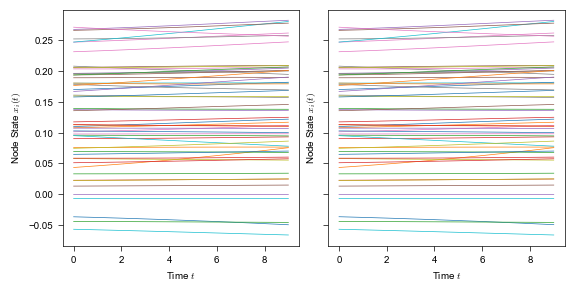

In [60]:
from copy import deepcopy

X0 = deepcopy(X)
X0['x7'] = deepcopy(x_stable.value)
X0['x14'] = deepcopy(x_stable.value)

traj = []
X_cur = deepcopy(X0)
for _ in range(10):
    # y = eq.eval(**X_cur)
    # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
    # X_cur['x7'] = y * X['y_max'] / X['x7_max']
    dx = dxdt.eval(**X_cur)
    X_cur['x7'] = X_cur['x7'] + dx
    X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
    traj.append(X_cur['x7'])
X_baseline = traj[-1]

from ND2.utils import get_fig
fi, fig, axes = get_fig(1, 2, AW=6, AH=6, dpi=100, sharey=True)
axes[0].plot(traj)
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('Node State $x_i(t)$')

from tqdm import tqdm
G = []
p = 1e-4
for j in tqdm(range(N)):
    X00 = deepcopy(X0)
    X00['x7'][j] += p
    X00['x14'][j] += p / 2

    traj = []
    X_cur = X00.copy()
    for _ in range(10):
        # y = eq.eval(**X_cur)
        # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
        # X_cur['x7'] = y * X['y_max'] / X['x7_max']
        dx = dxdt.eval(**X_cur)
        X_cur['x7'] = X_cur['x7'] + dx
        X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
        # X_cur['x7'][j] = X00['x7'][j]
        # X_cur['x14'][j] = X00['x14'][j]
        traj.append(X_cur['x7'])
    dxi = (traj[-1] - X_baseline)
    dxj = p
    G.append(dxi / x_stable.value / dxj * x_stable.value[j])

    if j == 0:
        axes[1].plot(traj)
        axes[1].set_xlabel('Time $t$')
        axes[1].set_ylabel('Node State $x_i(t)$')

G_dict[name] = np.stack(G, axis=1)

[-0.58840697  0.17485221]


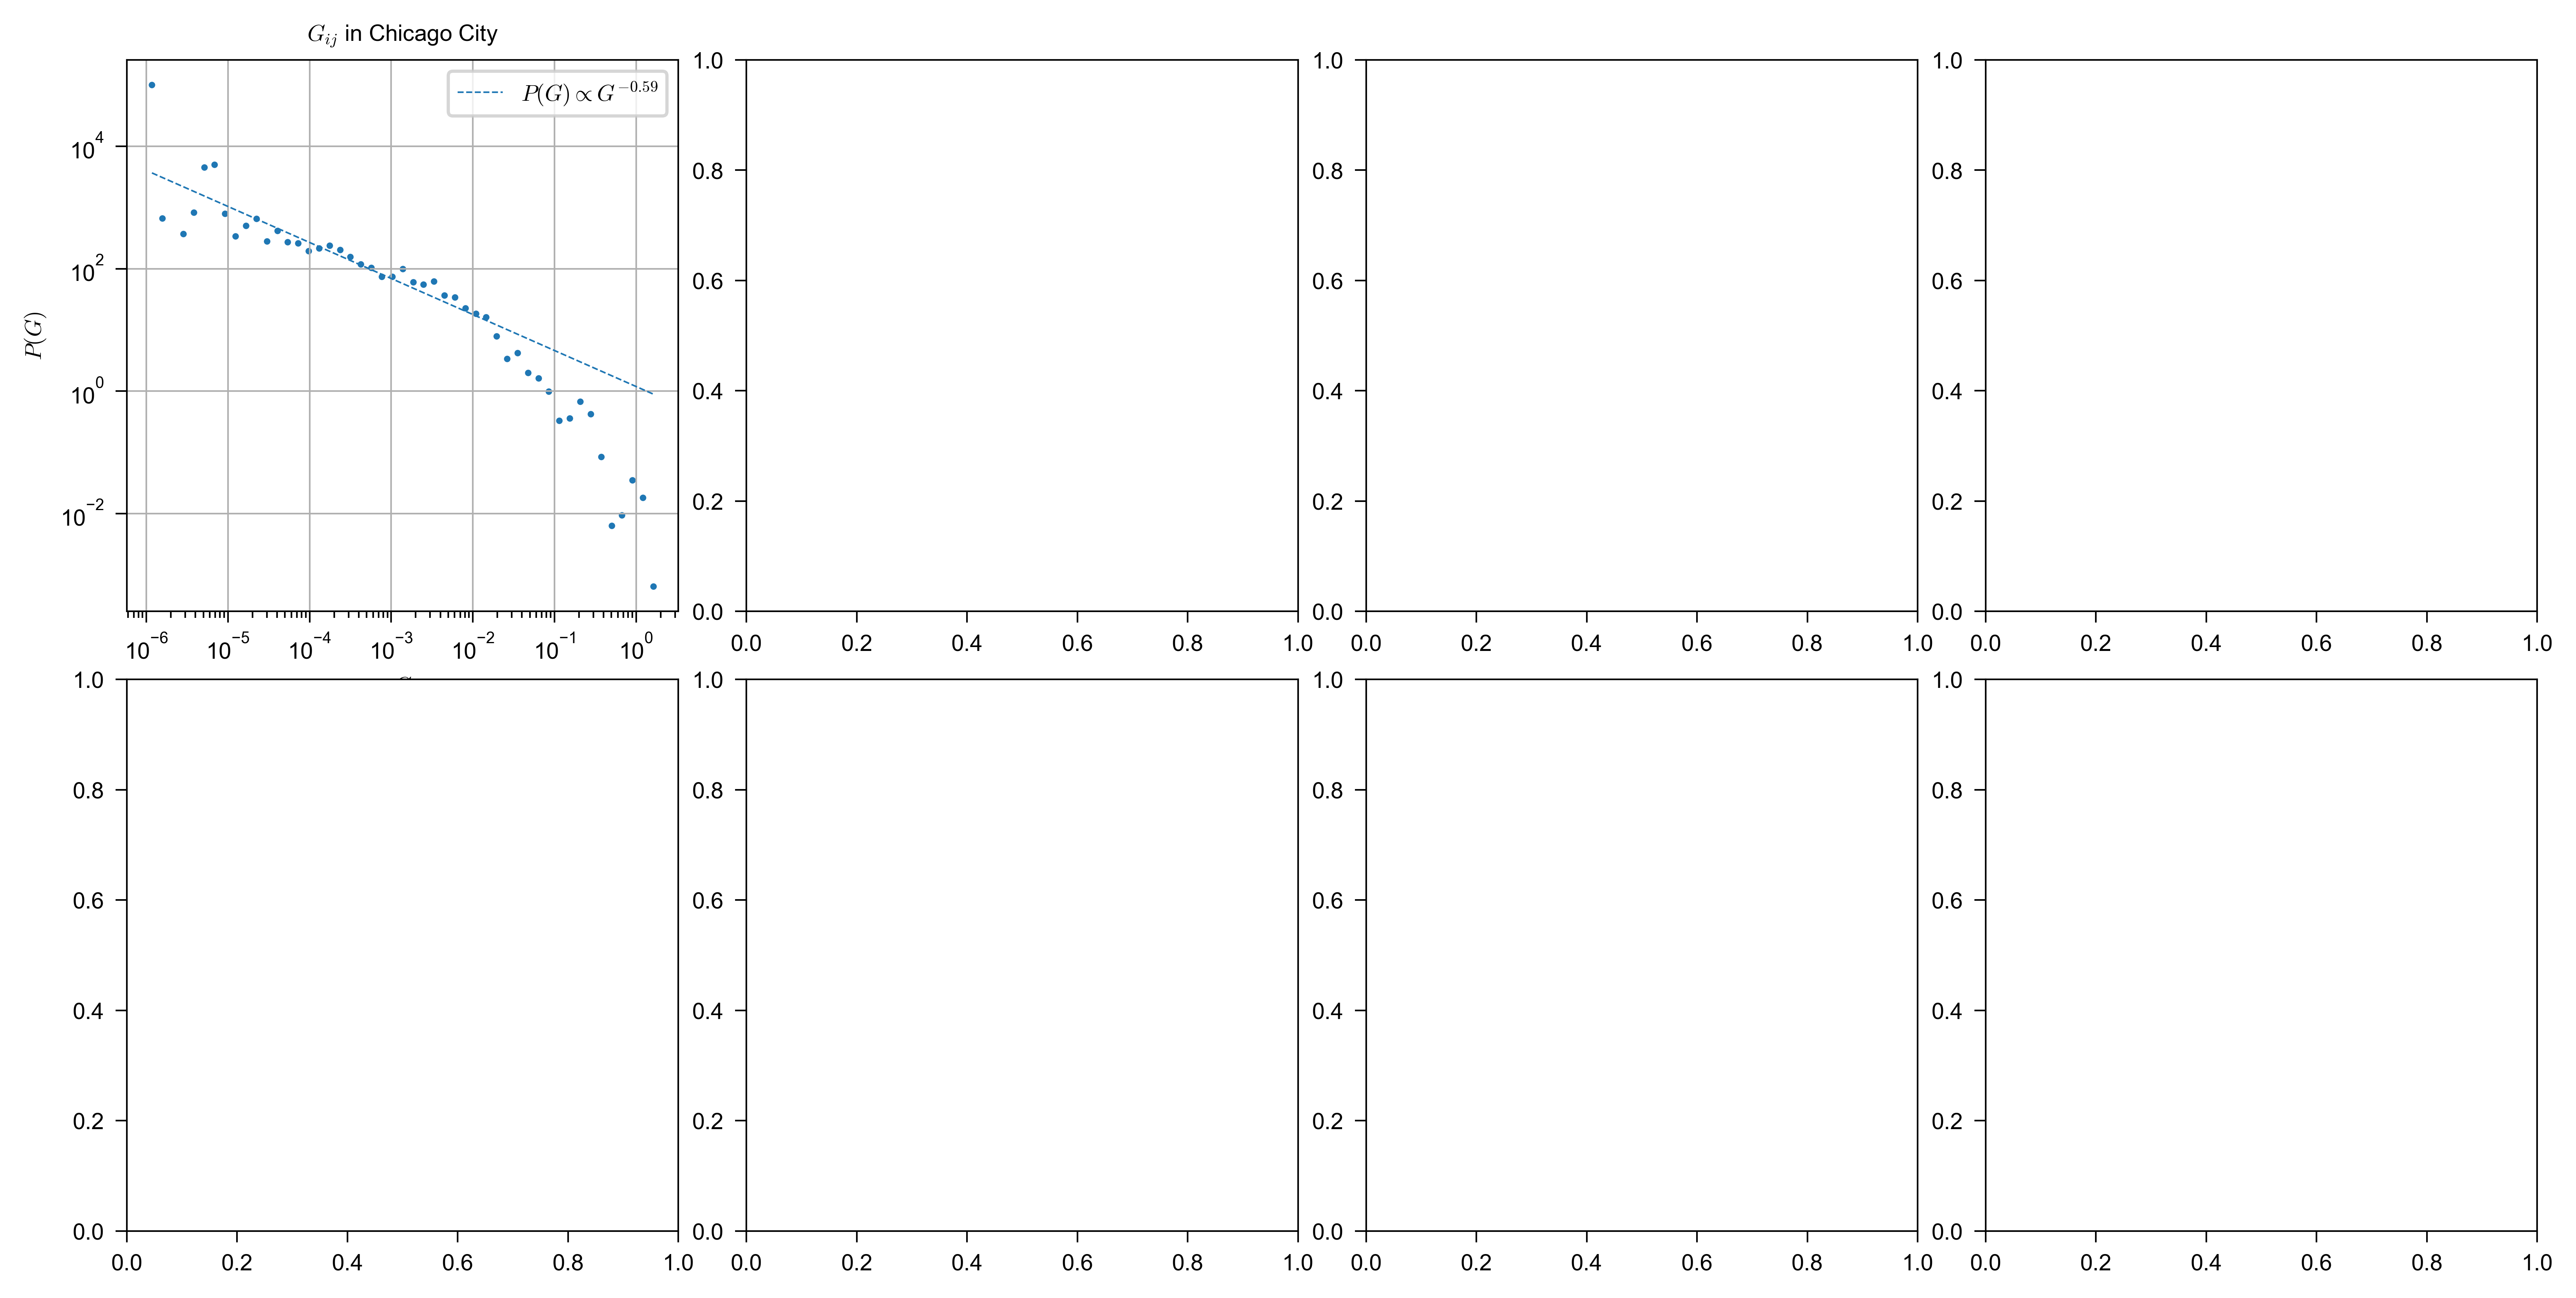

In [61]:
import numpy as np

# 示例数据，假设 x 是一个包含浮点数的 ndarray
# x = np.random.power(0.1, 10000)  # 示例数据，可以替换为你的数据
x = np.abs(G_dict[name]).clip(1e-6, None)
x = x[~np.isnan(x)]
# x = np.random.normal(0, 1, 10000)
# x = np.abs(x) + 1e-6

# 设置直方图的边界
M = 50
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), M)

# 计算直方图
hist, bin_edges = np.histogram(x, bins=bins)
freq = hist / np.diff(bin_edges) / len(x)

# 计算每个 bin 的中心
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# 过滤掉频率为零的 bin
nonzero = freq > 0
bin_centers = bin_centers[nonzero]
freq = freq[nonzero]

# 使用对数坐标绘图
ax = axes_G[0]
ax.clear()
ax.scatter(bin_centers, freq, s=1)

# polyfit
a = np.polyfit(np.log(bin_centers[:34]), np.log(freq[:34]), 1)
print(a)
plot_x = np.logspace(np.log10(np.min(bin_centers)), np.log10(np.max(bin_centers)), 100)
plot_y = np.exp(np.polyval(a, np.log(plot_x)))
ax.plot(plot_x, plot_y, '--', color='C0', label=f'$P(G) \propto G^{{{a[0]:.2f}}}$')


ax.set_title('$G_{ij}$ in Chicago City')
ax.set_xlabel('$G$')
ax.set_ylabel('$P(G)$')
ax.legend()
ax.loglog()
ax.grid()

display(fig_G)

### Resilience 分析

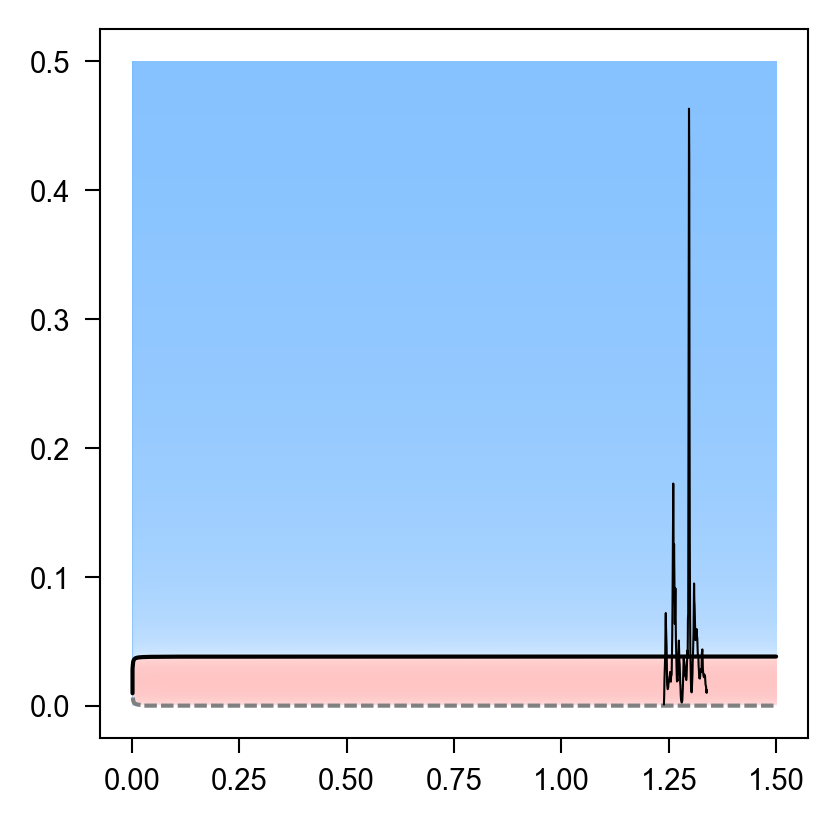

In [29]:
from ND2.utils import get_fig, plot_resilience
import matplotlib.colors as mcolors

def foo(beta_eff, x_eff):
    x7 = x_eff
    x14 = 2 * x_eff * X['x7_max'] / X['x14_max']
    eq = x7 * (-0.69 + 0.91 * beta_eff*((x7))/(eps.value+beta_eff*((x14*(0.23*x7 + 0.50)))))
    eq = eq * X['y_max'] / X['x7_max'] - x7
    return eq

fi, fig, axes = get_fig(1, 1, AW=6, AH=6)
plot_resilience(foo, extent=(0, 1.5, 0, 0.5), ax=axes[0], norm=mcolors.SymLogNorm(linthresh=1e-5, linscale=1, vmin=-1, vmax=1), reset_xylim=True)

s_in = Aggr(f).eval(**X)
s_out = Aggr(f).eval(**X)
beta_eff = (s_out*s_in).sum(axis=-1) / (s_out).sum(axis=-1)
x_eff = (s_out*x7.eval(**X)).sum(axis=-1) / (s_out).sum(axis=-1)
axes[0].plot(beta_eff + 0*x_eff + np.linspace(-0.05, 0.05, len(beta_eff)), x_eff, 'k-', ms=1)

## NYC

In [80]:
name = 'NYC'
X, Y, x7, x14, f, data, evaluate = prepare_data(name)

# 平凡 Baseline
evaluate(x7)
evaluate(x14)
evaluate(Number(0.0), 10000)
evaluate(1.0 * x7, 10000)
evaluate(1.0 * x7 + 0.0 * x14, 10000)
C = Number(np.ones_like(Y[0]), nettype='node')
evaluate(C)
C1 = Number(np.ones_like(Y[0]), nettype='node')  
C2 = Number(np.zeros_like(Y[0]), nettype='node')
evaluate(C1 * x7 + C2 * x14, 10000)

eq = x7 * (0.62 + 1.66 * x7 + -2.0 * x14 + 0.63 * (0.013 + Aggr(Sour(x7))) / (0.018 + x14 * Aggr(Number(1, fitable=False))))
# eq = x7 * (0.42 + 1.6 * x7 - 2.0 * x14 + 0.86 * (0.79 + Aggr(Sour(x7))) / (0.97 + x14 * Aggr(1.0)))
evaluate(eq)

pred = eq.eval(**X)
baseline = x7.eval(**X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".2f"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(Y, pred):.4f} ({r2_score(Y, pred)/r2_score(Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(Y, pred):.4f} ({rmse_score(Y, pred)/rmse_score(Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(Y, pred):.4f} ({mae_score(Y, pred)/mae_score(Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(Y, pred):.2%} ({smape_score(Y, pred)/smape_score(Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(Y, pred):.1%} ({mape_score(Y, pred)/mape_score(Y, baseline)-1:+.1%})')

[NYC] R2=0.6971, RMSE=0.0264, MAE=0.0080, SMAPE=37.77%, MAPE=19120.3% 	 x7
[NYC] R2=0.2307, RMSE=0.0420, MAE=0.0137, SMAPE=49.04%, MAPE=28200.1% 	 x14
[NYC] R2=-0.0000, RMSE=0.0479, MAE=0.0212, SMAPE=90.77%, MAPE=173199.7% 	 0.02
[NYC] R2=0.7156, RMSE=0.0256, MAE=0.0079, SMAPE=39.28%, MAPE=16794.6% 	 0.88 * x7
[NYC] R2=0.7821, RMSE=0.0224, MAE=0.0080, SMAPE=49.80%, MAPE=22703.2% 	 1.79 * x7 + -0.73 * x14
[NYC] R2=0.0046, RMSE=0.0478, MAE=0.0210, SMAPE=90.46%, MAPE=163652.3% 	 <0.02 (+0.00)>


[NYC] R2=0.7183, RMSE=0.0254, MAE=0.0078, SMAPE=40.39%, MAPE=18232.7% 	 <0.98 (+0.01)> * x7 + <-0.03 (+0.01)> * x14
[NYC] R2=0.8740, RMSE=0.0170, MAE=0.0063, SMAPE=36.24%, MAPE=20456.3% 	 x7 * (0.62 + 1.66 * x7 + -2.00 * x14 + 0.63 * (0.01 + Aggr(Sour(x7))) / (0.02 + x14 * Aggr(Constant(1.00))))


<IPython.core.display.Latex object>

Eq: x7 * (0.62 + 1.66 * x7 + -2.00 * x14 + 0.63 * (0.01 + Aggr(Sour(x7))) / (0.02 + x14 * Aggr(Constant(1.00))))
Latex: x_{7}\left(0.6 + 1.7x_{7} + -2.0x_{14} + \frac{0.6\left(0.0 + \rho(\phi_s(x_{7}))\right)}{0.0 + x_{14} \times \rho(Constant(1.0))}\right)
R2: 0.8740 (+25.4%)
RMSE: 0.0170 (-35.5%)
MAE: 0.0063 (-20.5%)
SMAPE: 36.24% (-4.1%)
MAPE: 20456.3% (+7.0%)


### G_ij 分析

In [63]:
dxdt = (eq * Number(X['y_max'] / X['x7_max'], fitable=False) - x7).copy()

N = X['A'].shape[0]
x_stable = Number(np.random.rand(N), 'node')
x_stable = Number(np.array([0.006348252385322151,0.005437569868361937,0.0035414950393916392,-0.03197601449231151,-0.00021308308294922969,0.0404405618941599,-0.0004662033482100783,0.005286534683766989,0.0052269181681331225,0.0013120749259615196,0.007329266722456714,0.0019941331744848904,0.0047021513297149636,0.0015996090433591699,-0.00022059884731056057,0.008530390326494297,0.005405595232914502,0.006200528328419671,0.002231919732040433,0.004676441129219586,0.00495296007433203,0.005873503823690299,0.0061290345088574755,0.005794080832334406,0.005551275245859727,0.00664500083944329,0.006622843709124511,0.007560665738413795,0.0055196439974798655,0.006372892845742247,0.005796803500797373,0.005740617770624624,0.003858690086290747,0.014410296855087438,0.0011699084693772136,0.006969197309248627,0.006335477302575617,0.006438922526776873,0.0023370136337399227,0.005705081136690956,0.005739403280087344,0.0048215659763958035,-0.0022277929418151733,-0.023683395687029398,0.0014826157003197864,0.00974056156502907,0.008039712170394491,-0.0023388664464789374,0.0011632894470222294,0.003130877297134362,-0.0008139837300430064,-0.0011355550784818238,0.003902596516544779,0.006207244108097025,0.0047746003132207405,0.004448003413440134,0.02668334443511003,0.022180868284149658,0.022744625938422552,0.017990557432855207,0.042632970857115704,0.023468205695019385,0.02328187959146893,0.022928371702020216,0.03281975607687852,0.03345145286508081,0.03163470007671334,0.02605557801234481,0.012440883791178258,0.11430343468466486,0.018542656153075064,0.028749471110623946,0.02336027625025068,0.023209248407535386,0.029123153119887422,0.019258014621460037,0.01051289726962108,0.029511846524253496,0.026817632184478205,0.22722529338962238,0.018726358676394418,0.013507029757262843,0.00010006309700590408,0.006153431915625714,0.0030296424781966385,0.00533893800626306,0.006723063409684205,0.00291236414967022,0.0029121600064581318,0.005238933716581234,0.006667622900215356,0.0038791882001857044,0.004983779357025139,0.005705910370239422,0.00841720043720509,0.009044862503773857,0.005720266137304799,0.005885452854891102,0.0031449819467673904,0.005695511547850883,0.006587464020619852,0.005590005066085198,0.0017116636248030051,0.005382600667372058,0.0046266916932983125,0.004568082310537146,0.0020243052502349934,0.004974931849656244,0.006782346803810627,0.00632550811876582,0.003421038419721149,0.0017086957200421256,0.006809937893699143,0.00740747432557553,0.004318958291499569,0.005672801962449772,0.004544511871315479,0.006174905055397495,-1.7109238566196625e-05,0.007583071209636953,0.007100227042643587,0.0029260549507308525,0.008017391747083068,0.0028618068743673183,0.005848556034933742,-0.0024975325491244415,0.011430970047252716,0.007559906933722584,0.014165272879113145,0.0082192398681884,0.010061187951659703,0.01834144545352955,0.013927627710187313,0.017865176700826265,-0.003156492598543295,0.008331930069293699,0.006576721492398594,0.01661363879926437,0.008465821001395665,0.007323234291713642,0.0068611666522082155,0.005129487494451666,0.004312308455478717,0.007956908785348651,0.004617348871962296,0.006081116698863757,0.007963737674486394,0.005678846832962302,0.0066331381603364995,0.008952090580408226,0.008063436237870581,2.3464881654133022e-05,0.006773545132525522,0.010040910754499111,0.010017419644313618,0.00950028820467572,0.006912886443003465,0.0076279953530522405,0.009637450994391212,0.009360808706315558,0.005543012988062566,0.009366760786175547,0.010090164230549176,0.010593391495541303,0.008614111557024153,0.013410435318622599,0.01057451187997574,0.007980012874387814,0.010253429466572156,0.004066439451945625,0.007318151468924094,0.007501467442443272,0.005466685529200022,0.00929240920201826,-0.0011591044896164314,0.01573039445869317,-0.029061368612053724]), 'node')
tmp = dxdt.copy()
for item in tmp.preorder():
    if isinstance(item, Number):
        item.fitable = False
    if isinstance(item, Variable):
        if item.name == 'x7':
            item.replace(x_stable)
        if item.name == 'x14':
            item.replace(x_stable)
print(tmp.to_str(number_format='.2f'))

def loss(params):
    x_stable.value = params
    return np.mean((tmp.eval(**X)) ** 2)
res = minimize(loss, x_stable.value, method='BFGS', options={'maxiter': 10000})
res

<0.01 (+0.02)> * (Constant(0.62) + Constant(1.66) * <0.01 (+0.02)> + Constant(-2.00) * <0.01 (+0.02)> + Constant(0.63) * (Constant(0.01) + Aggr(Sour(<0.01 (+0.02)>))) / (Constant(0.02) + <0.01 (+0.02)> * Aggr(Constant(1.00)))) * Constant(1.00) - <0.01 (+0.02)>


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 4.360740504581846e-07
        x: [ 6.348e-03  5.438e-03 ...  1.573e-02 -2.906e-02]
      nit: 0
      jac: [ 5.547e-07 -1.101e-06 ...  1.693e-06 -2.820e-06]
 hess_inv: [[1 0 ... 0 0]
            [0 1 ... 0 0]
            ...
            [0 0 ... 1 0]
            [0 0 ... 0 1]]
     nfev: 178
     njev: 1

In [66]:
dxdt.eval(**{**X, 'x7': res.x, 'x14': res.x})

array([-1.58405503e-04,  3.42677292e-04,  1.26985289e-05, -2.83994422e-03,
        1.90751030e-04,  2.58817659e-03, -3.19012346e-04,  2.35776237e-04,
        2.75934248e-04,  6.48520056e-04, -2.90686736e-04, -5.49993733e-04,
       -2.10858681e-04,  5.25103948e-04, -3.62309262e-04, -9.81842469e-04,
        1.50980643e-04,  2.41512965e-05,  8.98080804e-04,  3.36402711e-04,
        3.46421416e-04,  1.92831964e-04, -3.64488461e-05, -6.30369834e-05,
        2.63666502e-04,  3.32925069e-04,  2.38533955e-04,  1.19621962e-05,
        9.54150446e-05, -3.91910852e-04,  1.59263785e-04,  1.84022951e-04,
        6.26301977e-04, -1.20137014e-03,  2.96034896e-04,  2.08364601e-05,
       -1.14887004e-04, -3.19127317e-04,  9.95605816e-04,  3.39911691e-04,
        2.35089721e-04,  4.62802840e-04,  1.87140569e-05, -2.03613636e-03,
        1.59796823e-04, -8.08570116e-04, -6.71643761e-04,  2.74319460e-03,
        2.82966864e-04,  5.48395759e-04, -3.64417812e-04, -3.60839626e-04,
        1.70527582e-04, -

In [67]:
print(','.join(map(str, x_stable.value.tolist())))

0.006348252385322151,0.005437569868361937,0.0035414950393916392,-0.03197601449231151,-0.00021308308294922969,0.0404405618941599,-0.0004662033482100783,0.005286534683766989,0.0052269181681331225,0.0013120749259615196,0.007329266722456714,0.0019941331744848904,0.0047021513297149636,0.0015996090433591699,-0.00022059884731056057,0.008530390326494297,0.005405595232914502,0.006200528328419671,0.002231919732040433,0.004676441129219586,0.00495296007433203,0.005873503823690299,0.0061290345088574755,0.005794080832334406,0.005551275245859727,0.00664500083944329,0.006622843709124511,0.007560665738413795,0.0055196439974798655,0.006372892845742247,0.005796803500797373,0.005740617770624624,0.003858690086290747,0.014410296855087438,0.0011699084693772136,0.006969197309248627,0.006335477302575617,0.006438922526776873,0.0023370136337399227,0.005705081136690956,0.005739403280087344,0.0048215659763958035,-0.0022277929418151733,-0.023683395687029398,0.0014826157003197864,0.00974056156502907,0.00803971217039

100%|██████████| 177/177 [00:28<00:00,  6.19it/s]


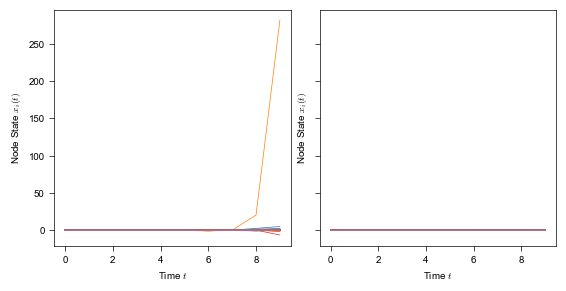

In [64]:
from copy import deepcopy

X0 = deepcopy(X)
X0['x7'] = deepcopy(x_stable.value)
X0['x14'] = deepcopy(x_stable.value)

traj = []
X_cur = deepcopy(X0)
for _ in range(10):
    # y = eq.eval(**X_cur)
    # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
    # X_cur['x7'] = y * X['y_max'] / X['x7_max']
    dx = dxdt.eval(**X_cur)
    X_cur['x7'] = X_cur['x7'] + dx
    X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
    traj.append(X_cur['x7'])
X_baseline = traj[-1]

from ND2.utils import get_fig
fi, fig, axes = get_fig(1, 2, AW=6, AH=6, dpi=100, sharey=True)
axes[0].plot(traj)
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('Node State $x_i(t)$')

from tqdm import tqdm
G = []
p = 1e-4
for j in tqdm(range(N)):
    X00 = deepcopy(X0)
    X00['x7'][j] += p
    X00['x14'][j] += p / 2

    traj = []
    X_cur = X00.copy()
    for _ in range(10):
        # y = eq.eval(**X_cur)
        # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
        # X_cur['x7'] = y * X['y_max'] / X['x7_max']
        dx = dxdt.eval(**X_cur)
        X_cur['x7'] = X_cur['x7'] + dx
        X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
        # X_cur['x7'][j] = X00['x7'][j]
        # X_cur['x14'][j] = X00['x14'][j]
        traj.append(X_cur['x7'])
    dxi = (traj[-1] - X_baseline)
    dxj = p
    G.append(dxi / x_stable.value / dxj * x_stable.value[j])

    if j == 0:
        axes[1].plot(traj)
        axes[1].set_xlabel('Time $t$')
        axes[1].set_ylabel('Node State $x_i(t)$')

G_dict[name] = np.stack(G, axis=1)

[-1.17721257 -4.26332562]


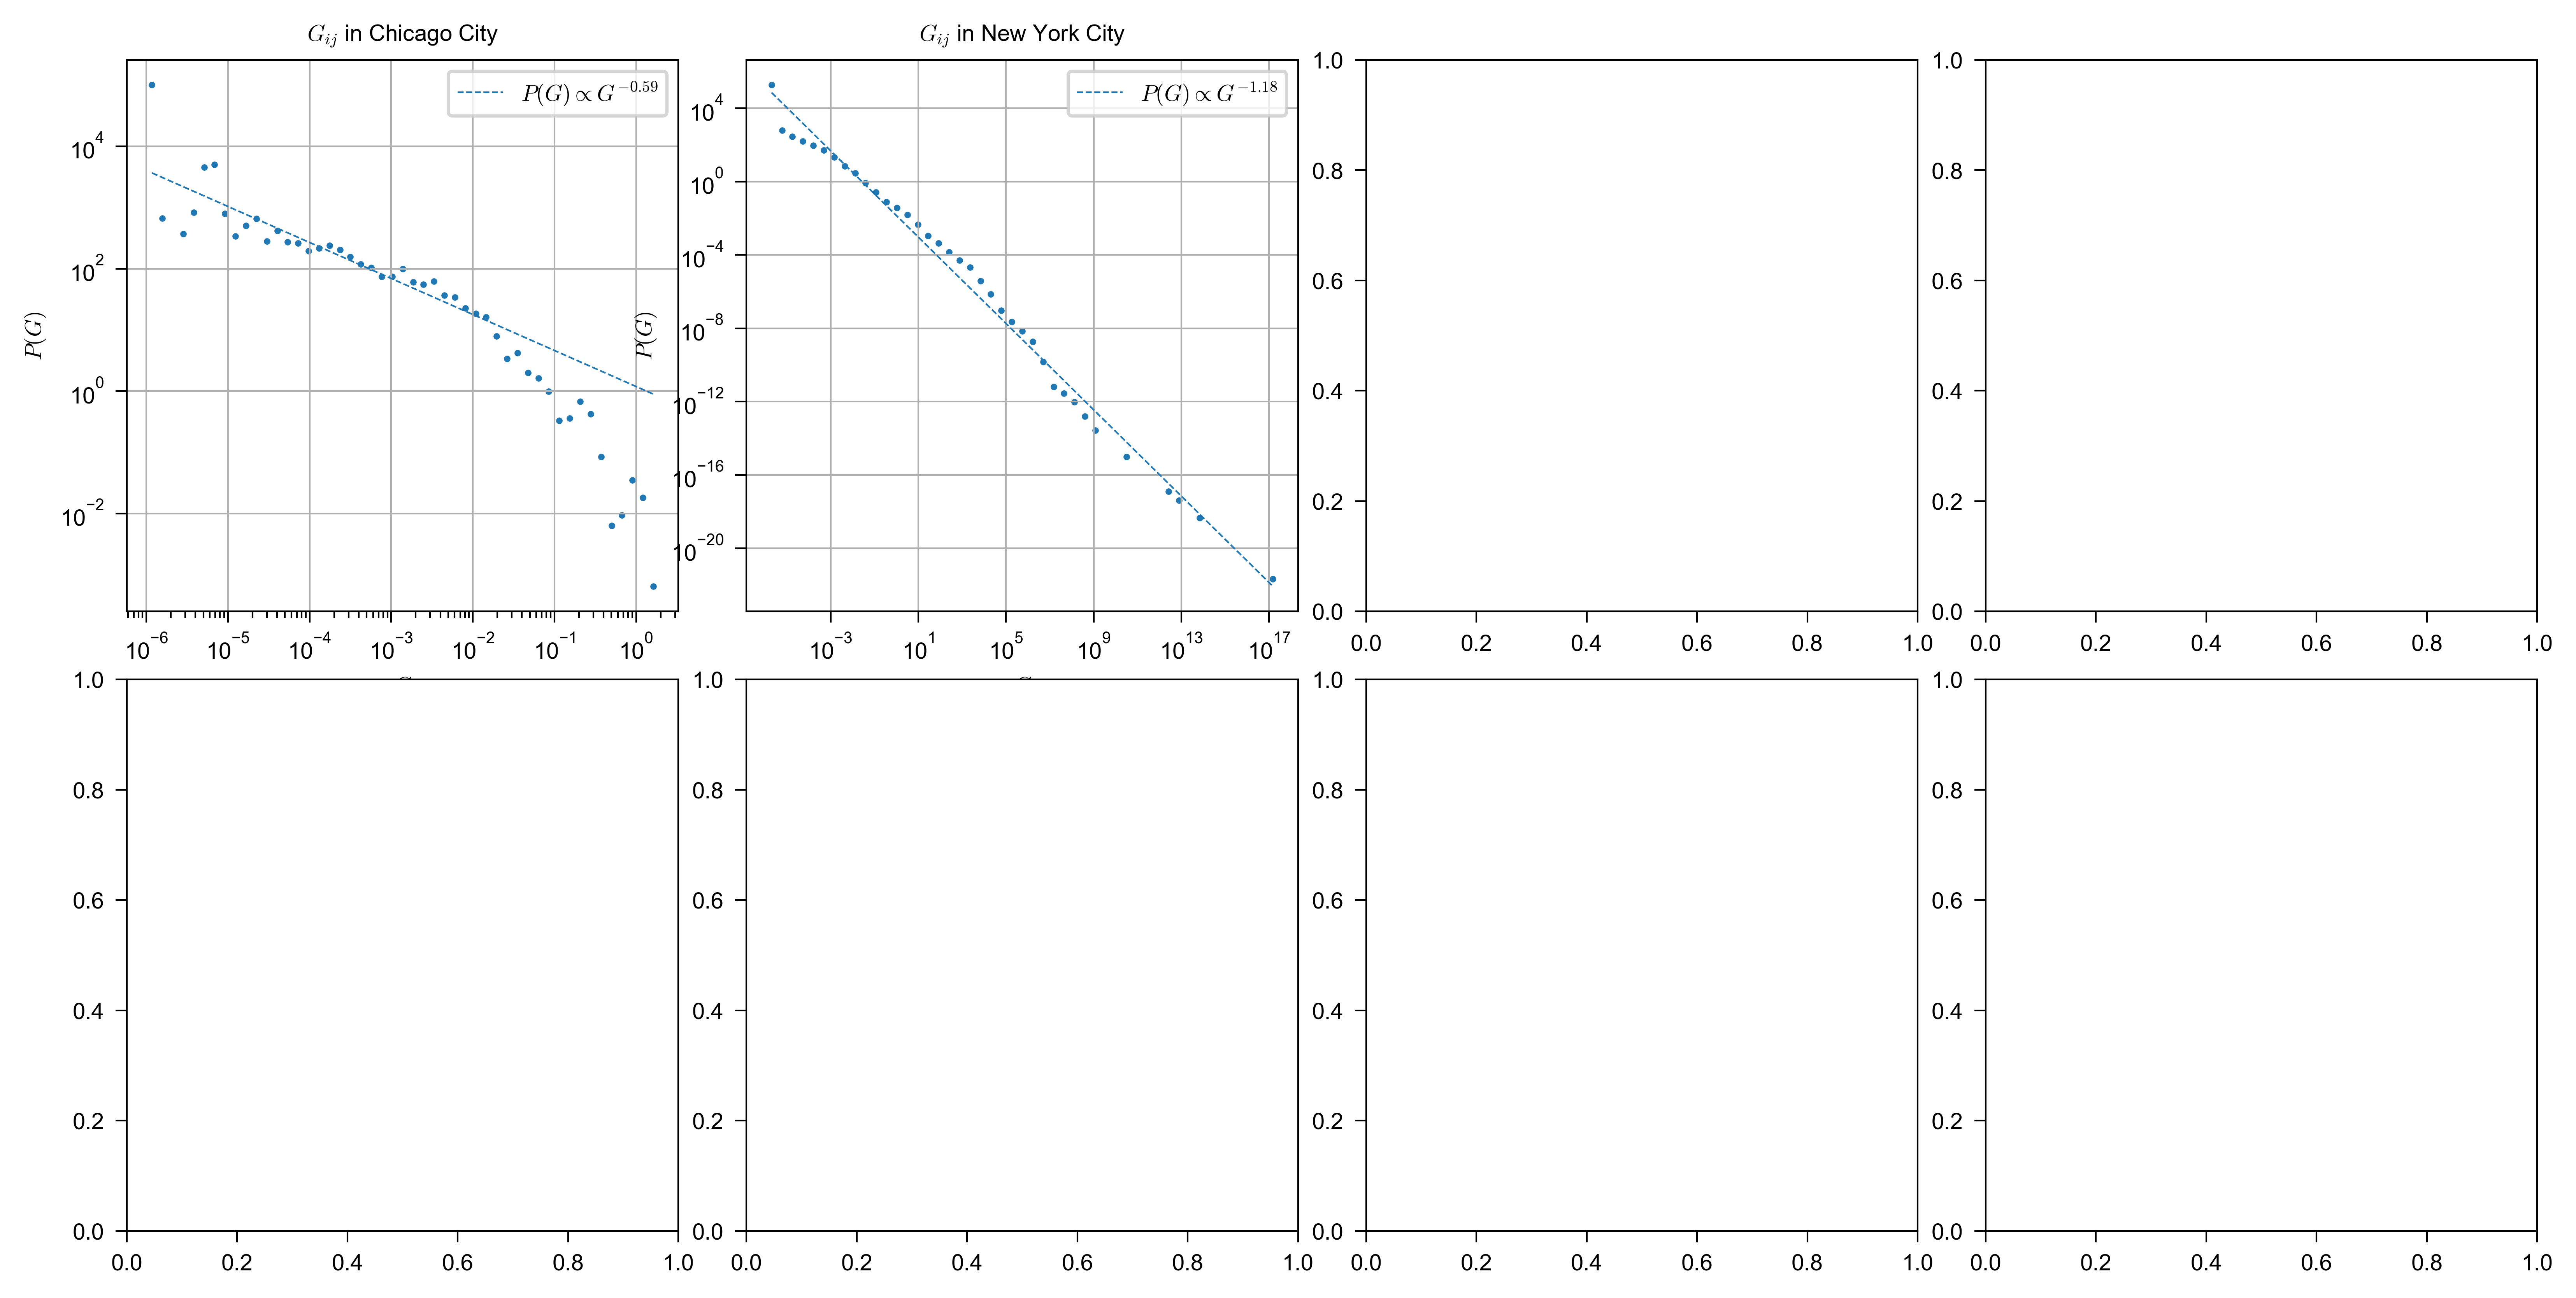

In [65]:
import numpy as np

# 示例数据，假设 x 是一个包含浮点数的 ndarray
# x = np.random.power(0.1, 10000)  # 示例数据，可以替换为你的数据
x = np.abs(G_dict[name]).clip(1e-6, None)
x = x[~np.isnan(x)]
# x = np.random.normal(0, 1, 10000)
# x = np.abs(x) + 1e-6

# 设置直方图的边界
M = 50
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), M)

# 计算直方图
hist, bin_edges = np.histogram(x, bins=bins)
freq = hist / np.diff(bin_edges) / len(x)

# 计算每个 bin 的中心
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# 过滤掉频率为零的 bin
nonzero = freq > 0
bin_centers = bin_centers[nonzero]
freq = freq[nonzero]

# 使用对数坐标绘图
ax = axes_G[1]
ax.clear()
ax.scatter(bin_centers, freq, s=1)

# polyfit
a = np.polyfit(np.log(bin_centers[:37]), np.log(freq[:37]), 1)
print(a)
plot_x = np.logspace(np.log10(np.min(bin_centers)), np.log10(np.max(bin_centers)), 100)
plot_y = np.exp(np.polyval(a, np.log(plot_x)))
ax.plot(plot_x, plot_y, '--', color='C0', label=f'$P(G) \propto G^{{{a[0]:.2f}}}$')


ax.set_title('$G_{ij}$ in New York City')
ax.set_xlabel('$G$')
ax.set_ylabel('$P(G)$')
ax.legend()
ax.loglog()
ax.grid()

display(fig_G)

### Resilisence 分析

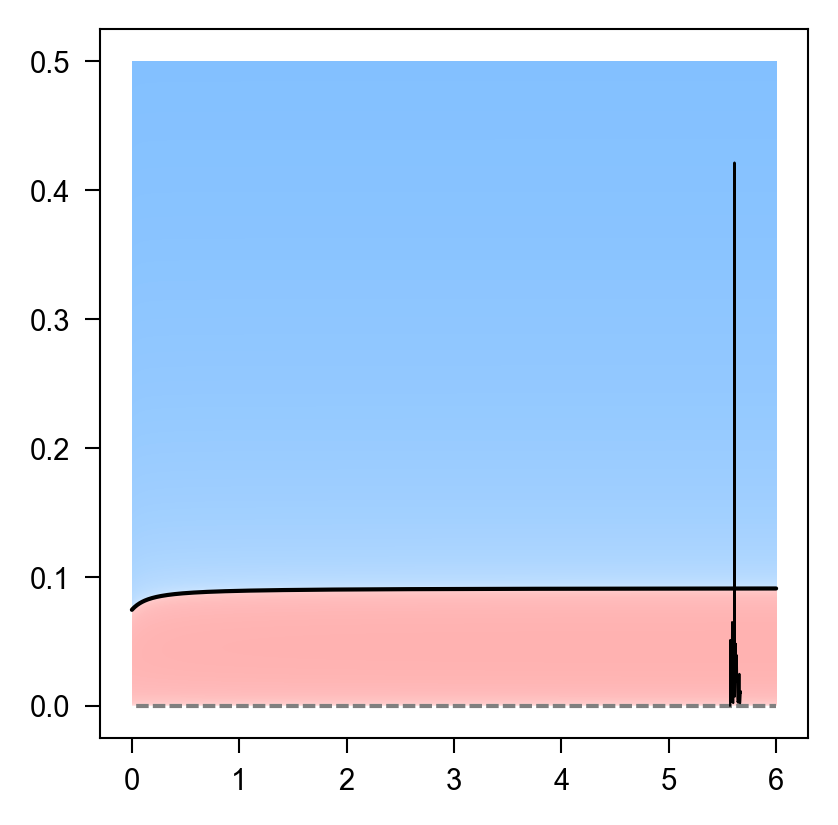

In [31]:
from ND2.utils import get_fig, plot_resilience
import matplotlib.colors as mcolors

def foo(beta_eff, x_eff):
    x7 = x_eff
    x14 = 2 * x_eff * X['x7_max'] / X['x14_max']
    sigmoid = lambda x: 1 / (1 + np.exp(-x))
    eq = x7 * (0.62 + 1.66 * x7 + -2.0 * x14 + 0.63 * (0.013 + beta_eff*((x7))) / (0.018 + x14 * beta_eff*((1))))
    eq = eq * X['y_max'] / X['x7_max'] - x7
    return eq

fi, fig, axes = get_fig(1, 1, AW=6, AH=6)
plot_resilience(foo, extent=(0, 6.0, 0, 0.5), ax=axes[0], norm=mcolors.SymLogNorm(linthresh=1e-5, linscale=1, vmin=-1, vmax=1), reset_xylim=True)

s_in = Aggr(f).eval(**X)
s_out = Aggr(f).eval(**X)
beta_eff = (s_out*s_in).sum(axis=-1) / (s_out).sum(axis=-1)
x_eff = (s_out*x7.eval(**X)).sum(axis=-1) / (s_out).sum(axis=-1)
axes[0].plot(beta_eff + 0*x_eff + np.linspace(-0.05, 0.05, len(beta_eff)), x_eff, 'k-', ms=1)

# ILS

In [82]:
name = 'ILS'
X, Y, x7, x14, f, data, evaluate = prepare_data(name)

# 平凡 Baseline
evaluate(x7)
evaluate(x14)
evaluate(Number(0.0), 10000)
evaluate(1.0 * x7, 10000)
evaluate(1.0 * x7 + 0.0 * x14, 10000)
C = Number(np.ones_like(Y[0]), nettype='node')
evaluate(C)
C1 = Number(np.ones_like(Y[0]), nettype='node')  
C2 = Number(np.zeros_like(Y[0]), nettype='node')
evaluate(C1 * x7 + C2 * x14, 10000)

eq = 1.00 * x7 + -0.67 * x14 + 0.84 * x7 * Sigmoid(1.00 / Pow2(Aggr(Sour(x14))))
evaluate(eq)

pred = eq.eval(**X)
baseline = x7.eval(**X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".2f"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(Y, pred):.4f} ({r2_score(Y, pred)/r2_score(Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(Y, pred):.4f} ({rmse_score(Y, pred)/rmse_score(Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(Y, pred):.4f} ({mae_score(Y, pred)/mae_score(Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(Y, pred):.2%} ({smape_score(Y, pred)/smape_score(Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(Y, pred):.1%} ({mape_score(Y, pred)/mape_score(Y, baseline)-1:+.1%})')

[ILS] R2=0.8723, RMSE=0.0059, MAE=0.0007, SMAPE=48.05%, MAPE=781.4% 	 x7
[ILS] R2=0.7419, RMSE=0.0084, MAE=0.0010, SMAPE=51.83%, MAPE=1108.9% 	 x14
[ILS] R2=-0.0000, RMSE=0.0165, MAE=0.0036, SMAPE=137.94%, MAPE=24032.0% 	 0.00
[ILS] R2=0.8763, RMSE=0.0058, MAE=0.0007, SMAPE=48.37%, MAPE=733.4% 	 0.94 * x7
[ILS] R2=0.8785, RMSE=0.0058, MAE=0.0007, SMAPE=49.15%, MAPE=712.9% 	 0.97 * x7 + -0.04 * x14
[ILS] R2=0.3674, RMSE=0.0131, MAE=0.0019, SMAPE=91.44%, MAPE=10884.5% 	 <0.00 (+0.01)>
[ILS] R2=0.8778, RMSE=0.0058, MAE=0.0007, SMAPE=48.06%, MAPE=758.0% 	 <1.00 (+0.00)> * x7 + <-0.00 (+0.00)> * x14
[ILS] R2=0.9234, RMSE=0.0046, MAE=0.0007, SMAPE=54.60%, MAPE=717.1% 	 1.00 * x7 + -0.67 * x14 + 0.84 * x7 * sigmoid(1.00 / Aggr(Sour(x14)) ** 2)


<IPython.core.display.Latex object>

Eq: 1.00 * x7 + -0.67 * x14 + 0.84 * x7 * sigmoid(1.00 / Aggr(Sour(x14)) ** 2)
Latex: 1.0x_{7} + -0.7x_{14} + 0.8x_{7} \times sigmoid(\frac{1.0}{\rho(\phi_s(x_{14}))^2})
R2: 0.9234 (+5.8%)
RMSE: 0.0046 (-22.5%)
MAE: 0.0007 (-6.1%)
SMAPE: 54.60% (+13.6%)
MAPE: 717.1% (-8.2%)


### G_ij 分析

In [67]:
dxdt = (eq * Number(X['y_max'] / X['x7_max'], fitable=False) - x7).copy()

N = X['A'].shape[0]
x_stable = Number(np.random.rand(N), 'node')
x_stable = Number(np.array([-0.01543458609114612,-0.009488417225541926,0.018141580609410235,0.0007071550939414905,-0.0034038684916830753,-0.028189709542173147,0.05482967538297958,-0.0008569171508065132,0.000641391327191637,0.000478397912670632,0.027255006229744114,0.000502147472397106,-0.0010067239011029604,0.00700744514441605,0.001694676045672487,-0.31169111590057486,0.013076345590635047,0.005950646486656885,0.017398281864709743,-0.007970420102091645,0.011741273544004322,-0.04546649535374294,0.004829036189376589,0.0010939114072644651,0.011745738619444864,0.02204221897785322,0.006530117786128629,0.015606785414744534,-0.0017603027656413839,0.018197913999535357,0.005318990044651856,-0.007961080609280325,0.0003217074065256032,-0.002005062768426509,0.25363237193480853,0.0013512375792961437,-0.024305600648718607,0.002759921691983555,0.01665822810511765,0.0012963768378540896,0.022492725320408205,-0.023196996269187732,0.007264313408319939,0.0031468027759690865,0.007517417208353389,-0.0024069761233575853,-0.0015443715751539877,0.00909771327707484,-0.0008715684958471434,0.025441169527669154,0.0026648837654172164,-0.002339948527535179,-0.006051622799250065,0.00023220531476465583,-0.004955842433540692,-0.0007704271177482363,-0.13602845225025825,0.008393834054701805,0.004998992008484442,0.0008256327031572193,-0.0013049117860720215,-0.00015499407449447817,0.011345107654309471,-0.009796004078203129,0.0020253947749620193,-0.0030916188051578314,0.031276123561642374,0.008062169326416029,-0.009622043091924803,-0.0008828424473373794,-0.004530809966878925,-0.031010817824318037,0.009142174679953532,0.00624083540809605,-0.028545504043890613,0.014053230459739762,0.04310555809290141,-0.00249039971778911,0.010604219799487337,0.011582126628611128,-0.017860537456607886,-0.33909217098477396,-0.23017111227237694,0.0024436956826971515,0.0014413778432786372,-0.005913726177882489,-0.009552497615741142,-0.005533059175252566,0.009437171418746435,-0.021820839100783217,0.0030354515106769384,0.012170194086104678,-0.005470278617953554,-0.007450709589159719,0.03696829068546222,-0.0025767638867630095,-0.004281385687225823,-0.006190701334501275,0.006710519948164639,-0.4977464545382937,0.0049905498030019925,0.00479326698196304]), 'node')
tmp = dxdt.copy()
for item in tmp.preorder():
    if isinstance(item, Number):
        item.fitable = False
    if isinstance(item, Variable):
        if item.name == 'x7':
            item.replace(x_stable)
        if item.name == 'x14':
            item.replace(x_stable)
print(tmp.to_str(number_format='.2f'))

def loss(params):
    x_stable.value = params
    return np.mean((tmp.eval(**X)) ** 2)
res = minimize(loss, x_stable.value, method='BFGS', options={'maxiter': 10000})
res

(Constant(1.00) * <-0.01 (+0.08)> + Constant(-0.67) * <-0.01 (+0.08)> + Constant(0.84) * <-0.01 (+0.08)> * sigmoid(Constant(1.00) / Aggr(Sour(<-0.01 (+0.08)>)) ** 2)) * Constant(1.00) - <-0.01 (+0.08)>


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.1363675037722562e-06
        x: [-1.543e-02 -9.488e-03 ...  4.991e-03  4.793e-03]
      nit: 0
      jac: [-5.329e-06 -1.961e-08 ... -5.055e-06 -4.033e-06]
 hess_inv: [[1 0 ... 0 0]
            [0 1 ... 0 0]
            ...
            [0 0 ... 1 0]
            [0 0 ... 0 1]]
     nfev: 103
     njev: 1

In [60]:
dxdt.eval(**{**X, 'x7': res.x, 'x14': res.x})

array([-4.47816084e-04,  4.56055430e-04,  1.51913753e-03,  8.54091770e-05,
       -4.22266880e-04, -6.48183085e-04,  3.21521423e-03, -1.45359710e-04,
        2.79435882e-05,  3.64639829e-05,  1.77165622e-03,  4.23007983e-05,
       -1.05483590e-04, -5.78077210e-04, -2.71594672e-04, -4.36442616e-06,
       -1.30321083e-03,  8.98566479e-04,  8.11472862e-04, -7.01886520e-04,
        7.08958305e-04, -2.34778210e-03,  2.94703315e-04,  1.85932259e-04,
        1.02516666e-03,  1.90664233e-03,  7.45079085e-04, -2.34705333e-03,
       -1.65459031e-04,  2.87220606e-04,  1.89566201e-04, -9.93851632e-04,
       -4.32626063e-05, -1.60719511e-04,  1.90989352e-03,  1.56753118e-04,
       -6.86597005e-04,  3.25505754e-04, -2.53129451e-03,  2.18392522e-04,
       -3.24759374e-03, -1.54918147e-03,  6.82020814e-04, -3.88986411e-04,
        1.71773034e-04, -1.10890372e-04, -5.07299825e-05, -9.04543603e-06,
       -2.01804688e-05,  1.94009132e-04,  2.55300489e-04, -2.43599504e-04,
       -3.71550190e-04,  

In [61]:
print(','.join(map(str, x_stable.value.tolist())))

-0.01543458609114612,-0.009488417225541926,0.018141580609410235,0.0007071550939414905,-0.0034038684916830753,-0.028189709542173147,0.05482967538297958,-0.0008569171508065132,0.000641391327191637,0.000478397912670632,0.027255006229744114,0.000502147472397106,-0.0010067239011029604,0.00700744514441605,0.001694676045672487,-0.31169111590057486,0.013076345590635047,0.005950646486656885,0.017398281864709743,-0.007970420102091645,0.011741273544004322,-0.04546649535374294,0.004829036189376589,0.0010939114072644651,0.011745738619444864,0.02204221897785322,0.006530117786128629,0.015606785414744534,-0.0017603027656413839,0.018197913999535357,0.005318990044651856,-0.007961080609280325,0.0003217074065256032,-0.002005062768426509,0.25363237193480853,0.0013512375792961437,-0.024305600648718607,0.002759921691983555,0.01665822810511765,0.0012963768378540896,0.022492725320408205,-0.023196996269187732,0.007264313408319939,0.0031468027759690865,0.007517417208353389,-0.0024069761233575853,-0.0015443715751

100%|██████████| 102/102 [00:04<00:00, 22.49it/s]


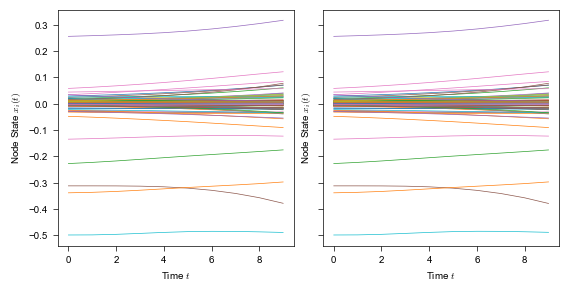

In [68]:
from copy import deepcopy

X0 = deepcopy(X)
X0['x7'] = deepcopy(x_stable.value)
X0['x14'] = deepcopy(x_stable.value)

traj = []
X_cur = deepcopy(X0)
for _ in range(10):
    # y = eq.eval(**X_cur)
    # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
    # X_cur['x7'] = y * X['y_max'] / X['x7_max']
    dx = dxdt.eval(**X_cur)
    X_cur['x7'] = X_cur['x7'] + dx
    X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
    traj.append(X_cur['x7'])
X_baseline = traj[-1]

from ND2.utils import get_fig
fi, fig, axes = get_fig(1, 2, AW=6, AH=6, dpi=100, sharey=True)
axes[0].plot(traj)
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('Node State $x_i(t)$')

from tqdm import tqdm
G = []
p = 1e-4
for j in tqdm(range(N)):
    X00 = deepcopy(X0)
    X00['x7'][j] += p
    X00['x14'][j] += p / 2

    traj = []
    X_cur = X00.copy()
    for _ in range(10):
        # y = eq.eval(**X_cur)
        # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
        # X_cur['x7'] = y * X['y_max'] / X['x7_max']
        dx = dxdt.eval(**X_cur)
        X_cur['x7'] = X_cur['x7'] + dx
        X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
        # X_cur['x7'][j] = X00['x7'][j]
        # X_cur['x14'][j] = X00['x14'][j]
        traj.append(X_cur['x7'])
    dxi = (traj[-1] - X_baseline)
    dxj = p
    G.append(dxi / x_stable.value / dxj * x_stable.value[j])

    if j == 3:
        axes[1].plot(traj)
        axes[1].set_xlabel('Time $t$')
        axes[1].set_ylabel('Node State $x_i(t)$')

G_dict[name] = np.stack(G, axis=1)

[-0.78250996 -1.56185387]


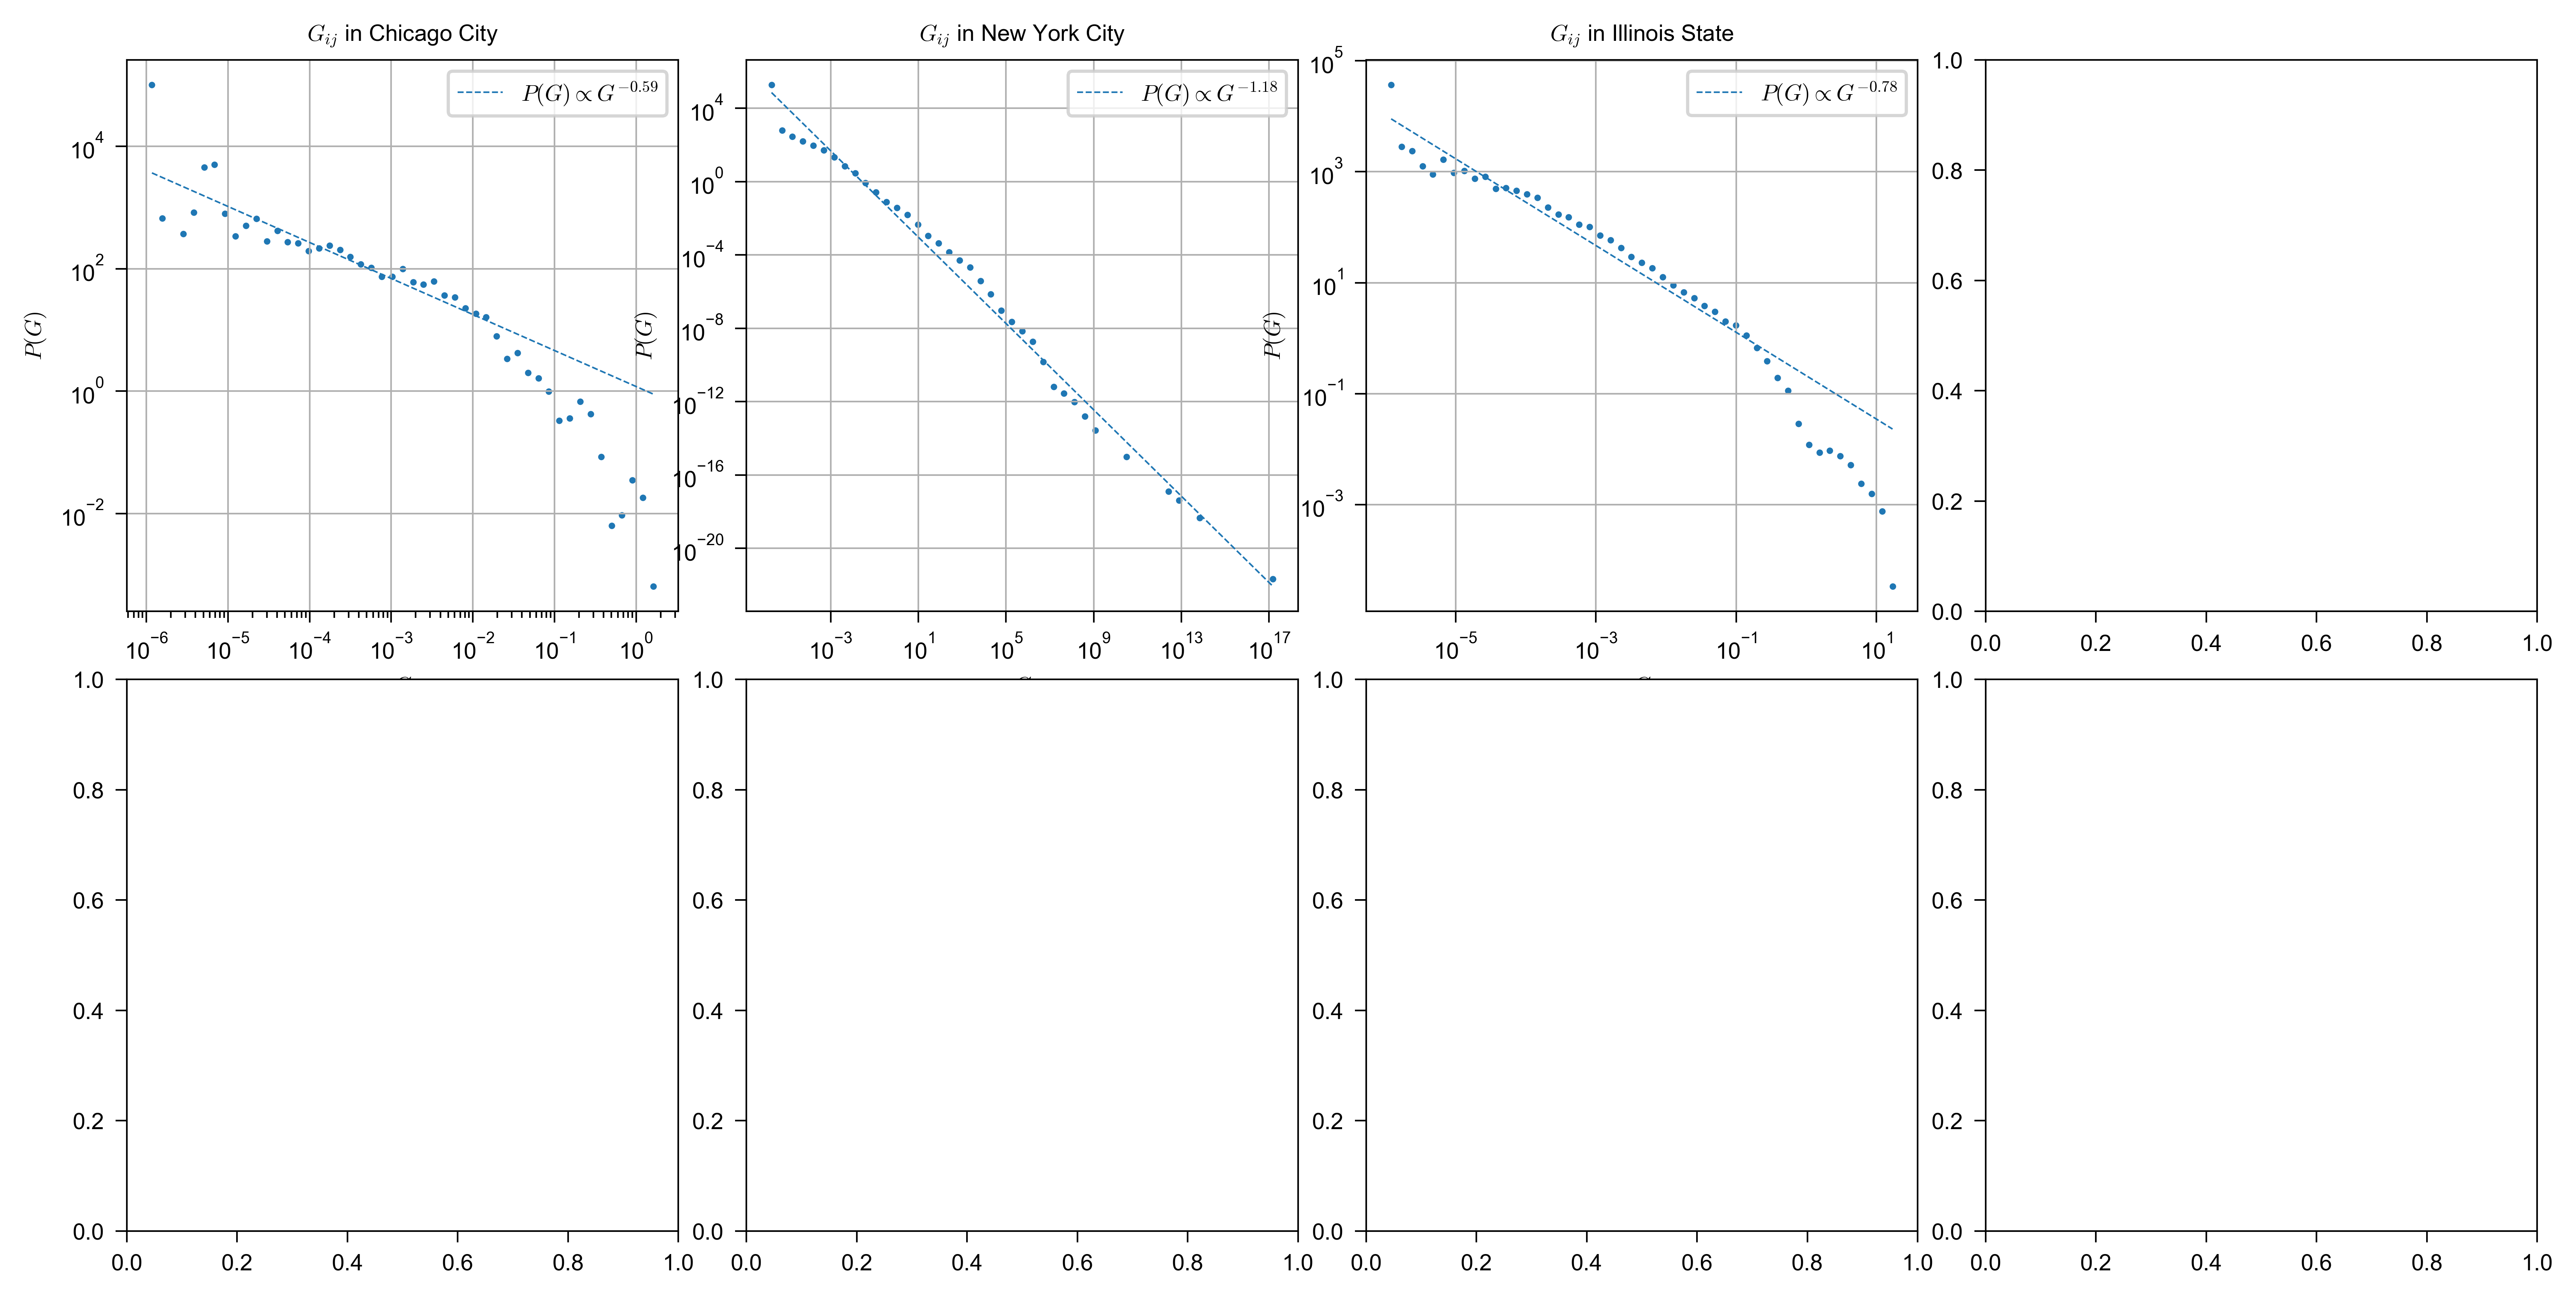

In [69]:
import numpy as np

# 示例数据，假设 x 是一个包含浮点数的 ndarray
# x = np.random.power(0.1, 10000)  # 示例数据，可以替换为你的数据
x = np.abs(G_dict[name]).clip(1e-6, None)
x = x[~np.isnan(x)]
# x = np.random.normal(0, 1, 10000)
# x = np.abs(x) + 1e-6

# 设置直方图的边界
M = 50
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), M)

# 计算直方图
hist, bin_edges = np.histogram(x, bins=bins)
freq = hist / np.diff(bin_edges) / len(x)

# 计算每个 bin 的中心
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# 过滤掉频率为零的 bin
nonzero = freq > 0
bin_centers = bin_centers[nonzero]
freq = freq[nonzero]

# 使用对数坐标绘图
ax = axes_G[2]
ax.clear()
ax.scatter(bin_centers, freq, s=1)

# polyfit
a = np.polyfit(np.log(bin_centers[:40]), np.log(freq[:40]), 1)
print(a)
plot_x = np.logspace(np.log10(np.min(bin_centers)), np.log10(np.max(bin_centers)), 100)
plot_y = np.exp(np.polyval(a, np.log(plot_x)))
ax.plot(plot_x, plot_y, '--', color='C0', label=f'$P(G) \propto G^{{{a[0]:.2f}}}$')


ax.set_title('$G_{ij}$ in Illinois State')
ax.set_xlabel('$G$')
ax.set_ylabel('$P(G)$')
ax.legend()
ax.loglog()
ax.grid()

display(fig_G)

### Resilience 分析

In [9]:
# eps = Number(1e-7, fitable=False)

# evaluate(0.26 * x7 - 0.41 * x14 + 1.3 * x7 * Sigmoid(Aggr(Sour(Aggr(f) - 0.053 * x14 * Aggr(Number(1, fitable=False))))))
# evaluate(1.0*x7+0.0*x14+0.0*x7                                                                                                     	)
# evaluate(1.0*x7+0.0*x14+0.0*Tanh(x7)                                                                                               	)
# evaluate(1.0*x7+0.0*x14+0.0*((x7**2)/(x14+eps))                                                                                          	)
# evaluate(1.0*x7+0.0*x14+0.0*Tanh(((x7**2)/(x14+eps)))                                                                                    	)
# evaluate(1.0*x7+0.0*x14+0.0*Tanh((x14*((x7/(x14+eps))**2)))                                                                              	)
# evaluate(1.0*x7+0.0*x14+0.0*(x7-((1.0+x14)*(x7**2)))                                                                               	)
# evaluate(1.0*x7+0.0*x14+0.0*(Sigmoid(x7)*(x7*(2-(x14*x14))))                                                                       	)
# evaluate(1.0*x7+0.0*x14+0.0*(Sigmoid(x7)*(x7*(1.0-((x14**3)+(1/5)))))                                                              	)
# evaluate(1.0*x7+0.0*x14+0.0*(-(((x14+1.0)*x7)*Sigmoid((x7*Aggr(f)))))                                                              	)
# evaluate(1.0*x7+0.0*x14+0.0*((x7**2)*((Sigmoid(x7)/(x14+eps))*(1.0-(x7-3))))                                                             	)
# evaluate(1.0*x7+0.0*x14+0.0*((Sigmoid(x14)**2)*(x7*(1.0-(Aggr(Sour(x7))*Aggr(f)))))                                                	)
# evaluate(1.0*x7+0.0*x14+0.0*((Sigmoid(x14)**2)*(x7*(1.0-Aggr((Sour(x7)*Targ(Aggr(f)))))))                                          	)
# evaluate(1.0*x7+0.0*x14+0.0*(Sigmoid(x14)*(x7*Aggr((1.0-Sour(((1.0/(eps+Aggr(f)**3))**x7))))))                                         	)
# evaluate(1.0*x7+0.0*x14+0.0*(Sigmoid(x14)*(x7*Aggr((1.0-Sour((((1.0*Aggr(f))**1.0)**x7))))))                                       	)
# evaluate(1.0*x7+0.0*x14+0.0*(Sigmoid(x14)*(x7*Aggr((1.0-Sour((Aggr(f)**((Aggr(f)*1.0)*(x7**2))))))))                               	)
# evaluate(1.0*x7+0.0*x14+0.0*(Sigmoid(x14)*(x7*Aggr((1.0-Sour((Aggr(f)**((x7*x7)*(Aggr(f)*1.0))))))))                               	)
# evaluate(1.0*x7+0.0*x14+0.0*(Sigmoid(x14)*(x7*Aggr((1.0-Sour((Aggr(f)**((x7*x7)*(1.0*(Aggr(f)-x7)))))))))                          	)
# evaluate(1.0*x7+0.0*x14+0.0*(Aggr(f)/1.0)                               )
# evaluate(1.0*x7+0.0*x14+0.0*(Sigmoid(Aggr(f))*x7)                       )
# evaluate(1.0*x7+0.0*x14+0.0*((1.0**Aggr(f))*x7)                         )
# evaluate(1.0*x7+0.0*x14+0.0*(Sigmoid((Aggr(f)/(eps+x14)))*x7)           )
# evaluate(1.0*x7+0.0*x14+0.0*((Sigmoid((Aggr(f)/(eps+x14)))**3)*x7)      )
# evaluate(1.0*x7+0.0*x14+0.0*((Sigmoid((1.0/(eps+Aggr(Sour(x14)))))**2)*x7)    )
# evaluate(1.0*x7+0.0*x14+0.0*(Sigmoid(((1/(eps+1.0*Aggr(Sour(x14))))**2))*x7))

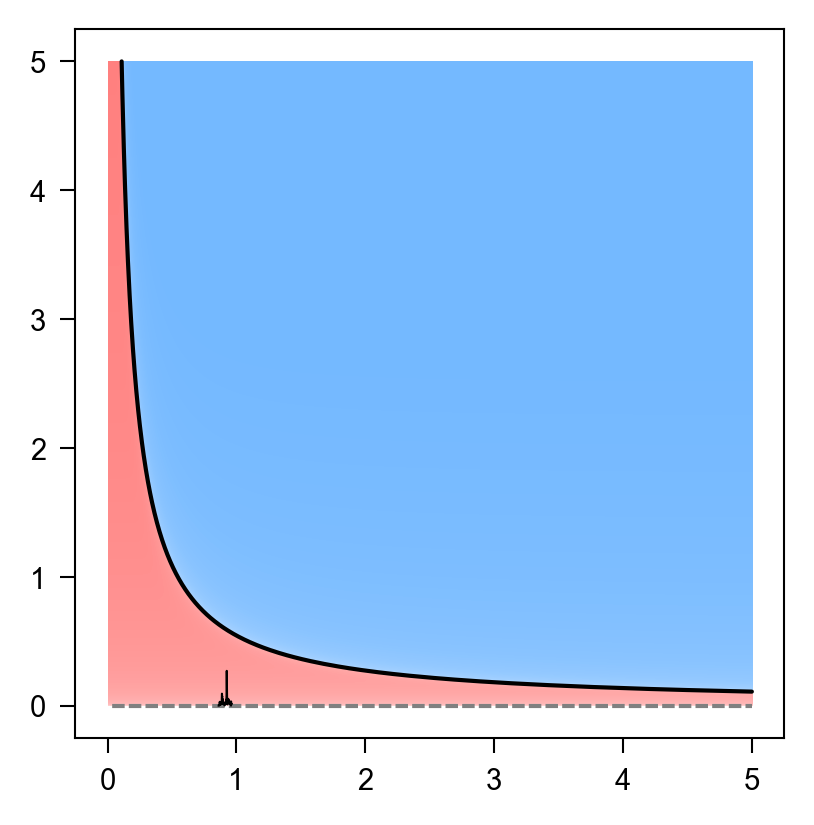

In [41]:
from ND2.utils import get_fig, plot_resilience
import matplotlib.colors as mcolors

def foo(beta_eff, x_eff):
    x7 = x_eff
    x14 = 2 * x_eff * X['x7_max'] / X['x14_max']
    sigmoid = lambda x: 1 / (1 + np.exp(-x))
    eq = 1.00 * x7 + -0.67 * x14 + 0.84 * x7 * sigmoid(1.00 / (beta_eff*((x14))) ** 2)
    eq = eq * X['y_max'] / X['x7_max'] - x7
    return eq

fi, fig, axes = get_fig(1, 1, AW=6, AH=6)
plot_resilience(foo, extent=(0, 5, 0, 5), ax=axes[0], norm=mcolors.SymLogNorm(linthresh=1e-5, linscale=1, vmin=-1, vmax=1), reset_xylim=True)

s_in = Aggr(f).eval(**X)
s_out = Aggr(f).eval(**X)
beta_eff = (s_out*s_in).sum(axis=-1) / (s_out).sum(axis=-1)
x_eff = (s_out*x7.eval(**X)).sum(axis=-1) / (s_out).sum(axis=-1)
axes[0].plot(beta_eff + 0*x_eff + np.linspace(-0.05, 0.05, len(beta_eff)), x_eff, 'k-', ms=1)

## NYS

In [84]:
name = 'NYS'
X, Y, x7, x14, f, data, evaluate = prepare_data(name)

# 平凡 Baseline
evaluate(x7)
evaluate(x14)
evaluate(Number(0.0), 10000)
evaluate(1.0 * x7, 10000)
evaluate(1.0 * x7 + 0.0 * x14, 10000)
C = Number(np.ones_like(Y[0]), nettype='node')
evaluate(C)
C1 = Number(np.ones_like(Y[0]), nettype='node')  
C2 = Number(np.zeros_like(Y[0]), nettype='node')
evaluate(C1 * x7 + C2 * x14, 10000)

eq = 0.26 * x7 - 0.41 * x14 + 1.3 * x7 * Sigmoid(Aggr(Sour(Aggr(f) - 0.053 * x14 * Aggr(Number(1, fitable=False)))))
evaluate(eq, 0)

pred = eq.eval(**X)
baseline = x7.eval(**X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".2f"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(Y, pred):.4f} ({r2_score(Y, pred)/r2_score(Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(Y, pred):.4f} ({rmse_score(Y, pred)/rmse_score(Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(Y, pred):.4f} ({mae_score(Y, pred)/mae_score(Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(Y, pred):.2%} ({smape_score(Y, pred)/smape_score(Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(Y, pred):.1%} ({mape_score(Y, pred)/mape_score(Y, baseline)-1:+.1%})')

[NYS] R2=0.7382, RMSE=0.0169, MAE=0.0026, SMAPE=35.85%, MAPE=626.7% 	 x7
[NYS] R2=0.5794, RMSE=0.0215, MAE=0.0033, SMAPE=39.89%, MAPE=961.6% 	 x14
[NYS] R2=-0.0000, RMSE=0.0331, MAE=0.0108, SMAPE=136.78%, MAPE=40747.8% 	 0.01
[NYS] R2=0.7544, RMSE=0.0164, MAE=0.0025, SMAPE=37.36%, MAPE=551.0% 	 0.88 * x7
[NYS] R2=0.7842, RMSE=0.0154, MAE=0.0025, SMAPE=42.92%, MAPE=588.8% 	 1.53 * x7 + -0.66 * x14
[NYS] R2=0.2081, RMSE=0.0295, MAE=0.0064, SMAPE=88.09%, MAPE=25103.2% 	 <0.01 (+0.02)>
[NYS] R2=0.8019, RMSE=0.0147, MAE=0.0025, SMAPE=37.36%, MAPE=480.1% 	 <1.02 (+0.19)> * x7 + <-0.07 (+0.21)> * x14
[NYS] R2=0.8508, RMSE=0.0128, MAE=0.0024, SMAPE=40.50%, MAPE=731.8% 	 0.26 * x7 - 0.41 * x14 + 1.30 * x7 * sigmoid(Aggr(Sour(Aggr(f) - 0.05 * x14 * Aggr(Constant(1.00)))))


<IPython.core.display.Latex object>

Eq: 0.26 * x7 - 0.41 * x14 + 1.30 * x7 * sigmoid(Aggr(Sour(Aggr(f) - 0.05 * x14 * Aggr(Constant(1.00)))))
Latex: 0.3x_{7} - 0.4x_{14} + 1.3x_{7} \times sigmoid(\rho(\phi_s(\rho(f) - 0.1x_{14} \times \rho(Constant(1.0)))))
R2: 0.8508 (+15.3%)
RMSE: 0.0128 (-24.5%)
MAE: 0.0024 (-6.7%)
SMAPE: 40.50% (+13.0%)
MAPE: 731.8% (+16.8%)


### G_ij 分析

In [71]:
dxdt = (eq * Number(X['y_max'] / X['x7_max'], fitable=False) - x7).copy()

N = X['A'].shape[0]
x_stable = Number(np.random.rand(N), 'node')
x_stable = Number(np.array([0.0009282787265816601,-0.0019294555043368996,0.001963127949439104,-0.002218091508827106,0.01935635779370918,0.001961161943522769,-0.00016836314949736773,-0.00014981015363607858,0.0016298725452707887,-0.007335310983534702,-0.003583752569375852,0.004024557313078043,-0.0017183438832606406,0.001643450265653123,-0.007672487875321104,-0.0010819415418287113,-0.0006186930207349977,-0.0007174728748801679,-0.0016895011172393464,0.0004368135407747091,-0.0002907350335653905,-0.008956005968698189,-0.0036453927933102924,0.001437732976076299,0.0029068344720423163,0.0002295583475296848,0.007690912195048239,-0.004769840014486074,-0.004981777565751133,-0.0034588182017640727,-0.00019015567854308333,-0.005387455582769484,0.002927801279432967,-0.004222466732504837,-0.03105134681328163,-0.0003105097424959456,-0.0011232843294437117,-0.0010409512814207266,-0.00030458484385892235,-0.005129679741402157,0.001227360680542021,0.0007358142283586718,0.001002281494665826,-0.0012930129072376247,0.001978055878964432,-0.002129723729030494,-0.00345134481030362,0.00018850114633654096,0.003211523391217107,-0.013682169151400707,-0.014711104224489116,-0.000591714640488809,-0.0014273748132330147,0.011910349515666862,-0.0006619539966815994,-0.00015096706361692624,-0.004129707965247553,-0.002844078848633444,0.010179119147034217,0.002183208673951993,-0.004052500033218693,0.0006749807445872846]), 'node')
tmp = dxdt.copy()
for item in tmp.preorder():
    if isinstance(item, Number):
        item.fitable = False
    if isinstance(item, Variable):
        if item.name == 'x7':
            item.replace(x_stable)
        if item.name == 'x14':
            item.replace(x_stable)
print(tmp.to_str(number_format='.2f'))

X_tmp = deepcopy(X)
X_tmp['f'] = X_tmp['f'][-1]
def loss(params):
    x_stable.value = params
    return np.mean((tmp.eval(**X_tmp)) ** 2)
res = minimize(loss, x_stable.value, method='BFGS', options={'maxiter': 10000})
res

(Constant(0.26) * <-0.00 (+0.01)> - Constant(0.41) * <-0.00 (+0.01)> + Constant(1.30) * <-0.00 (+0.01)> * sigmoid(Aggr(Sour(Aggr(f) - Constant(0.05) * <-0.00 (+0.01)> * Aggr(Constant(1.00)))))) * Constant(1.00) - <-0.00 (+0.01)>


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 2.789316251572707e-07
        x: [ 9.283e-04 -1.929e-03 ... -4.053e-03  6.750e-04]
      nit: 0
      jac: [ 1.477e-06 -1.662e-06 ... -2.468e-06  2.016e-06]
 hess_inv: [[1 0 ... 0 0]
            [0 1 ... 0 0]
            ...
            [0 0 ... 1 0]
            [0 0 ... 0 1]]
     nfev: 63
     njev: 1

In [72]:
dxdt.eval(**{**X, 'x7': res.x, 'x14': res.x})

array([[ 0.00013891,  0.00033177,  0.00029261, ...,  0.00032619,
         0.00057985, -0.00020503],
       [ 0.00013891,  0.00033177,  0.00029261, ...,  0.00032619,
         0.00057985, -0.00020503],
       [ 0.00013891,  0.00033177,  0.00029261, ...,  0.00032619,
         0.00057985, -0.00020503],
       ...,
       [ 0.00013891,  0.00033177,  0.00029261, ...,  0.00032619,
         0.00057985, -0.00020503],
       [ 0.00013891,  0.00033177,  0.00029261, ...,  0.00032619,
         0.00057985, -0.00020503],
       [ 0.00013891,  0.00033177,  0.00029261, ...,  0.00032619,
         0.00057985, -0.00020503]])

In [94]:
print(','.join(map(str, x_stable.value.tolist())))

0.0009282787265816601,-0.0019294555043368996,0.001963127949439104,-0.002218091508827106,0.01935635779370918,0.001961161943522769,-0.00016836314949736773,-0.00014981015363607858,0.0016298725452707887,-0.007335310983534702,-0.003583752569375852,0.004024557313078043,-0.0017183438832606406,0.001643450265653123,-0.007672487875321104,-0.0010819415418287113,-0.0006186930207349977,-0.0007174728748801679,-0.0016895011172393464,0.0004368135407747091,-0.0002907350335653905,-0.008956005968698189,-0.0036453927933102924,0.001437732976076299,0.0029068344720423163,0.0002295583475296848,0.007690912195048239,-0.004769840014486074,-0.004981777565751133,-0.0034588182017640727,-0.00019015567854308333,-0.005387455582769484,0.002927801279432967,-0.004222466732504837,-0.03105134681328163,-0.0003105097424959456,-0.0011232843294437117,-0.0010409512814207266,-0.00030458484385892235,-0.005129679741402157,0.001227360680542021,0.0007358142283586718,0.001002281494665826,-0.0012930129072376247,0.001978055878964432,-0

100%|██████████| 62/62 [00:05<00:00, 12.11it/s]


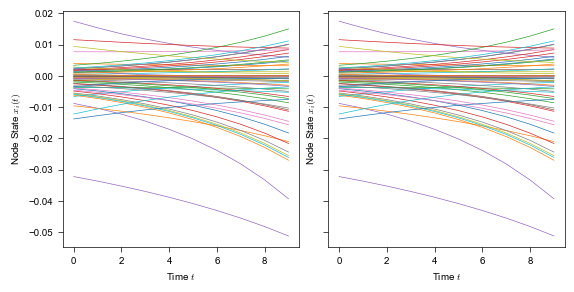

In [73]:
from copy import deepcopy

X0 = deepcopy(X)
X0['x7'] = deepcopy(x_stable.value)
X0['x14'] = deepcopy(x_stable.value)
X0['f'] = X0['f'][-1]

traj = []
X_cur = deepcopy(X0)
for _ in range(10):
    # y = eq.eval(**X_cur)
    # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
    # X_cur['x7'] = y * X['y_max'] / X['x7_max']
    dx = dxdt.eval(**X_cur)
    X_cur['x7'] = X_cur['x7'] + dx
    X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
    traj.append(X_cur['x7'])
X_baseline = traj[-1]

from ND2.utils import get_fig
fi, fig, axes = get_fig(1, 2, AW=6, AH=6, dpi=100, sharey=True)
axes[0].plot(traj)
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('Node State $x_i(t)$')

from tqdm import tqdm
G = []
p = 1e-4
for j in tqdm(range(N)):
    X00 = deepcopy(X0)
    X00['x7'][j] += p
    X00['x14'][j] += p / 2

    traj = []
    X_cur = X00.copy()
    for _ in range(10):
        # y = eq.eval(**X_cur)
        # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
        # X_cur['x7'] = y * X['y_max'] / X['x7_max']
        dx = dxdt.eval(**X_cur)
        X_cur['x7'] = X_cur['x7'] + dx
        X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
        # X_cur['x7'][j] = X00['x7'][j]
        # X_cur['x14'][j] = X00['x14'][j]
        traj.append(X_cur['x7'])
    dxi = (traj[-1] - X_baseline)
    dxj = p
    G.append(dxi / x_stable.value / dxj * x_stable.value[j])

    if j == 0:
        axes[1].plot(traj)
        axes[1].set_xlabel('Time $t$')
        axes[1].set_ylabel('Node State $x_i(t)$')

G_dict[name] = np.stack(G, axis=1)

[-1.26139935 -5.62139663]


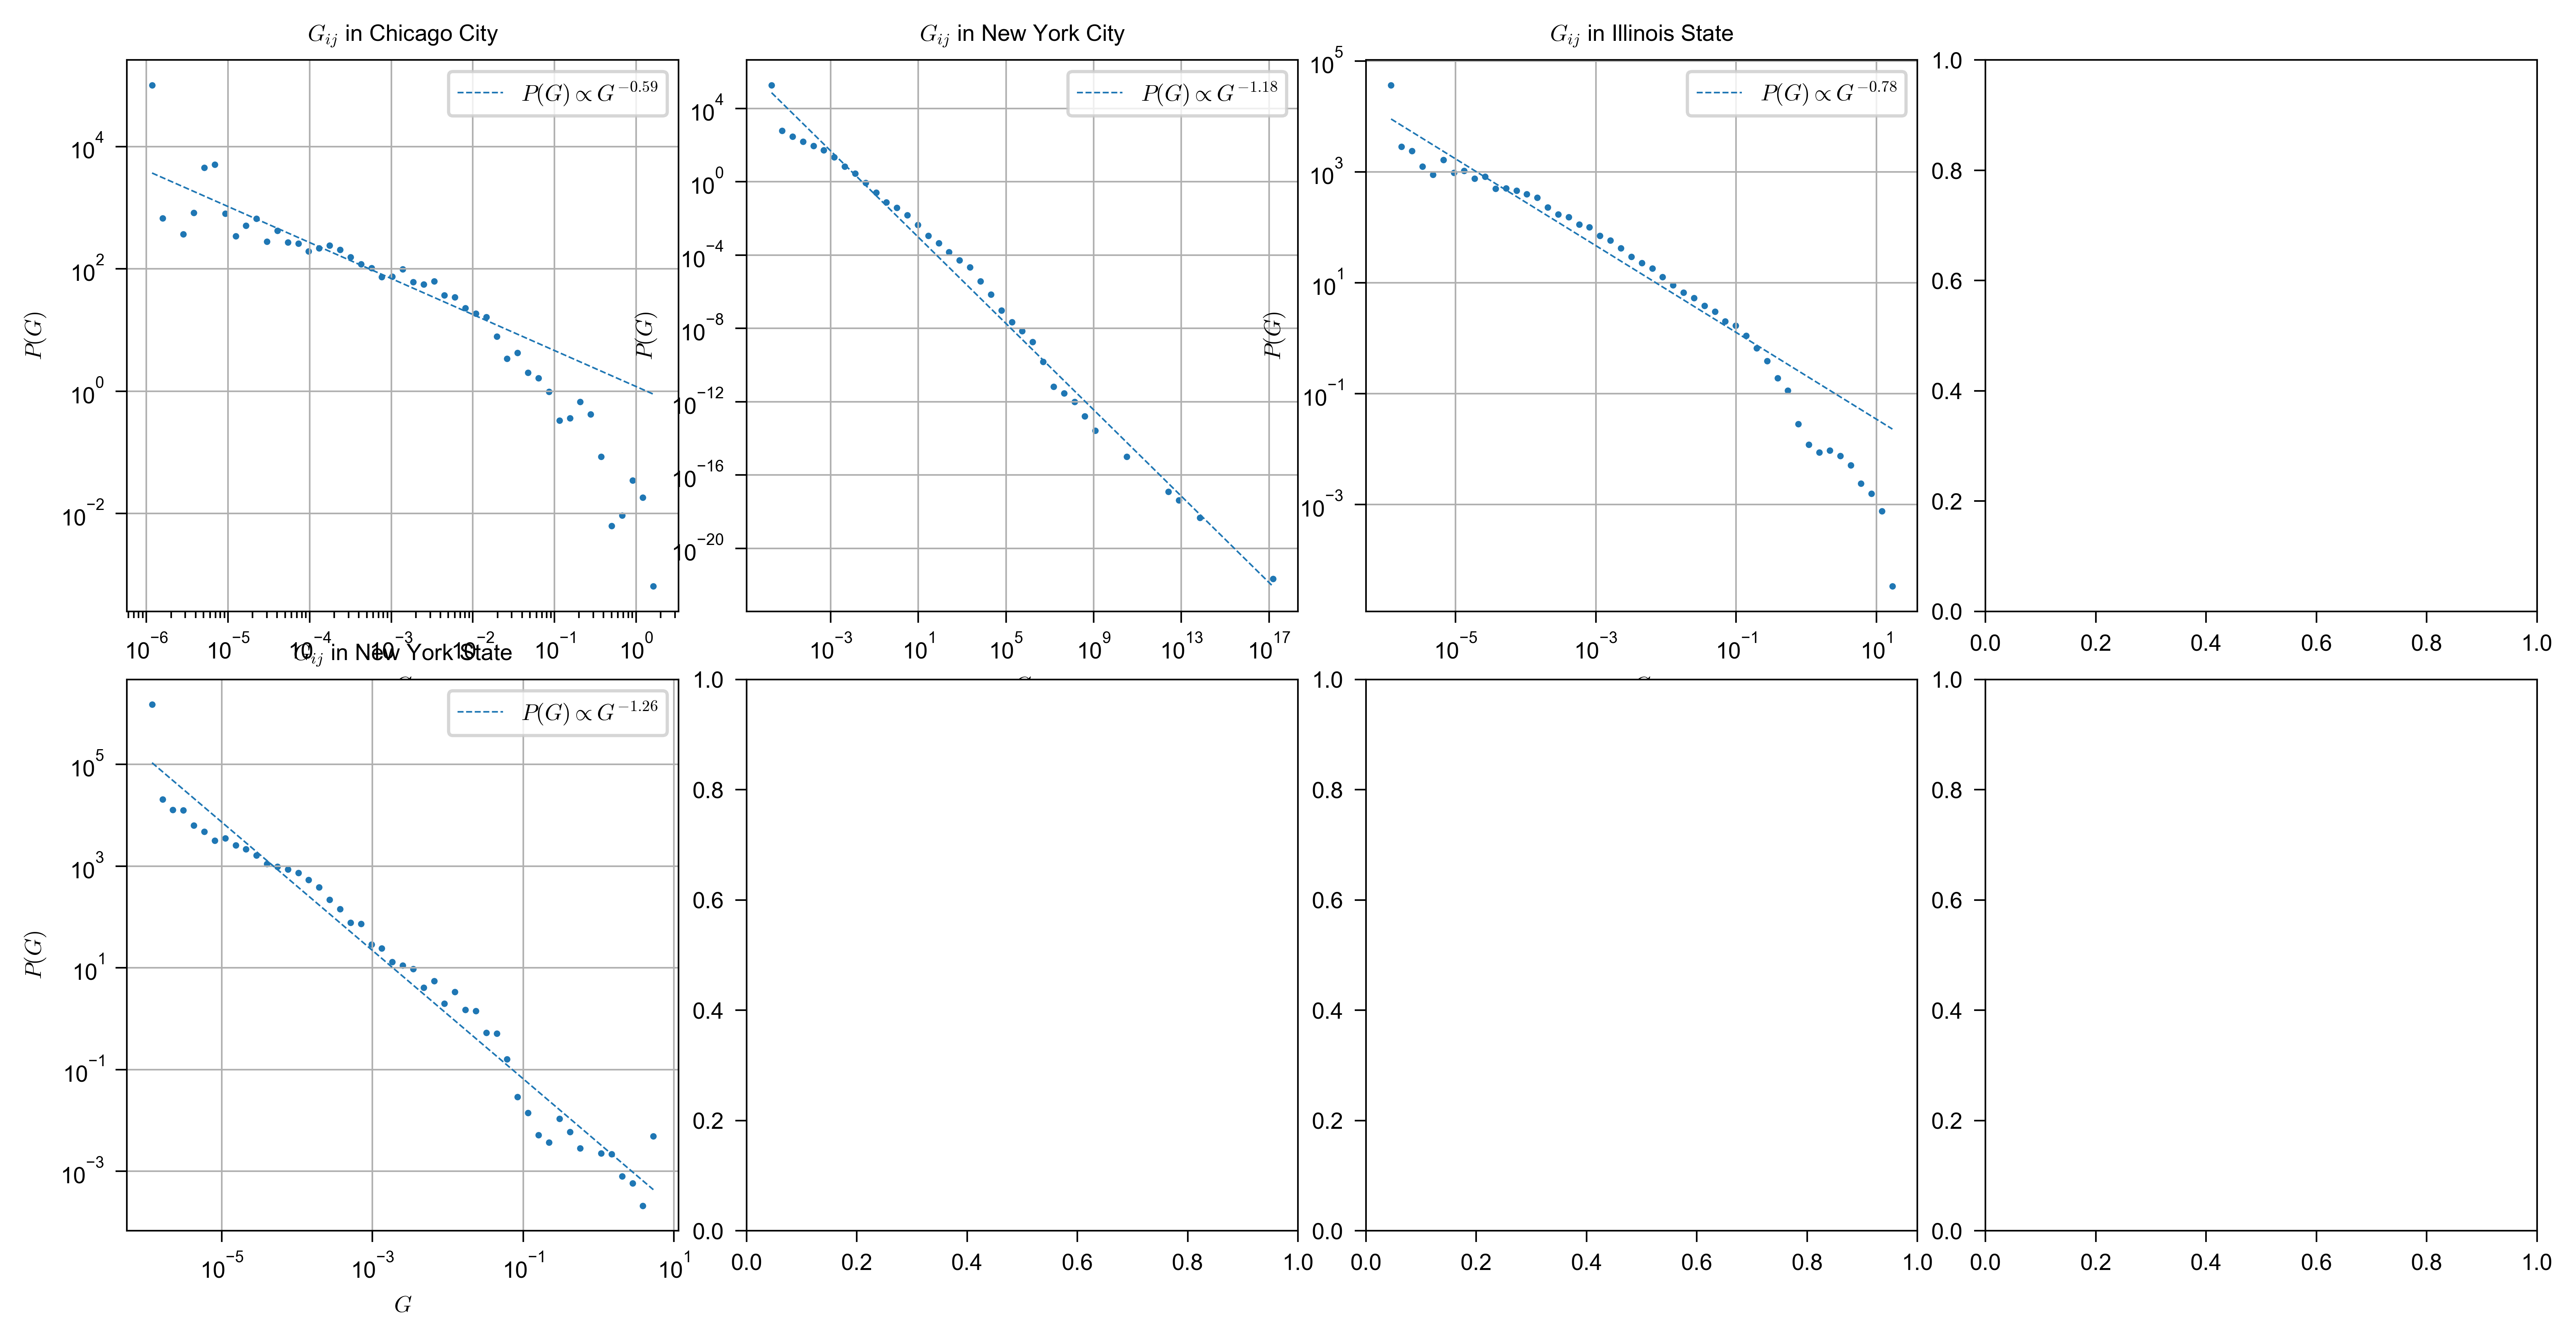

In [74]:
import numpy as np

# 示例数据，假设 x 是一个包含浮点数的 ndarray
# x = np.random.power(0.1, 10000)  # 示例数据，可以替换为你的数据
x = np.abs(G_dict[name]).clip(1e-6, None)
x = x[~np.isnan(x)]
# x = np.random.normal(0, 1, 10000)
# x = np.abs(x) + 1e-6

# 设置直方图的边界
M = 50
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), M)

# 计算直方图
hist, bin_edges = np.histogram(x, bins=bins)
freq = hist / np.diff(bin_edges) / len(x)

# 计算每个 bin 的中心
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# 过滤掉频率为零的 bin
nonzero = freq > 0
bin_centers = bin_centers[nonzero]
freq = freq[nonzero]

# 使用对数坐标绘图
ax = axes_G[4]
ax.clear()
ax.scatter(bin_centers, freq, s=1)

# polyfit
a = np.polyfit(np.log(bin_centers[:50]), np.log(freq[:50]), 1)
print(a)
plot_x = np.logspace(np.log10(np.min(bin_centers)), np.log10(np.max(bin_centers)), 100)
plot_y = np.exp(np.polyval(a, np.log(plot_x)))
ax.plot(plot_x, plot_y, '--', color='C0', label=f'$P(G) \propto G^{{{a[0]:.2f}}}$')


ax.set_title('$G_{ij}$ in New York State')
ax.set_xlabel('$G$')
ax.set_ylabel('$P(G)$')
ax.legend()
ax.loglog()
ax.grid()

display(fig_G)

### Resilience 分析

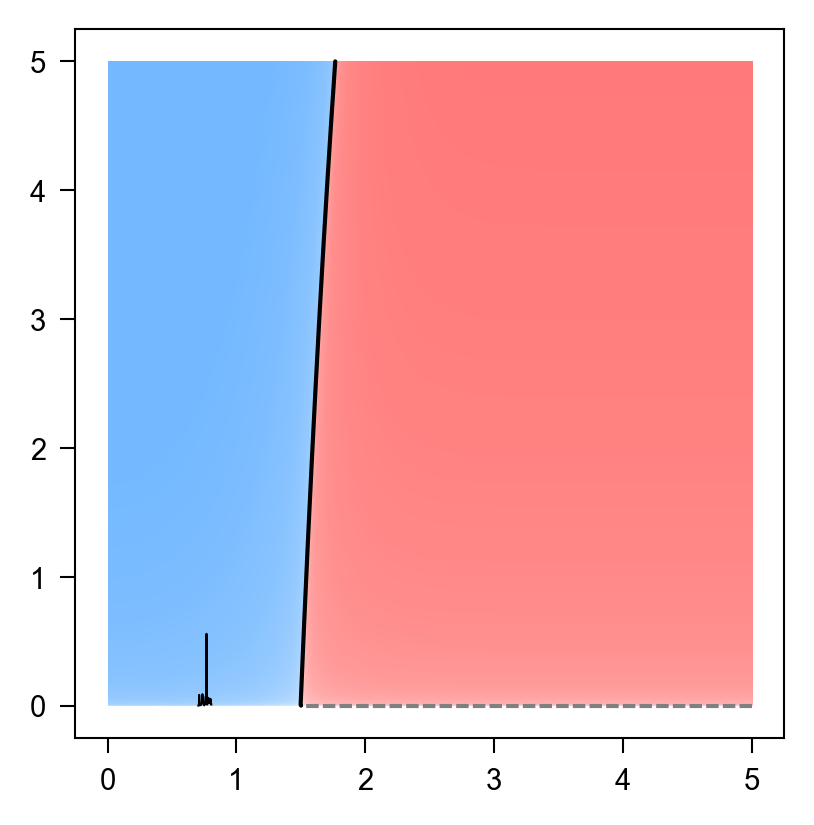

In [44]:
from ND2.utils import get_fig, plot_resilience
import matplotlib.colors as mcolors

def foo(beta_eff, x_eff):
    x7 = x_eff
    x14 = 2 * x_eff * X['x7_max'] / X['x14_max']
    sigmoid = lambda x: 1 / (1 + np.exp(-x))
    eq = 0.26 * x7 - 0.41 * x14 + 1.3 * x7 * sigmoid(beta_eff*((beta_eff - 0.053 * x14 * beta_eff*((1)))))
    eq = eq * X['y_max'] / X['x7_max'] - x7
    return eq

fi, fig, axes = get_fig(1, 1, AW=6, AH=6)
plot_resilience(foo, extent=(0, 5, 0, 5), ax=axes[0], norm=mcolors.SymLogNorm(linthresh=1e-5, linscale=1, vmin=-1, vmax=1), reset_xylim=True)

s_in = Aggr(f).eval(**X)
s_out = Aggr(f).eval(**X)
beta_eff = (s_out*s_in).sum(axis=-1) / (s_out).sum(axis=-1)
x_eff = (s_out*x7.eval(**X)).sum(axis=-1) / (s_out).sum(axis=-1)
axes[0].plot(beta_eff + 0*x_eff + np.linspace(-0.05, 0.05, len(beta_eff)), x_eff, 'k-', ms=1)

## CN

In [53]:
name = 'CN'
X, Y, x7, x14, f, data, evaluate = prepare_data(name)

# 平凡 Baseline
evaluate(x7)
evaluate(x14)
evaluate(Number(10.0), 10000)
evaluate(1.0 * x7, 10000)
evaluate(1.0 * x7 + 0.0 * x14, 10000)
C = Number(np.ones_like(Y[0]), nettype='node')
evaluate(C)
C1 = Number(np.ones_like(Y[0]), nettype='node')  
C2 = Number(np.zeros_like(Y[0]), nettype='node')
evaluate(C1 * x7 + C2 * x14, 10000)

# eq = 2.16 * x7 - 1.07 * x14 * x7 + 3.50 * Pow3(x7) * (Aggr(f) - 1.01)
eq = 1.31 * x7 - 1 * x14 * x7 - 2.28 * Pow3(x7) + 3.07 * Aggr(f * Targ(Pow3(x7)))
# eq = 1.49 * x7 - 0.554 * x14 + 0.0265 * Aggr(f * Sour(x7))
evaluate(eq, 10000)

pred = eq.eval(**X)
baseline = x7.eval(**X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".3g"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(Y, pred):.4f} ({r2_score(Y, pred)/r2_score(Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(Y, pred):.4f} ({rmse_score(Y, pred)/rmse_score(Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(Y, pred):.4f} ({mae_score(Y, pred)/mae_score(Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(Y, pred):.2%} ({smape_score(Y, pred)/smape_score(Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(Y, pred):.1%} ({mape_score(Y, pred)/mape_score(Y, baseline)-1:+.1%})')

[CN] R2=0.8908, RMSE=0.0143, MAE=0.0011, SMAPE=62.92%, MAPE=4157.8% 	 x7
[CN] R2=0.8338, RMSE=0.0177, MAE=0.0015, SMAPE=72.99%, MAPE=7210.3% 	 x14
[CN] R2=-0.0000, RMSE=0.0434, MAE=0.0081, SMAPE=193.23%, MAPE=216741.9% 	 0.00
[CN] R2=0.8938, RMSE=0.0141, MAE=0.0011, SMAPE=63.16%, MAPE=3933.5% 	 0.95 * x7
[CN] R2=0.9022, RMSE=0.0136, MAE=0.0009, SMAPE=74.95%, MAPE=4561.2% 	 1.50 * x7 + -0.56 * x14
[CN] R2=0.1864, RMSE=0.0391, MAE=0.0062, SMAPE=167.13%, MAPE=34098.4% 	 <0.00 (+0.02)>
[CN] R2=0.9085, RMSE=0.0131, MAE=0.0009, SMAPE=63.71%, MAPE=3655.0% 	 <1.03 (+0.15)> * x7 + <-0.04 (+0.16)> * x14
[CN] R2=0.9187, RMSE=0.0124, MAE=0.0010, SMAPE=64.39%, MAPE=5194.0% 	 1.31 * x7 - 1.00 * x14 * x7 - 2.28 * x7 ** 3 + 3.07 * Aggr(f * Targ(x7 ** 3))


<IPython.core.display.Latex object>

Eq: 1.31 * x7 - 1 * x14 * x7 - 2.28 * x7 ** 3 + 3.07 * Aggr(f * Targ(x7 ** 3))
Latex: 1.3x_{7} - 1.0x_{14} \times x_{7} - 2.3 \times x_{7}^3 + 3.1 \times \rho(f \times \phi_t(x_{7}^3))
R2: 0.9187 (+3.1%)
RMSE: 0.0124 (-13.7%)
MAE: 0.0010 (-12.2%)
SMAPE: 64.39% (+2.3%)
MAPE: 5194.0% (+24.9%)


### G_ij 分析

In [76]:
dxdt = (eq * Number(X['y_max'] / X['x7_max'], fitable=False) - x7).copy()

N = X['A'].shape[0]
x_stable = Number(np.random.rand(N), 'node')
x_stable = Number(np.array([0.0004120689158711825,-0.0010698869582905024,0.00031878543321549297,-9.97578006203188e-06,3.6950445344644493e-05,0.00012025889718752044,2.6428936864339577e-05,0.0003022520531181066,-0.0001404243900919924,0.29170790698035864,-0.00015617959863451522,-0.0004899992401761267,8.213124338783413e-05,-1.0374172339868565e-05,-1.0943035999494259e-05,-0.00037912282531743285,0.00011938426084876885,2.0046466514398202e-05,-0.00034174577790329675,4.5631710374766034e-05,0.00014999815971134556,0.2775678328794496,0.00029451286788099887,-9.342853923615085e-06,-0.00014033757419558185,0.00014591971612246243,4.488276432003033e-05,5.613856792256364e-05,0.41194559323351815,-2.5265295961270393e-05,0.00040023542277618004,0.00031620610537501966,0.00011052572994876787,0.0012725794341076559
]), 'node')
tmp = dxdt.copy()
for item in tmp.preorder():
    if isinstance(item, Number):
        item.fitable = False
    if isinstance(item, Variable):
        if item.name == 'x7':
            item.replace(x_stable)
        if item.name == 'x14':
            item.replace(x_stable)
print(tmp.to_str(number_format='.2f'))

X_tmp = deepcopy(X)
X_tmp['f'] = X_tmp['f'][-1]
def loss(params):
    x_stable.value = params
    return np.mean((tmp.eval(**X_tmp)) ** 2)
res = minimize(loss, x_stable.value, method='BFGS', options={'maxiter': 10000})
res

(Constant(1.31) * <0.03 (+0.09)> - Constant(1.00) * <0.03 (+0.09)> * <0.03 (+0.09)> - Constant(2.28) * <0.03 (+0.09)> ** 3 + Constant(3.07) * Aggr(f * Targ(<0.03 (+0.09)> ** 3))) * Constant(1.00) - <0.03 (+0.09)>


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.1605390684559707e-08
        x: [ 4.121e-04 -1.070e-03 ...  1.105e-04  1.273e-03]
      nit: 0
      jac: [ 2.263e-06 -5.963e-06 ...  6.088e-07  6.932e-06]
 hess_inv: [[1 0 ... 0 0]
            [0 1 ... 0 0]
            ...
            [0 0 ... 1 0]
            [0 0 ... 0 1]]
     nfev: 35
     njev: 1

In [104]:
dxdt.eval(**{**X_tmp, 'x7': res.x, 'x14': res.x})

array([ 1.25993541e-04, -3.28738155e-04,  9.75013913e-05, -3.05440022e-06,
        1.13118074e-05,  3.68053969e-05,  8.09108918e-06,  9.24494987e-05,
       -4.30137571e-05, -7.49608242e-05, -4.78422293e-05, -1.50265166e-04,
        2.51394884e-05, -3.17638475e-06, -3.35056680e-06, -1.16220878e-04,
        3.65377935e-05,  6.13725552e-06, -1.04749997e-04,  1.39690457e-05,
        4.59026058e-05,  3.62996983e-05,  9.00844610e-05, -2.86060396e-06,
       -4.29871562e-05,  4.46551731e-05,  1.37398072e-05,  1.71848758e-05,
       -3.69139362e-06, -7.73615595e-06,  1.22380003e-04,  9.67131188e-05,
        3.38275999e-05,  3.88026746e-04])

In [105]:
print(','.join(map(str, x_stable.value.tolist())))

0.0004120689158711825,-0.0010698869582905024,0.00031878543321549297,-9.97578006203188e-06,3.6950445344644493e-05,0.00012025889718752044,2.6428936864339577e-05,0.0003022520531181066,-0.0001404243900919924,0.29170790698035864,-0.00015617959863451522,-0.0004899992401761267,8.213124338783413e-05,-1.0374172339868565e-05,-1.0943035999494259e-05,-0.00037912282531743285,0.00011938426084876885,2.0046466514398202e-05,-0.00034174577790329675,4.5631710374766034e-05,0.00014999815971134556,0.2775678328794496,0.00029451286788099887,-9.342853923615085e-06,-0.00014033757419558185,0.00014591971612246243,4.488276432003033e-05,5.613856792256364e-05,0.41194559323351815,-2.5265295961270393e-05,0.00040023542277618004,0.00031620610537501966,0.00011052572994876787,0.0012725794341076559


100%|██████████| 34/34 [00:00<00:00, 64.86it/s]


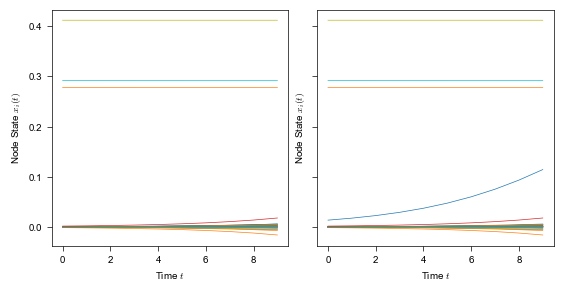

In [77]:
from copy import deepcopy

X0 = deepcopy(X)
X0['x7'] = deepcopy(x_stable.value)
X0['x14'] = deepcopy(x_stable.value)
X0['f'] = X0['f'][-1]

traj = []
X_cur = deepcopy(X0)
for _ in range(10):
    # y = eq.eval(**X_cur)
    # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
    # X_cur['x7'] = y * X['y_max'] / X['x7_max']
    dx = dxdt.eval(**X_cur)
    X_cur['x7'] = X_cur['x7'] + dx
    X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
    traj.append(X_cur['x7'])
X_baseline = traj[-1]

from ND2.utils import get_fig
fi, fig, axes = get_fig(1, 2, AW=6, AH=6, dpi=100, sharey=True)
axes[0].plot(traj)
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('Node State $x_i(t)$')

from tqdm import tqdm
G = []
p = 1e-2
for j in tqdm(range(N)):
    X00 = deepcopy(X0)
    X00['x7'][j] += p
    X00['x14'][j] += p / 2

    traj = []
    X_cur = X00.copy()
    for _ in range(10):
        # y = eq.eval(**X_cur)
        # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
        # X_cur['x7'] = y * X['y_max'] / X['x7_max']
        dx = dxdt.eval(**X_cur)
        X_cur['x7'] = X_cur['x7'] + dx
        X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
        # X_cur['x7'][j] = X00['x7'][j]
        # X_cur['x14'][j] = X00['x14'][j]
        traj.append(X_cur['x7'])
    dxi = (traj[-1] - X_baseline)
    dxj = p
    G.append(dxi / x_stable.value / dxj * x_stable.value[j])

    if j == 0:
        axes[1].plot(traj)
        axes[1].set_xlabel('Time $t$')
        axes[1].set_ylabel('Node State $x_i(t)$')

G_dict[name] = np.stack(G, axis=1)

[-1.23586301 -4.91362707]


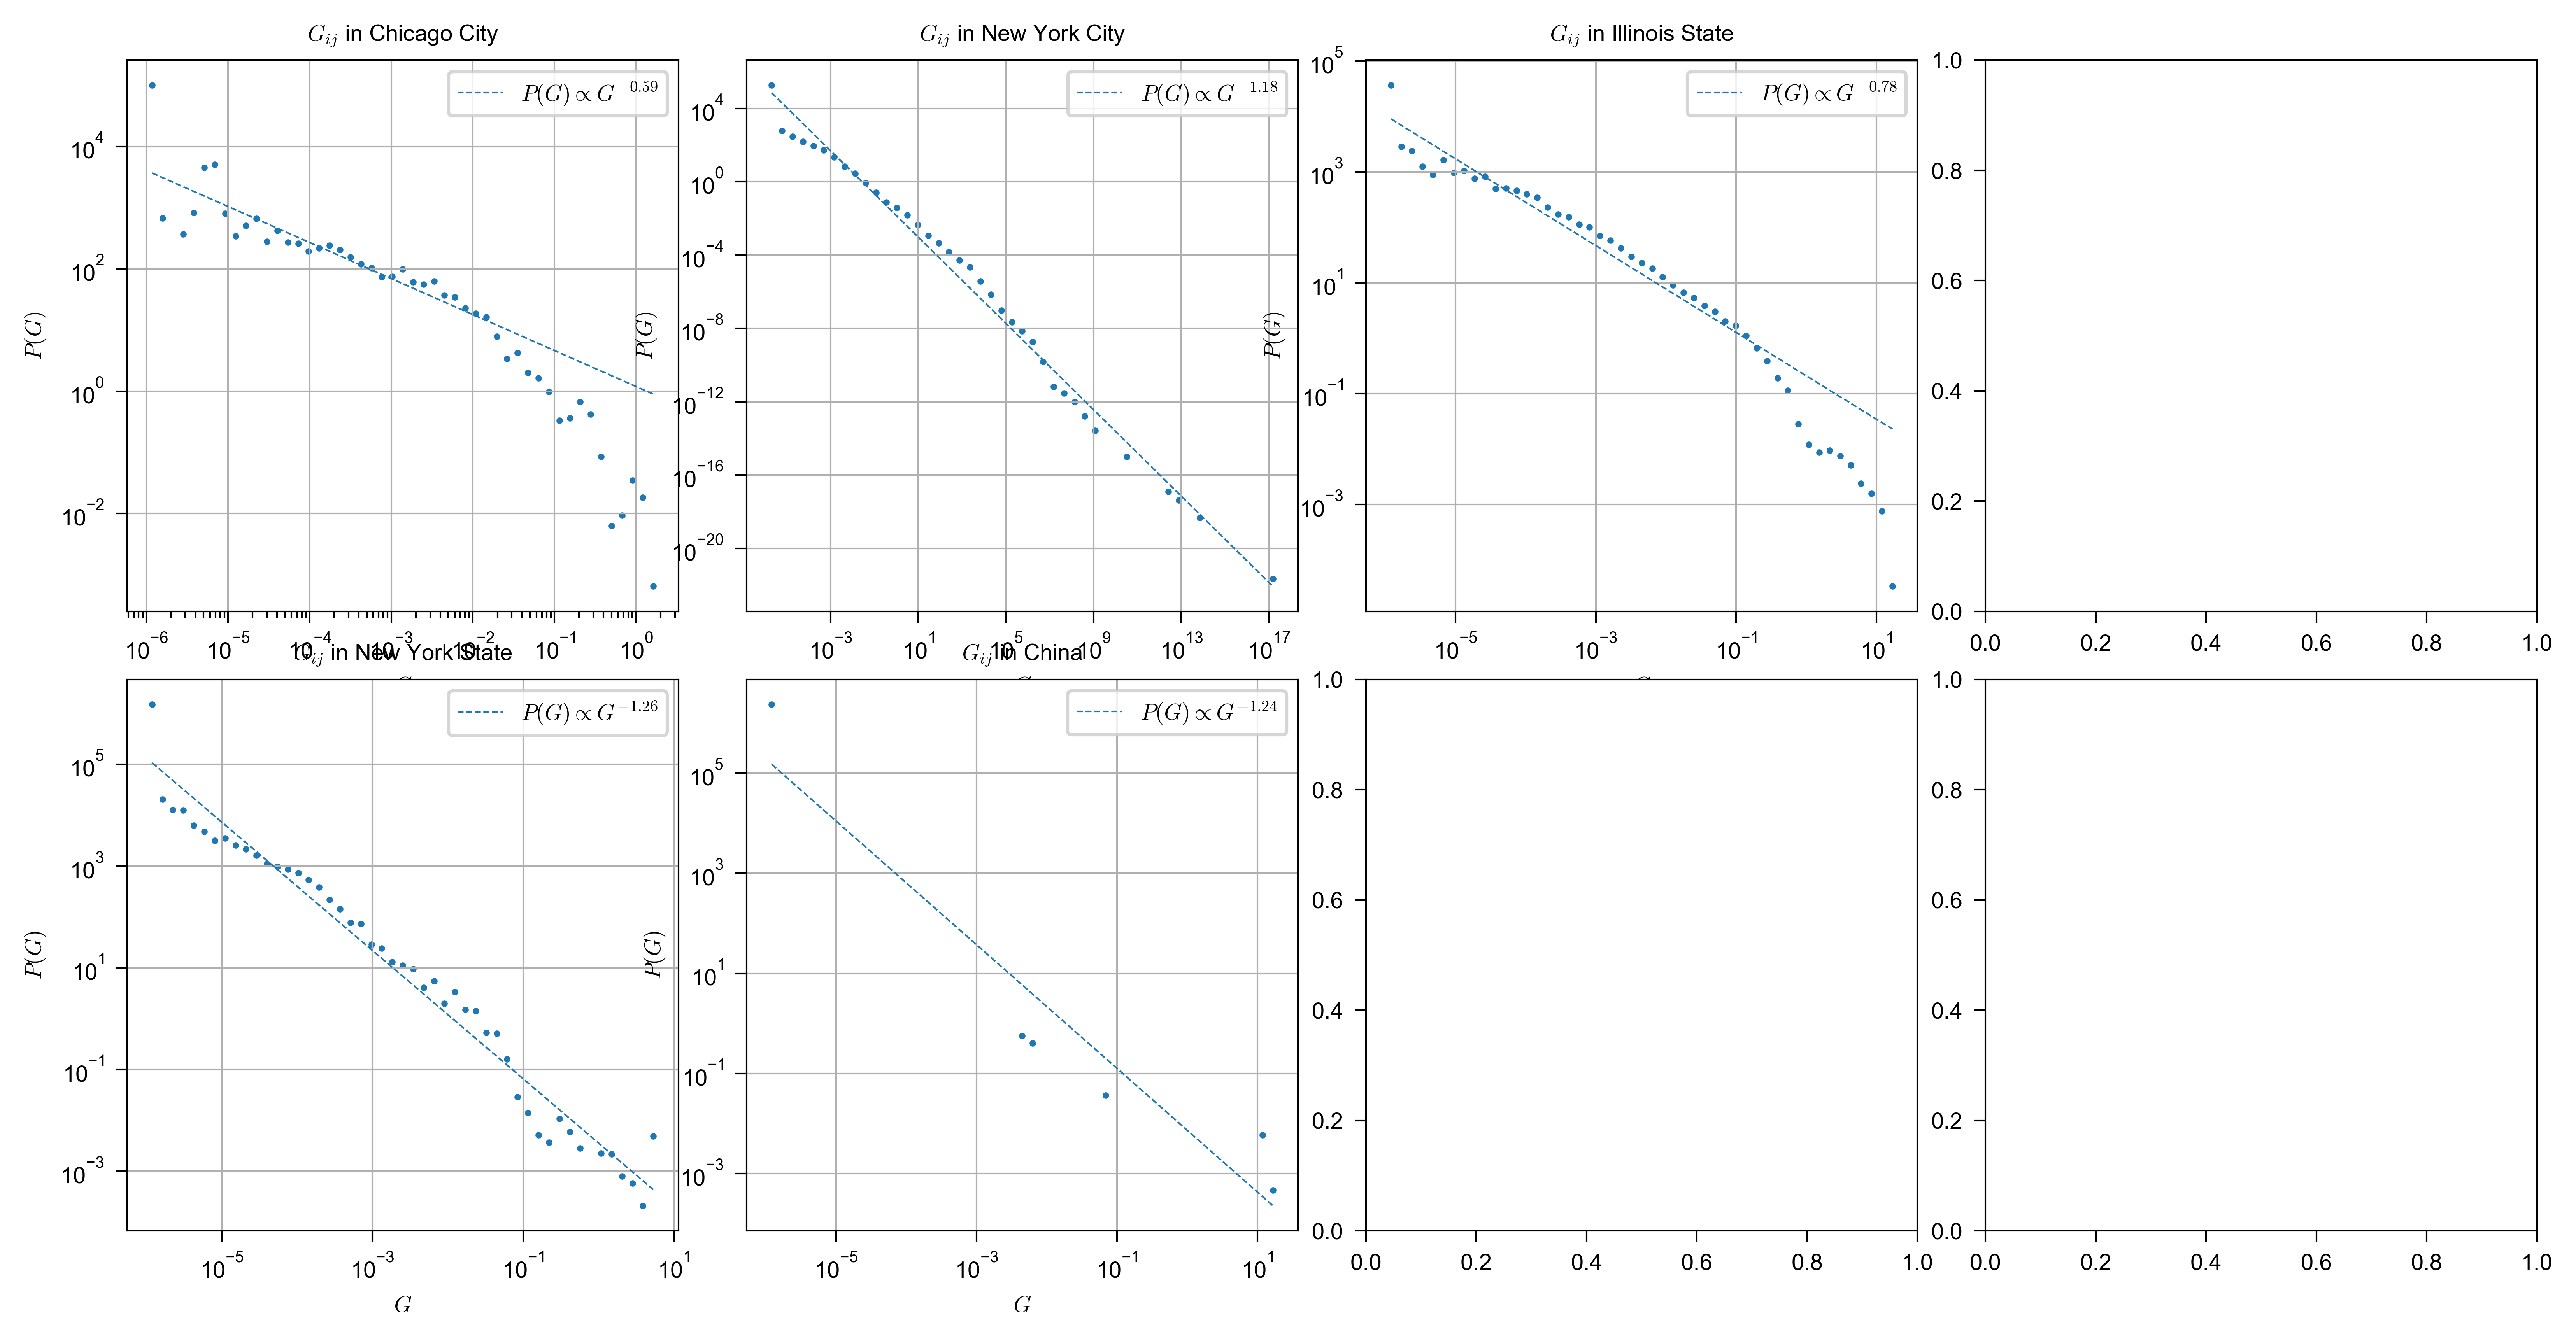

In [78]:
import numpy as np

# 示例数据，假设 x 是一个包含浮点数的 ndarray
# x = np.random.power(0.1, 10000)  # 示例数据，可以替换为你的数据
x = np.abs(G_dict[name]).clip(1e-6, None)
x = x[~np.isnan(x)]
# x = np.random.normal(0, 1, 10000)
# x = np.abs(x) + 1e-6

# 设置直方图的边界
M = 50
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), M)

# 计算直方图
hist, bin_edges = np.histogram(x, bins=bins)
freq = hist / np.diff(bin_edges) / len(x)

# 计算每个 bin 的中心
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# 过滤掉频率为零的 bin
nonzero = freq > 0
bin_centers = bin_centers[nonzero]
freq = freq[nonzero]

# 使用对数坐标绘图
ax = axes_G[5]
ax.clear()
ax.scatter(bin_centers, freq, s=1)

# polyfit
a = np.polyfit(np.log(bin_centers[:37]), np.log(freq[:37]), 1)
print(a)
plot_x = np.logspace(np.log10(np.min(bin_centers)), np.log10(np.max(bin_centers)), 100)
plot_y = np.exp(np.polyval(a, np.log(plot_x)))
ax.plot(plot_x, plot_y, '--', color='C0', label=f'$P(G) \propto G^{{{a[0]:.2f}}}$')


ax.set_title('$G_{ij}$ in China')
ax.set_xlabel('$G$')
ax.set_ylabel('$P(G)$')
ax.legend()
ax.loglog()
ax.grid()

display(fig_G)

### Resilience 分析

In [5]:
from ND2.env import simplify
eq = simplify(eq * X['y_max'] / X['x7_max'] - x7)
pred = eq.eval(**X)
print('Eq:', eq.to_str(number_format=".3g"))

Failed to simplify (1.3061715878275373 * x7 - 1.0028251932877414 * x14 * x7 - 2.2819224016675297 * x7 ** 3 + 3.0680515430164776 * Aggr(f * Targ(x7 ** 3))) * 571901.0 / 571901.0 - x7: 'Aggr'


Eq: (1.31 * x7 - 1 * x14 * x7 - 2.28 * x7 ** 3 + 3.07 * Aggr(f * Targ(x7 ** 3))) * 5.72e+05 / 5.72e+05 - x7


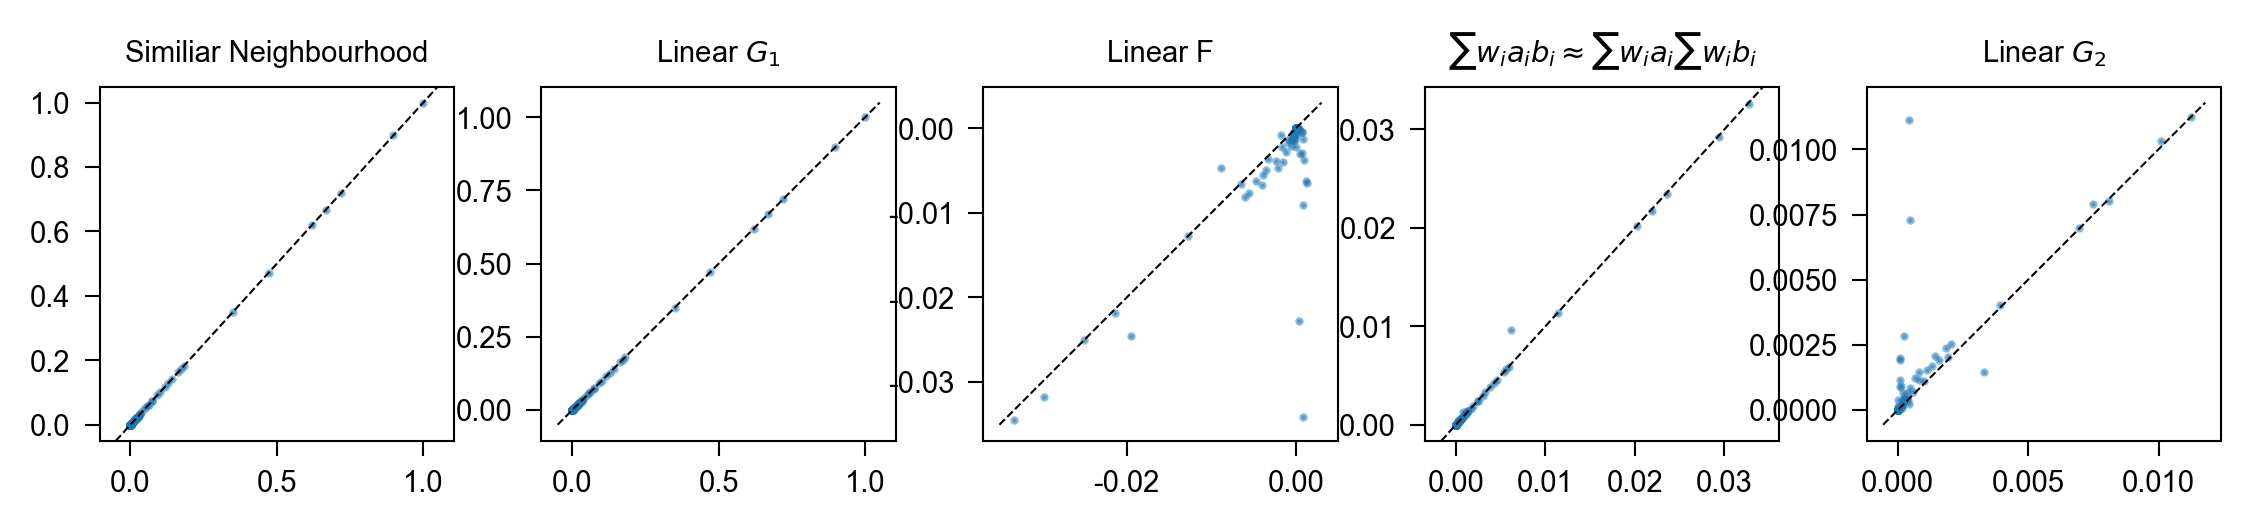

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

from ND2.utils import get_fig
fi, fig, axes = get_fig(1, 5, AW=3, AH=3)

X, Y, x7, x14, f, data, evaluate = prepare_data(name)

# 要检查的动力学方程
eq = 0.31 * x7 - 1 * x14 * x7 - 2.28 * x7 ** 3 + 3.07 * Aggr(f * Targ(x7 ** 3))
F = 0.31 * x7 - 1 * x14 * x7 - 2.28 * x7 ** 3
A = 3.07 * f
G = Sour(1) * Targ(x7 ** 3)
# Current we have eq = F + Aggr(A * G)

A2 = np.ones_like(X['A'])
G2 = np.stack(np.nonzero(A2), axis=-1)
s_out = Number((Rgga(A) / Readout(Rgga(A))).eval(**X), nettype='node')
a = (Aggr(A*G) / Aggr(A)).eval(**X) # a_i = sum_j A_ji G(xi, xj) / sum_j A_ji
b = Aggr(Sour(s_out) * G).eval(**{**X, 'A': A2, 'G': G2}) # Readout(Aggr(A)) = Read(Rgga(A)), Readout(Aggr(A*Sour(x7))) ~ Readout(Rgga(A)*x7)
axes[0].scatter(a, b+0*a, s=1, alpha=0.5)
axes[0].set_title('Similiar Neighbourhood')
axes[0].set_ylim(*axes[0].get_xlim())

b = b # b_i = sum_j s_out_j G(xi, xj)
c = (1 * x7 ** 3).eval(**X) + 0*b # c_i = G(xj=x_eff, xi)  # 需要根据 G 修改！！！
axes[1].scatter(b, c, s=1, alpha=0.5)
axes[1].set_title('Linear $G_1$')

x7_eff = Readout(s_out * x7) # x7_eff = sum_j s_out_j xj
x14_eff = 2 * x7_eff * X['x7_max'] / X['x14_max']
# x14_eff = Readout(s_out * x14) * X['x14_max'] / X['x7_max']
d = Readout(s_out * F).eval(**X)
e = (-F**3 / 1.11635819e-06).eval(**{**X, 'x7': x7_eff.eval(**X), 'x14': x14_eff.eval(**X)})
axes[2].scatter(d, e, s=1, alpha=0.5)
axes[2].set_title('Linear F')

h = Readout(s_out * Aggr(A) * c).eval(**X)
k = (Readout(s_out * Aggr(A)) * Readout(s_out * c) / 4.24870286).eval(**X)
axes[3].scatter(h, k, s=1, alpha=0.5)
axes[3].set_title(r'$\sum w_ia_ib_i\approx\sum w_ia_i\sum w_ib_i$')
axes[3].set_ylim(*axes[3].get_xlim())

l = Readout(s_out * c).eval(**X)
m = (1 * x7_eff ** 3 / 1.29388340e-04).eval(**X)# c_i = G(xj=x_eff, xi)  # 需要根据 G 修改！！！
axes[4].scatter(l, m, s=1, alpha=0.5)
axes[4].set_title('Linear $G_2$')

for ax in axes:
    ax.plot(ax.get_xlim(), ax.get_xlim(), 'k--')

plt.show()

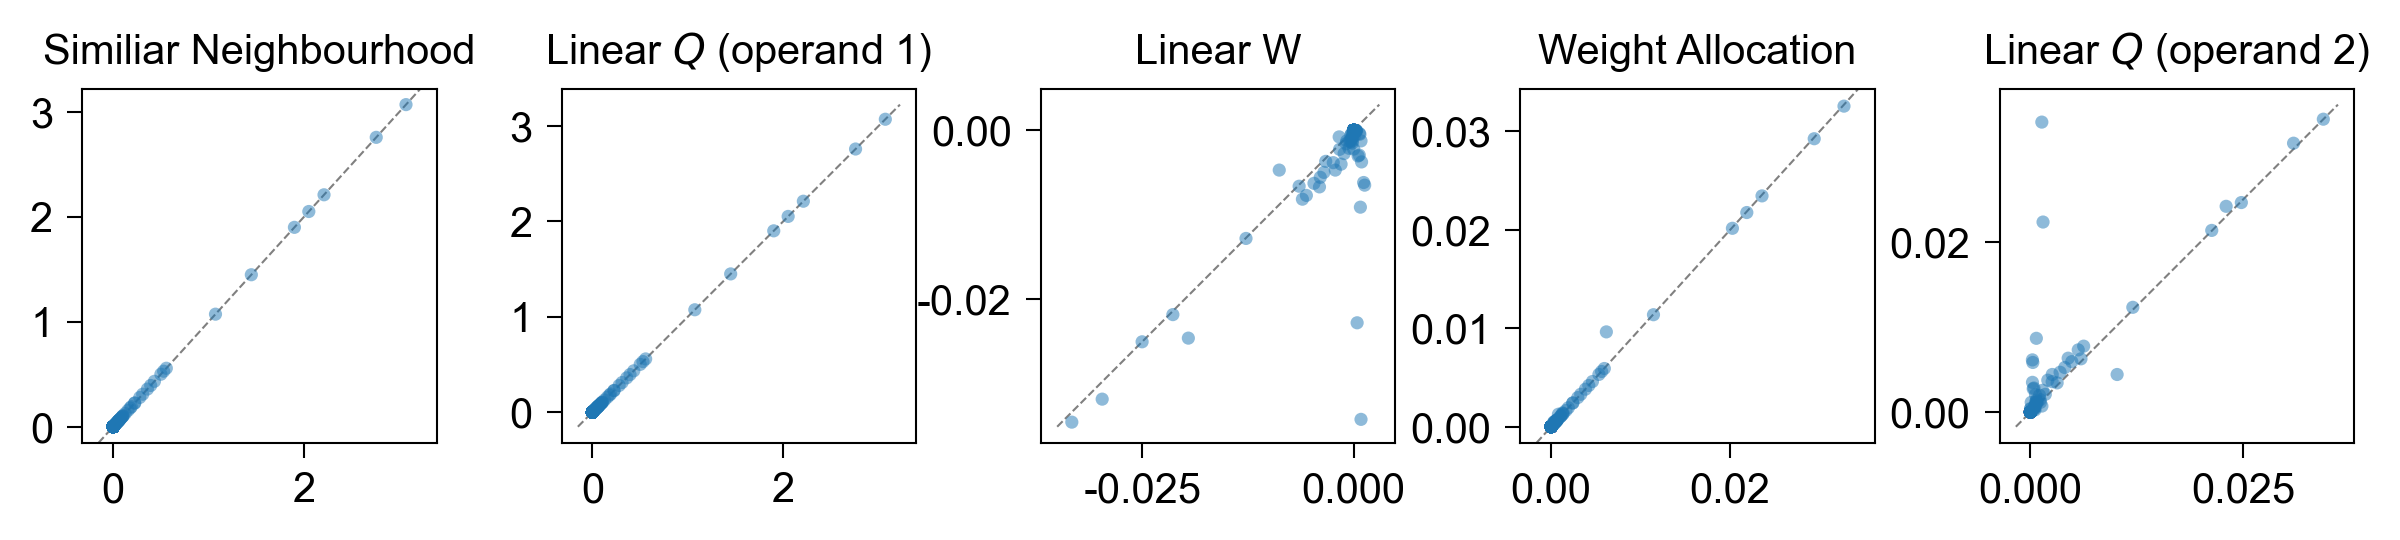

In [21]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

from ND2.utils import get_fig
fi, fig, axes = get_fig(1, 5, AW=3, AH=3, LM=3, RM=3, TM=3, BM=3, FW=18, fontsize=10, lw=0.5)

X, Y, x7, x14, f, data, evaluate = prepare_data('CN')

# 要检查的动力学方程
eq = 0.31 * x7 - 1 * x14 * x7 - 2.28 * x7 ** 3 + 3.07 * Aggr(f * Targ(x7 ** 3))
F = 0.31 * x7 - 1 * x14 * x7 - 2.28 * x7 ** 3
A = f
G = 3.07 * Sour(1) * Targ(x7 ** 3)
# Current we have eq = F + Aggr(A * G)

A2 = np.ones_like(X['A'])
G2 = np.stack(np.nonzero(A2), axis=-1)
s_out = Number((Rgga(A) / Readout(Rgga(A))).eval(**X), nettype='node')
a = (Aggr(A*G) / Aggr(A)).eval(**X) # a_i = sum_j A_ji G(xi, xj) / sum_j A_ji
b = Aggr(Sour(s_out) * G).eval(**{**X, 'A': A2, 'G': G2}) # Readout(Aggr(A)) = Read(Rgga(A)), Readout(Aggr(A*Sour(x7))) ~ Readout(Rgga(A)*x7)
axes[0].scatter(a, b+0*a, s=10, alpha=0.5, ec=None)
axes[0].set_title('Similiar Neighbourhood')
axes[0].set_ylim(*axes[0].get_xlim())

b = b # b_i = sum_j s_out_j G(xi, xj)
c = (3.07 * 1 * x7 ** 3).eval(**X) + 0*b # c_i = G(xj=x_eff, xi)  # 需要根据 G 修改！！！
axes[1].scatter(b, c, s=10, alpha=0.5, ec=None)
axes[1].set_title('Linear $Q$ (operand 1)')

x7_eff = Readout(s_out * x7) # x7_eff = sum_j s_out_j xj
x14_eff = 2 * x7_eff * X['x7_max'] / X['x14_max']
# x14_eff = Readout(s_out * x14) * X['x14_max'] / X['x7_max']
d = Readout(s_out * F).eval(**X)
e = (-F**3 / 1.11635819e-06).eval(**{**X, 'x7': x7_eff.eval(**X), 'x14': x14_eff.eval(**X)})
axes[2].scatter(d, e, s=10, alpha=0.5, ec=None)
axes[2].set_title('Linear W')

h = Readout(s_out * Aggr(A) * c).eval(**X)
k = (Readout(s_out * Aggr(A)) * Readout(s_out * c) / 4.24870286).eval(**X)
axes[3].scatter(h, k, s=10, alpha=0.5, ec=None)
axes[3].set_title(r'Weight Allocation')
axes[3].set_ylim(*axes[3].get_xlim())

l = Readout(s_out * c).eval(**X)
m = (3.07 * 1 * x7_eff ** 3 / 1.29388340e-04).eval(**X)# c_i = G(xj=x_eff, xi)  # 需要根据 G 修改！！！
axes[4].scatter(l, m, s=10, alpha=0.5, ec=None)
axes[4].set_title('Linear $Q$ (operand 2)')

for ax in axes:
    ax.plot(ax.get_xlim(), ax.get_xlim(), '--', zorder=-1, color='gray')

fig.savefig('CN.pdf', transparent=True)
plt.show()

In [7]:
np.polyfit(d.reshape(-1), e.reshape(-1), 1)

array([ 9.99999997e-01, -8.69868328e-04])

```python
eq = F + Aggr(A * G), 
= F + Aggr(A) * Aggr(A * G) / Aggr(A)  
~ F + Aggr(A) * Aggr(Sour(s_out) * G; A2, G2)  (As a~b)
~ F + Aggr(A) * (1 * Pow3(x7))                 (As b~c)

let x7_eff = Readout(s_out * x7), beta_eff = Readout(s_out * Aggr(A)), x14_eff = 2*x7_max/x14_max*x7_eff

d(x7_eff)/dt = Readout(s_out * eq)
= Readout(s_out * F) + Readout(s_out * Aggr(A) * (1 * Pow3(x7)))
~ -F(x7=x7_eff, x14=x14_eff)**3 / 1.11635819e-06 + Readout(s_out * Aggr(A) * (1 * Pow3(x7)))                     (As d~e)
~ -F(x7=x7_eff, x14=x14_eff)**3 / 1.11635819e-06 + beta_eff * Readout(s_out * (1 * Pow3(x7))) / 4.24870286       (As h~k)
~ -F(x7=x7_eff, x14=x14_eff)**3 / 1.11635819e-06 + beta_eff * (1 * Pow3(x7_eff)) / 1.29388e-4 / 4.24870286       (As l~m)
```

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


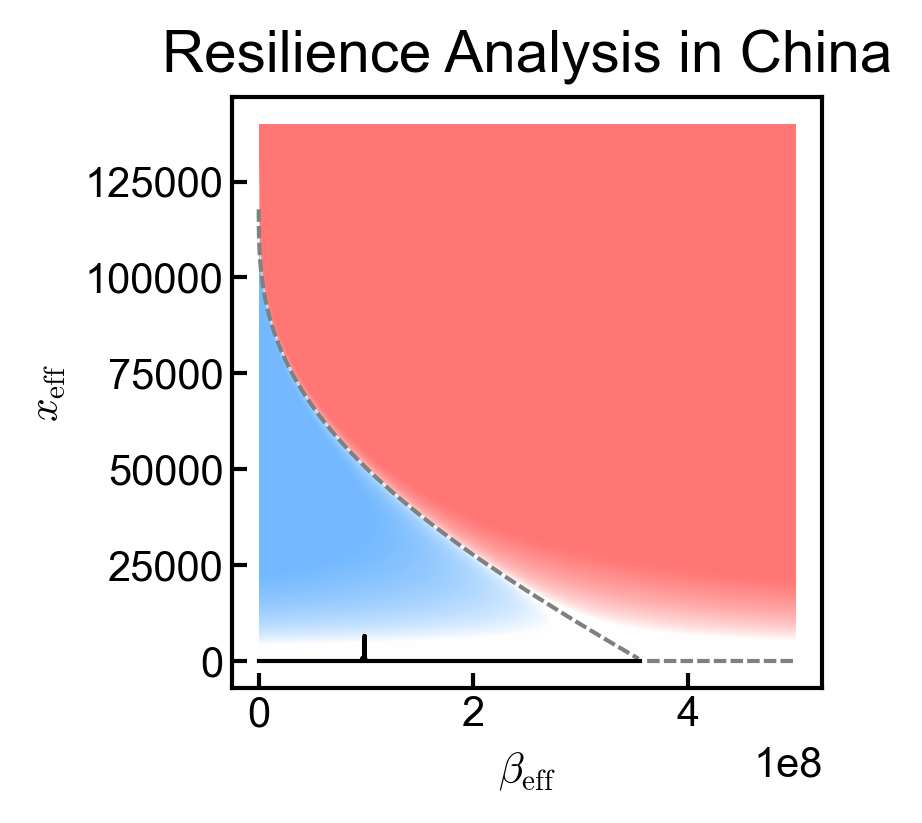

In [54]:
from ND2.utils import get_fig, plot_resilience
import matplotlib.colors as mcolors

def foo(beta_eff, x_eff):
    x_eff = x_eff / X['x7_max']
    beta_eff = beta_eff / X['f_max']
    x7 = Number(x_eff)
    x14 = Number(2 * x_eff * X['x7_max'] / X['x14_max'])
    beta = Number(beta_eff)

    eq = 0.31 * x7 - 1 * x14 * x7 - 2.28 * x7 ** 3 + 3.07 * Aggr(f * Targ(x7 ** 3))
    F = 0.31 * x7 - 1 * x14 * x7 - 2.28 * x7 ** 3
    A = 3.07 * f
    G = Sour(1) * Targ(Pow3(x7))
    # Current we have eq = F + Aggr(A * G)

    dxdt = -F**3 / 1.11635819e-06 + beta * (1 * Pow3(x7)) / 1.29388e-4 / 4.24870286
    dxdt = dxdt.eval()
    return dxdt

fi, fig, axes = get_fig(1, 1, AW=5, AH=5, lw=1, fontsize=10)
plot_resilience(foo, extent=(0, 5e8, 0, 140000), ax=axes[0], reset_xylim=True)
axes[0].plot([0, 14.6*X['f_max']], [0, 0], 'k-', lw=1)


axes[0].set_xlabel(rf'$\beta_\mathrm{{eff}}$')
axes[0].set_ylabel(rf'$x_\mathrm{{eff}}$')
axes[0].tick_params(axis='both', which='major', labelsize=fi.fontsize, direction='in', pad=2)

s_in = Aggr(f)
s_out = Rgga(f) / Readout(Rgga(f))
beta_eff = Readout(s_out*s_in).eval(**X).squeeze(-1) * X['f_max']
x_eff = Readout(s_out*x7).eval(**X).squeeze(-1) * X['x7_max']
axes[0].plot(beta_eff[0], x_eff[0], 'k-o', markevery=12, markersize=0.51, mfc=None, mec='k')
axes[0].plot(beta_eff + 0*x_eff + np.linspace(-0.05*X['f_max'], 0.05*X['f_max'], len(beta_eff)), x_eff, 'k-', ms=1)

axes[0].set_title('Resilience Analysis in China', fontsize=1.4*fi.fontsize)
fig.savefig(f'{PLOT_DIR}/resilience_{name}.pdf', transparent=True)
fig.savefig(f'{PLOT_DIR}/resilience_{name}.png', transparent=False)
fig.savefig(f'{PLOT_DIR}/resilience_{name}.svg', transparent=True)

In [28]:
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(Aggr(f)*x7)                                                                                   )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(x7*Sqrt(Aggr(f)))                                                                          )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(x7*(Aggr(f)**x14))                                                                             )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(((Aggr(f)**x14)**Number(2, fitable=False))*x7)                                                                        )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(((Aggr(f)**(x14**Number(2, fitable=False)))**Number(2, fitable=False))*x7)                                                                   )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(((Aggr(f)**(1.0+x14))**Number(2, fitable=False))*x7)                                                                  )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*Tanh(((x7**Number(2, fitable=False))*Aggr(Targ((1/(eps+Aggr(Targ(x14))))))))                                )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*Tanh(((x7**Number(2, fitable=False))*((1/(x14+eps))-(1.0-Aggr(f)))))                                                         )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*Tanh(((x7**Number(2, fitable=False))*((1/(x14+eps))-(1.0+(1/Aggr(f))))))                                                     )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*Tanh(((x7**Number(2, fitable=False))*((1/(x14+eps))-(1.0-Aggr((f-1.0))))))                                                   )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*Tanh(((x7**Number(2, fitable=False))*(Aggr(f)-(((x14**3)+1.0)/((1.0-x14)**3)))))                                        )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*Tanh(((x7**Number(2, fitable=False))*((1/(x14+eps))-(1.0-Aggr((1.0+(f-((-f)**Number(2, fitable=False)))))))))                                      )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*Tanh(((x7**Number(2, fitable=False))*Aggr((f/Targ((1.0*(Sigmoid((1.0*Aggr(Targ((x14**3)))))**3))))))))
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*Tanh(((x7**Number(2, fitable=False))*Aggr((f/Targ(((1.0+Regular((1.0-x14), (Aggr(f)+1.0)))**3))))))       )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*Tanh(((x7**Number(2, fitable=False))*Aggr((f/Targ(((1.0+Sigmoid((x14*(((1/4)/(eps+x14**3))*1.0))))**3))))))           )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*x7                                                                                                                 )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*Sqrt((x7**Number(2, fitable=False)))                                                                                                   )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(1.0*(x7*(1/4)))                                                                                                   )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*((Aggr(f)**x14)*x7)                                                                                          )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(((Aggr(f)**x14)**Number(2, fitable=False))*x7)                                                                                     )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(((Aggr(f)**(x14**Number(2, fitable=False)))**3)*x7)                                                                                )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*((((Aggr(f)**x14)*1.0)**Number(2, fitable=False))*x7)                                                                               )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(((Regular((Aggr(f)**Number(2, fitable=False)), x14)*1.0)**Number(2, fitable=False))*x7)                                                                   )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*((((Aggr(f)**x14)**3)*x7)+(x7-x14))                                                                           )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(((x7**Number(2, fitable=False))*(Aggr(f)-1.0))+(x7-(x14-x7)))                                                                      )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(Sigmoid(Aggr(f))*(x7*((1.0-(1.0/((1/5)-x14)))**Number(2, fitable=False))))                                                         )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(Sigmoid(Aggr(f))*(x7*((1.0-(1.0/(eps+Log((1.0-Aggr(Targ(x14)))))))**Number(2, fitable=False))))                           )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(Sigmoid(Aggr(f))*(x7*((1.0-(1.0/(eps+1.0-(1.0+Aggr(Targ(x14))))))**Number(2, fitable=False))))                             )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(Sigmoid(Aggr(f))*(x7*((1.0-(1.0/(1.0+(Aggr(Targ((1.0*x14)))**3))))**Number(2, fitable=False))))                        )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(Sigmoid(Aggr(f))*(x7*((1.0-(1.0/((1.0-Aggr(f))+(((x14*5)**3)**3))))**Number(2, fitable=False))))                            )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(Sigmoid(Aggr(f))*(x7*((1.0-(1.0/(1.0-((1.0*(Aggr((1.0*f))*((x14*4)**3)))**3))))**Number(2, fitable=False))))                )
# evaluate(0.0 + 1.0*x7 + 0.0*x14 + 0.0*(Sigmoid(Aggr(f))*(x7*((1.0-(x7/(1.0-((1.0*(((1.0/Aggr((f*1.0)))+(((x14*5)**Number(2, fitable=False))*x14))**3))**3))))**Number(2, fitable=False)))) )

## US

In [55]:
name = 'US'
X, Y, x7, x14, f, data, evaluate = prepare_data(name)

# 平凡 Baseline
evaluate(x7)
evaluate(x14)
evaluate(Number(0.0), 10000)
evaluate(1.0 * x7, 10000)
evaluate(1.0 * x7 + 0.0 * x14, 10000)
C = Number(np.ones_like(Y[0]), nettype='node')
evaluate(C)
C1 = Number(np.ones_like(Y[0]), nettype='node')  
C2 = Number(np.zeros_like(Y[0]), nettype='node')
evaluate(C1 * x7 + C2 * x14, 10000)

eq = 0.62*x7*(1.9 + x7)/(0.81 + 0.65*x14) - 0.49*x14 + 0.035*Aggr(f*Sour(x7))
evaluate(eq)

pred = eq.eval(**X)
baseline = x7.eval(**X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".3g"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(Y, pred):.4f} ({r2_score(Y, pred)/r2_score(Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(Y, pred):.4f} ({rmse_score(Y, pred)/rmse_score(Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(Y, pred):.4f} ({mae_score(Y, pred)/mae_score(Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(Y, pred):.2%} ({smape_score(Y, pred)/smape_score(Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(Y, pred):.1%} ({mape_score(Y, pred)/mape_score(Y, baseline)-1:+.1%})')

[US] R2=0.8184, RMSE=0.0150, MAE=0.0041, SMAPE=28.66%, MAPE=11158.8% 	 x7
[US] R2=0.6988, RMSE=0.0193, MAE=0.0052, SMAPE=34.19%, MAPE=7114.0% 	 x14
[US] R2=-0.0000, RMSE=0.0351, MAE=0.0153, SMAPE=107.76%, MAPE=51009.8% 	 0.01
[US] R2=0.8254, RMSE=0.0147, MAE=0.0040, SMAPE=29.51%, MAPE=10292.8% 	 0.92 * x7
[US] R2=0.8445, RMSE=0.0139, MAE=0.0038, SMAPE=30.13%, MAPE=13039.8% 	 1.56 * x7 + -0.62 * x14
[US] R2=0.2163, RMSE=0.0311, MAE=0.0114, SMAPE=81.45%, MAPE=50608.4% 	 <0.01 (+0.02)>
[US] R2=0.8555, RMSE=0.0134, MAE=0.0039, SMAPE=29.95%, MAPE=8245.4% 	 <1.00 (+0.18)> * x7 + <-0.07 (+0.17)> * x14
[US] R2=0.8595, RMSE=0.0132, MAE=0.0037, SMAPE=29.19%, MAPE=13945.6% 	 0.62 * x7 * (1.90 + x7) / (0.81 + 0.65 * x14) - 0.49 * x14 + 0.04 * Aggr(f * Sour(x7))


<IPython.core.display.Latex object>

Eq: 0.623 * x7 * (1.9 + x7) / (0.808 + 0.65 * x14) - 0.489 * x14 + 0.0373 * Aggr(f * Sour(x7))
Latex: \frac{0.6x_{7}\left(1.9 + x_{7}\right)}{0.8 + 0.6x_{14}} - 0.5x_{14} + 0.0 \times \rho(f \times \phi_s(x_{7}))
R2: 0.8595 (+5.0%)
RMSE: 0.0132 (-12.0%)
MAE: 0.0037 (-8.1%)
SMAPE: 29.19% (+1.9%)
MAPE: 13945.6% (+25.0%)


### G_ij 分析

In [80]:
dxdt = (eq * Number(X['y_max'] / X['x7_max'], fitable=False) - x7).copy()

N = X['A'].shape[0]
x_stable = Number(np.random.rand(N), 'node')
x_stable = Number(np.array([0.049012179537952325,-0.10470315068307287,0.122027308002916,0.04525056389926269,0.25495379382649186,0.1446413578208417,0.045508822908486166,0.0430378993114472,0.09236217969807474,0.2692504194618039,0.12126481173092395,0.0779688591881774,-0.10453958101973174,0.16020079316794195,0.06096228103687735,0.05183684151318275,0.046098198356941414,-0.03417013728288306,0.06711583205284735,-0.09672296843779382,0.0761948128650545,0.10236687857720068,0.11104420793532133,0.09753534415925455,0.03108493917038605,0.10484482209716348,0.00785879366719518,0.03662587822861077,0.13263286010791717,0.04131125105771091,0.018839682206982084,0.05423396294467323,0.23065760742565714,0.12332727152162204,0.03229475958940213,0.12099741511046443,-0.07219102608748354,0.09436083244565656,0.112651835218205,0.04177914480050488,0.05619899439010261,0.03240584852395363,0.10274542321914495,0.21360532304563354,0.07500665231910088,0.04476059286920568,0.054492593078704805,0.13054667213069418,-0.10140504899620191,0.056925219644466334,0.03533912099058466]), 'node')
tmp = dxdt.copy()
for item in tmp.preorder():
    if isinstance(item, Number):
        item.fitable = False
    if isinstance(item, Variable):
        if item.name == 'x7':
            item.replace(x_stable)
        if item.name == 'x14':
            item.replace(x_stable)
print(tmp.to_str(number_format='.2f'))

X_tmp = deepcopy(X)
X_tmp['f'] = X_tmp['f'][-1]
def loss(params):
    x_stable.value = params
    return np.mean((tmp.eval(**X_tmp)) ** 2)
res = minimize(loss, x_stable.value, method='BFGS', options={'maxiter': 10000})
res

(Constant(0.62) * <0.07 (+0.08)> * (Constant(1.90) + <0.07 (+0.08)>) / (Constant(0.81) + Constant(0.65) * <0.07 (+0.08)>) - Constant(0.49) * <0.07 (+0.08)> + Constant(0.04) * Aggr(f * Sour(<0.07 (+0.08)>))) * Constant(1.00) - <0.07 (+0.08)>


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.0807673064803137e-06
        x: [ 4.901e-02 -1.047e-01 ...  5.693e-02  3.534e-02]
      nit: 0
      jac: [ 2.470e-06 -4.608e-06 ...  1.890e-08  2.362e-06]
 hess_inv: [[1 0 ... 0 0]
            [0 1 ... 0 0]
            ...
            [0 0 ... 1 0]
            [0 0 ... 0 1]]
     nfev: 52
     njev: 1

In [119]:
dxdt.eval(**{**X_tmp, 'x7': res.x, 'x14': res.x})

array([-1.00168478e-03, -1.56506337e-03,  2.48949820e-04, -1.04527461e-03,
       -1.28424006e-03,  5.12132098e-05, -4.74893029e-04, -1.77592697e-03,
        1.02875498e-03,  7.42056568e-05,  1.91403995e-03,  2.63411105e-04,
       -1.25540217e-03,  1.06025163e-03,  1.03239320e-04, -1.38075582e-03,
       -1.64552966e-03,  1.62384710e-03,  3.14716071e-04, -1.25598576e-03,
        9.38688712e-04,  1.26365547e-03, -6.91730057e-04, -3.76464733e-04,
       -9.03225204e-04, -6.47040178e-04,  7.90521109e-04, -3.06691189e-04,
        1.60720203e-03, -1.40782857e-03, -1.06185156e-04, -1.29531733e-03,
       -7.04860275e-04, -9.70237609e-04, -7.93002737e-04, -8.12552322e-04,
        1.22692791e-03, -9.75514464e-04,  1.30160542e-03, -8.86108287e-04,
       -4.68373682e-05, -8.78776424e-04, -5.54403261e-04,  8.68316744e-06,
       -8.35792995e-05, -1.71015843e-03,  8.01866611e-06, -9.53767352e-04,
       -1.94628266e-03,  4.15087736e-06, -1.16807377e-03])

In [120]:
print(','.join(map(str, x_stable.value.tolist())))

0.049012179537952325,-0.10470315068307287,0.122027308002916,0.04525056389926269,0.25495379382649186,0.1446413578208417,0.045508822908486166,0.0430378993114472,0.09236217969807474,0.2692504194618039,0.12126481173092395,0.0779688591881774,-0.10453958101973174,0.16020079316794195,0.06096228103687735,0.05183684151318275,0.046098198356941414,-0.03417013728288306,0.06711583205284735,-0.09672296843779382,0.0761948128650545,0.10236687857720068,0.11104420793532133,0.09753534415925455,0.03108493917038605,0.10484482209716348,0.00785879366719518,0.03662587822861077,0.13263286010791717,0.04131125105771091,0.018839682206982084,0.05423396294467323,0.23065760742565714,0.12332727152162204,0.03229475958940213,0.12099741511046443,-0.07219102608748354,0.09436083244565656,0.112651835218205,0.04177914480050488,0.05619899439010261,0.03240584852395363,0.10274542321914495,0.21360532304563354,0.07500665231910088,0.04476059286920568,0.054492593078704805,0.13054667213069418,-0.10140504899620191,0.0569252196444663

100%|██████████| 51/51 [00:01<00:00, 44.88it/s]


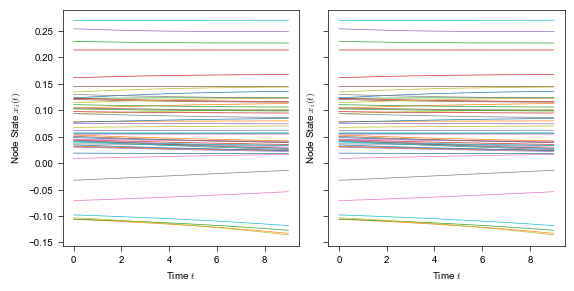

In [81]:
from copy import deepcopy

X0 = deepcopy(X)
X0['x7'] = deepcopy(x_stable.value)
X0['x14'] = deepcopy(x_stable.value)
X0['f'] = X0['f'][-1]

traj = []
X_cur = deepcopy(X0)
for _ in range(10):
    # y = eq.eval(**X_cur)
    # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
    # X_cur['x7'] = y * X['y_max'] / X['x7_max']
    dx = dxdt.eval(**X_cur)
    X_cur['x7'] = X_cur['x7'] + dx
    X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
    traj.append(X_cur['x7'])
X_baseline = traj[-1]

from ND2.utils import get_fig
fi, fig, axes = get_fig(1, 2, AW=6, AH=6, dpi=100, sharey=True)
axes[0].plot(traj)
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('Node State $x_i(t)$')

from tqdm import tqdm
G = []
p = 1e-4
for j in tqdm(range(N)):
    X00 = deepcopy(X0)
    X00['x7'][j] += p
    X00['x14'][j] += p / 2

    traj = []
    X_cur = X00.copy()
    for _ in range(10):
        # y = eq.eval(**X_cur)
        # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
        # X_cur['x7'] = y * X['y_max'] / X['x7_max']
        dx = dxdt.eval(**X_cur)
        X_cur['x7'] = X_cur['x7'] + dx
        X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
        # X_cur['x7'][j] = X00['x7'][j]
        # X_cur['x14'][j] = X00['x14'][j]
        traj.append(X_cur['x7'])
    dxi = (traj[-1] - X_baseline)
    dxj = p
    G.append(dxi / x_stable.value / dxj * x_stable.value[j])

    if j == 3:
        axes[1].plot(traj)
        axes[1].set_xlabel('Time $t$')
        axes[1].set_ylabel('Node State $x_i(t)$')

G_dict[name] = np.stack(G, axis=1)

[-0.8384045  -1.50408636]


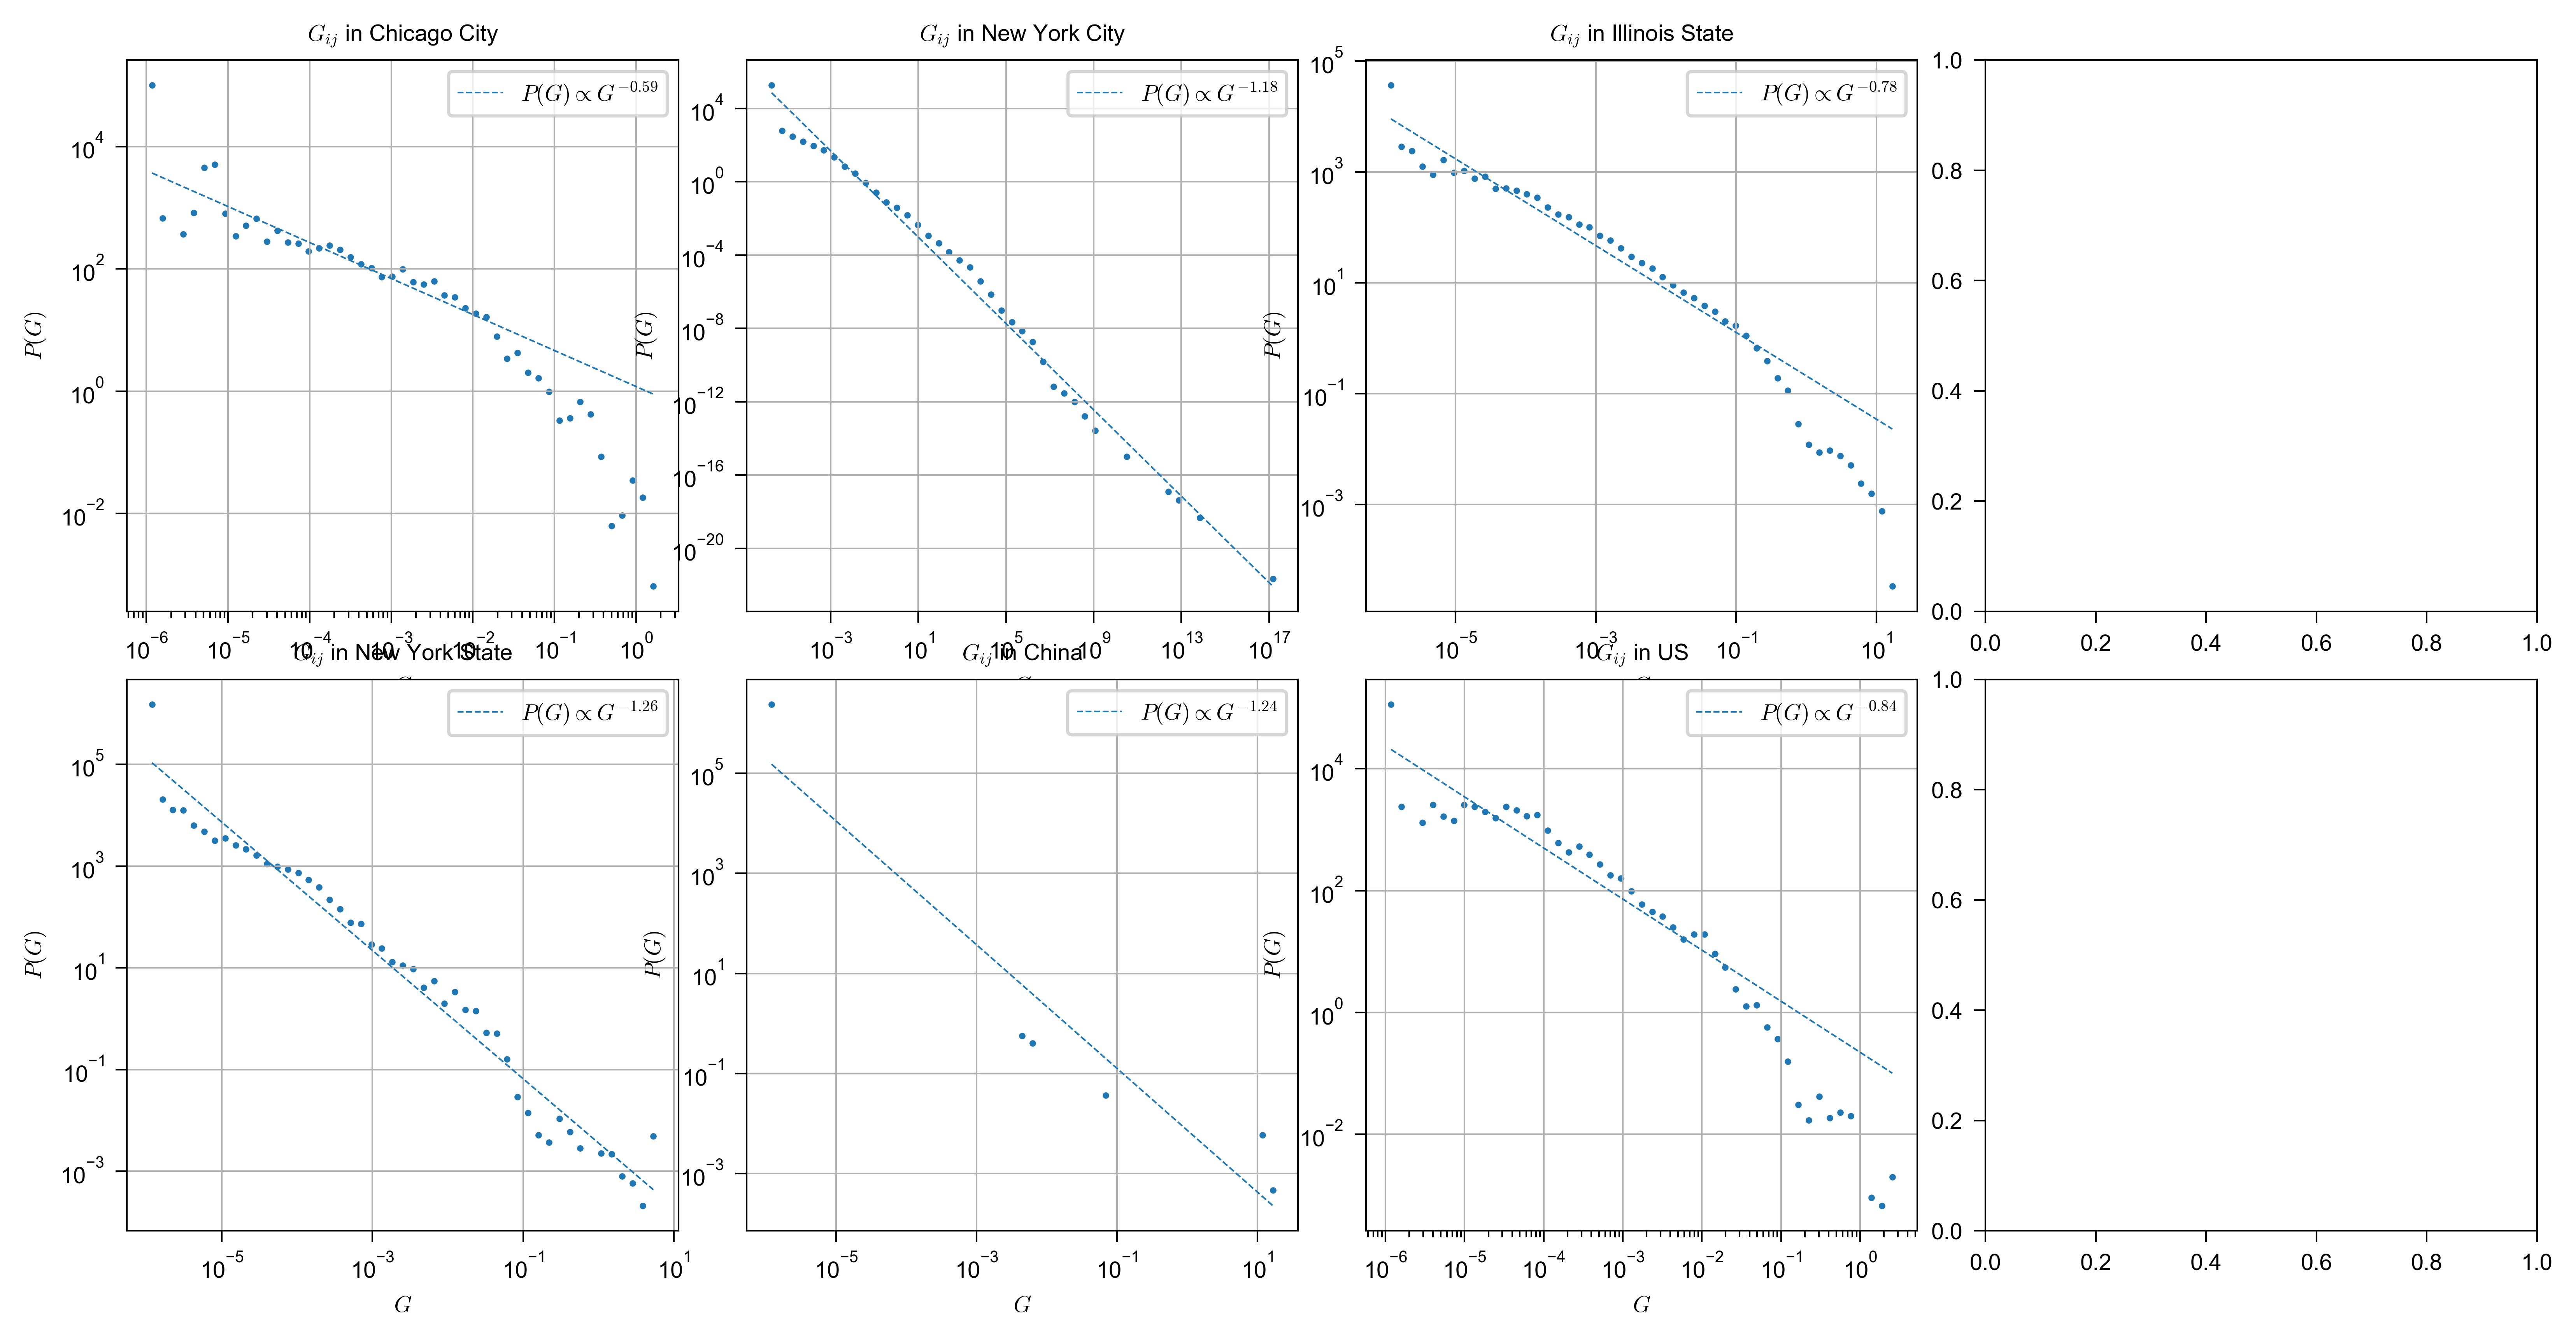

In [82]:
import numpy as np

# 示例数据，假设 x 是一个包含浮点数的 ndarray
# x = np.random.power(0.1, 10000)  # 示例数据，可以替换为你的数据
x = np.abs(G_dict[name]).clip(1e-6, None)
x = x[~np.isnan(x)]
# x = np.random.normal(0, 1, 10000)
# x = np.abs(x) + 1e-6

# 设置直方图的边界
M = 50
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), M)

# 计算直方图
hist, bin_edges = np.histogram(x, bins=bins)
freq = hist / np.diff(bin_edges) / len(x)

# 计算每个 bin 的中心
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# 过滤掉频率为零的 bin
nonzero = freq > 0
bin_centers = bin_centers[nonzero]
freq = freq[nonzero]

# 使用对数坐标绘图
ax = axes_G[6]
ax.clear()
ax.scatter(bin_centers, freq, s=1)

# polyfit
a = np.polyfit(np.log(bin_centers[:37]), np.log(freq[:37]), 1)
print(a)
plot_x = np.logspace(np.log10(np.min(bin_centers)), np.log10(np.max(bin_centers)), 100)
plot_y = np.exp(np.polyval(a, np.log(plot_x)))
ax.plot(plot_x, plot_y, '--', color='C0', label=f'$P(G) \propto G^{{{a[0]:.2f}}}$')


ax.set_title('$G_{ij}$ in US')
ax.set_xlabel('$G$')
ax.set_ylabel('$P(G)$')
ax.legend()
ax.loglog()
ax.grid()

display(fig_G)

### Resilience 分析

In [20]:
from ND2.env import simplify
eq = simplify(eq * X['y_max'] / X['x7_max'] - x7)
pred = eq.eval(**X)
print('Eq:', eq.to_str(number_format=".3g"))

Failed to simplify (0.6227372063933536 * x7 * (1.9007134999862174 + x7) / (0.8083012613547145 + 0.6495053245319623 * x14) - 0.4887257216742028 * x14 + 0.03725783712243977 * Aggr(f * Sour(x7))) * 862256.0 / 862256.0 - x7: 'Aggr'


Eq: (0.623 * x7 * (1.9 + x7) / (0.808 + 0.65 * x14) - 0.489 * x14 + 0.0373 * Aggr(f * Sour(x7))) * 8.62e+05 / 8.62e+05 - x7


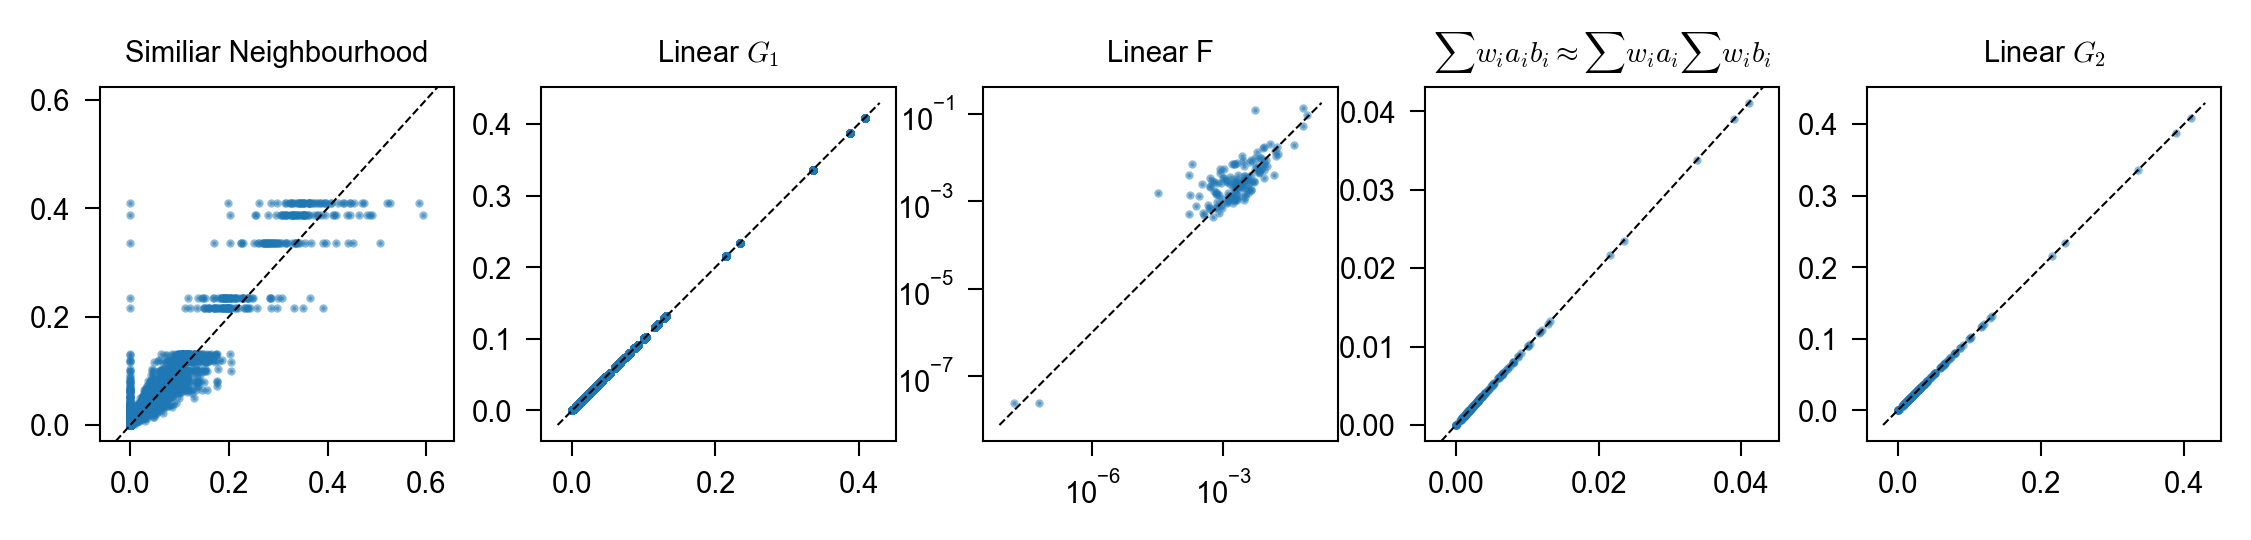

In [56]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

from ND2.utils import get_fig
fi, fig, axes = get_fig(1, 5, AW=3, AH=3)

X, Y, x7, x14, f, data, evaluate = prepare_data(name)

# 要检查的动力学方程
eq = 0.623 * x7 * (1.9 + x7) / (0.808 + 0.65 * x14) - 0.489 * x14 - x7 + 0.0373 * Aggr(f * Sour(x7))
F = 0.623 * x7 * (1.9 + x7) / (0.808 + 0.65 * x14) - 0.489 * x14 - x7
A = 0.0373 * f
G = Sour(x7) * Targ(1)
# eq = F + Aggr(A * G)

A2 = np.ones_like(X['A'])
G2 = np.stack(np.nonzero(A2), axis=-1)
s_out = Number((Rgga(A) / Readout(Rgga(A))).eval(**X), nettype='node')
a = (Aggr(A*G) / (eps+Aggr(A))).eval(**X) # a_i = sum_j A_ji G(xi, xj) / sum_j A_ji
b = (Aggr(Sour(s_out) * G) / 0.80041403).eval(**{**X, 'A': A2, 'G': G2})+0*a # Readout(Aggr(A)) = Read(Rgga(A)), Readout(Aggr(A*Sour(x7))) ~ Readout(Rgga(A)*x7)
axes[0].scatter(a, b, s=1, alpha=0.5)
axes[0].set_title('Similiar Neighbourhood')
axes[0].set_ylim(*axes[0].get_xlim())

x7_eff = Readout(s_out * x7) # x7_eff = sum_j s_out_j xj
x14_eff = 2 * x7_eff * X['x7_max'] / X['x14_max']
b = b # b_i = sum_j s_out_j G(xi, xj)
c = (x7_eff * 1 / 0.80041403).eval(**X) + 0*b # c_i = G(xj=x_eff, xi)  # 需要根据 G 修改！！！
axes[1].scatter(b, c, s=1, alpha=0.5)
axes[1].set_title('Linear $G_1$')

d = -Readout(s_out * F).eval(**X)
e = (x7_eff**2+0.09*x7_eff).eval(**{**X, 'x7': x7_eff.eval(**X), 'x14': x14_eff.eval(**X)})
axes[2].scatter(d, e, s=1, alpha=0.5)
axes[2].set_title('Linear F')
axes[2].loglog()
# axes[2].set_xlim(0.00, 0.02)
# axes[2].set_ylim(0.00, 0.02)

h = Readout(s_out * Aggr(A) * c).eval(**X)
k = (Readout(s_out * Aggr(A)) * Readout(s_out * c)).eval(**X)
axes[3].scatter(h, k, s=1, alpha=0.5)
axes[3].set_title(r'$\sum w_ia_ib_i\approx\sum w_ia_i\sum w_ib_i$')
axes[3].set_ylim(*axes[3].get_xlim())

l = Readout(s_out * c).eval(**X)
m = (x7_eff * 1 / 0.80041403).eval(**X)  # c_i = G(xj=x_eff, xi)  # 需要根据 G 修改！！！
axes[4].scatter(l, m, s=1, alpha=0.5)
axes[4].set_title('Linear $G_2$')

for ax in axes:
    ax.plot(ax.get_xlim(), ax.get_xlim(), 'k--')
# g = 
# a = Aggr(1) * G
plt.show()

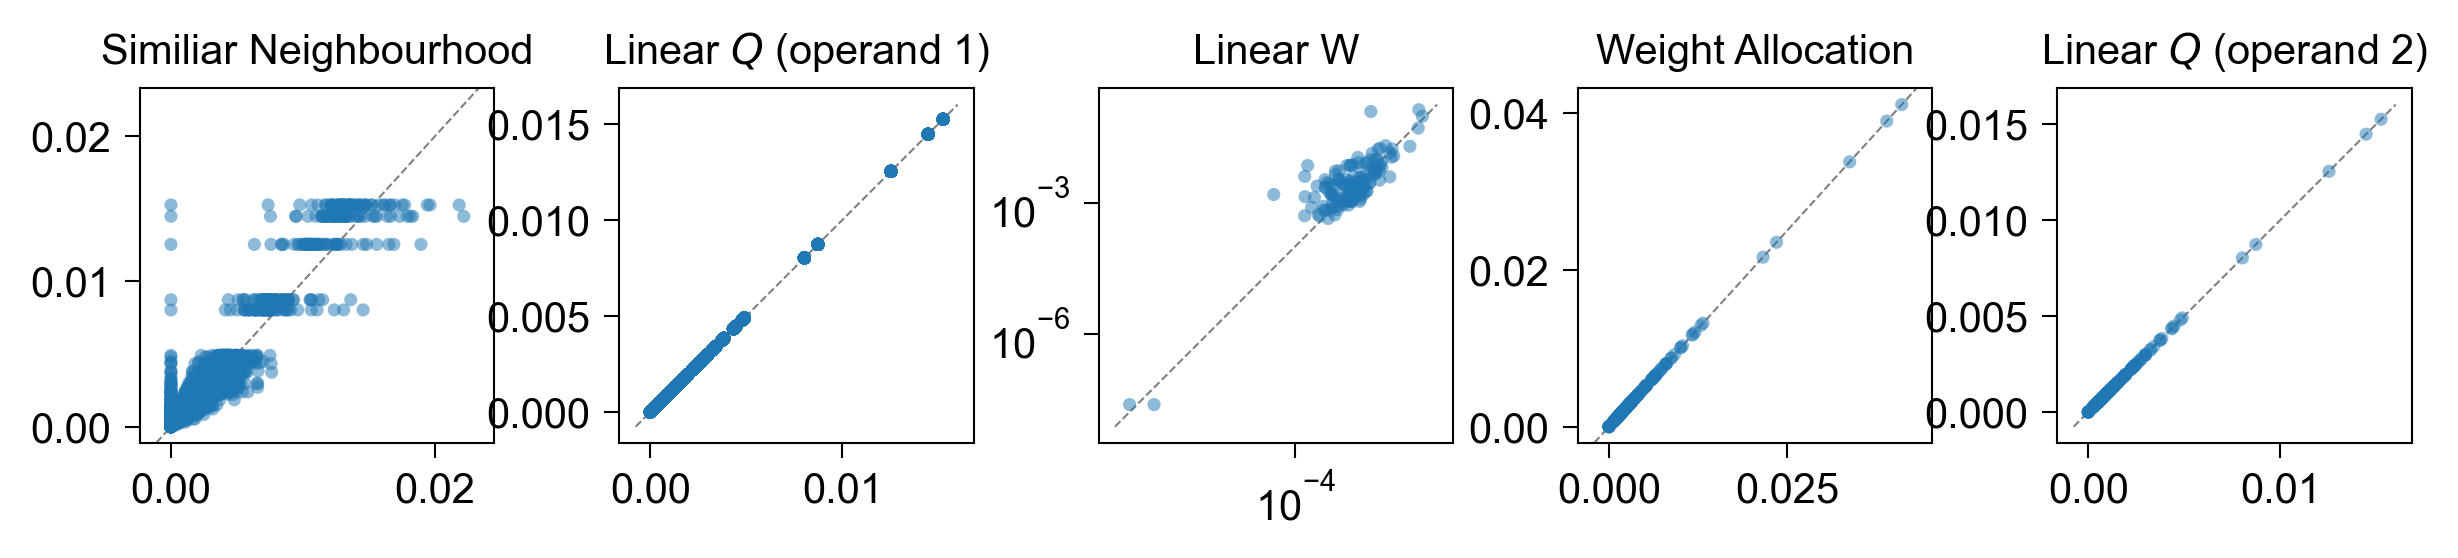

In [29]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

from ND2.utils import get_fig
fi, fig, axes = get_fig(1, 5, AW=3, AH=3, LM=3, RM=3, TM=3, BM=3, FW=18, fontsize=10, lw=0.5)

X, Y, x7, x14, f, data, evaluate = prepare_data('US')

# 要检查的动力学方程
eq = 0.623 * x7 * (1.9 + x7) / (0.808 + 0.65 * x14) - 0.489 * x14 - x7 + 0.0373 * Aggr(f * Sour(x7))
F = 0.623 * x7 * (1.9 + x7) / (0.808 + 0.65 * x14) - 0.489 * x14 - x7
A = f
G = 0.0373 * Sour(x7) * Targ(1)
# eq = F + Aggr(A * G)

A2 = np.ones_like(X['A'])
G2 = np.stack(np.nonzero(A2), axis=-1)
s_out = Number((Rgga(A) / Readout(Rgga(A))).eval(**X), nettype='node')
a = (Aggr(A*G) / (eps+Aggr(A))).eval(**X) # a_i = sum_j A_ji G(xi, xj) / sum_j A_ji
b = (Aggr(Sour(s_out) * G) / 0.80041403).eval(**{**X, 'A': A2, 'G': G2})+0*a # Readout(Aggr(A)) = Read(Rgga(A)), Readout(Aggr(A*Sour(x7))) ~ Readout(Rgga(A)*x7)
axes[0].scatter(a, b, s=10, alpha=0.5, ec=None)
axes[0].set_title('Similiar Neighbourhood')
axes[0].set_ylim(*axes[0].get_xlim())

x7_eff = Readout(s_out * x7) # x7_eff = sum_j s_out_j xj
x14_eff = 2 * x7_eff * X['x7_max'] / X['x14_max']
b = b # b_i = sum_j s_out_j G(xi, xj)
c = (0.0373 * x7_eff * 1 / 0.80041403).eval(**X) + 0*b # c_i = G(xj=x_eff, xi)  # 需要根据 G 修改！！！
axes[1].scatter(b, c, s=10, alpha=0.5, ec=None)
axes[1].set_title('Linear $Q$ (operand 1)')

d = -Readout(s_out * F).eval(**X)
e = (x7_eff**2+0.09*x7_eff).eval(**{**X, 'x7': x7_eff.eval(**X), 'x14': x14_eff.eval(**X)})
axes[2].scatter(d, e, s=10, alpha=0.5, ec=None)
axes[2].set_title('Linear W')
axes[2].loglog()
# axes[2].set_xlim(0.00, 0.02)
# axes[2].set_ylim(0.00, 0.02)

h = Readout(s_out * Aggr(A) * c).eval(**X)
k = (Readout(s_out * Aggr(A)) * Readout(s_out * c)).eval(**X)
axes[3].scatter(h, k, s=10, alpha=0.5, ec=None)
axes[3].set_title(r'Weight Allocation')
axes[3].set_ylim(*axes[3].get_xlim())

l = Readout(s_out * c).eval(**X)
m = (0.0373 * x7_eff * 1 / 0.80041403).eval(**X)  # c_i = G(xj=x_eff, xi)  # 需要根据 G 修改！！！
axes[4].scatter(l, m, s=10, alpha=0.5, ec=None)
axes[4].set_title('Linear $Q$ (operand 2)')

for ax in axes:
    ax.plot(ax.get_xlim(), ax.get_xlim(), '--', zorder=-1, color='gray')
# g = 
# a = Aggr(1) * G
fig.savefig('US.pdf', transparent=True)
plt.show()

In [23]:
np.polyfit(d.reshape(-1), e.reshape(-1), 1)

array([1.12460104, 0.00187402])

```python
eq = F + Aggr(A * G), 
= F + Aggr(A) * Aggr(A * G) / Aggr(A)  
~ F + Aggr(A) * Aggr(Sour(s_out) * G; A2, G2)  (As a~b)
~ F + Aggr(A) * (x7_eff * 1 / 0.80041403)                 (As b~c)

let x7_eff = Readout(s_out * x7), beta_eff = Readout(s_out * Aggr(A)), x14_eff = 2*x7_max/x14_max*x7_eff

d(x7_eff)/dt = Readout(s_out * eq)
= Readout(s_out * F) + Readout(s_out * Aggr(A) * (x7_eff * 1 / 0.80041403))
~ -(x7_eff**2+0.09*x7_eff) + Readout(s_out * Aggr(A) * (x7_eff * 1 / 0.80041403))       (As d~e)
~ -(x7_eff**2+0.09*x7_eff) + beta_eff * Readout(s_out * (x7_eff * 1 / 0.80041403))      (As h~k)
~ -(x7_eff**2+0.09*x7_eff) + beta_eff * (x7_eff * 1 / 0.80041403)                       (As l~m)
```

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


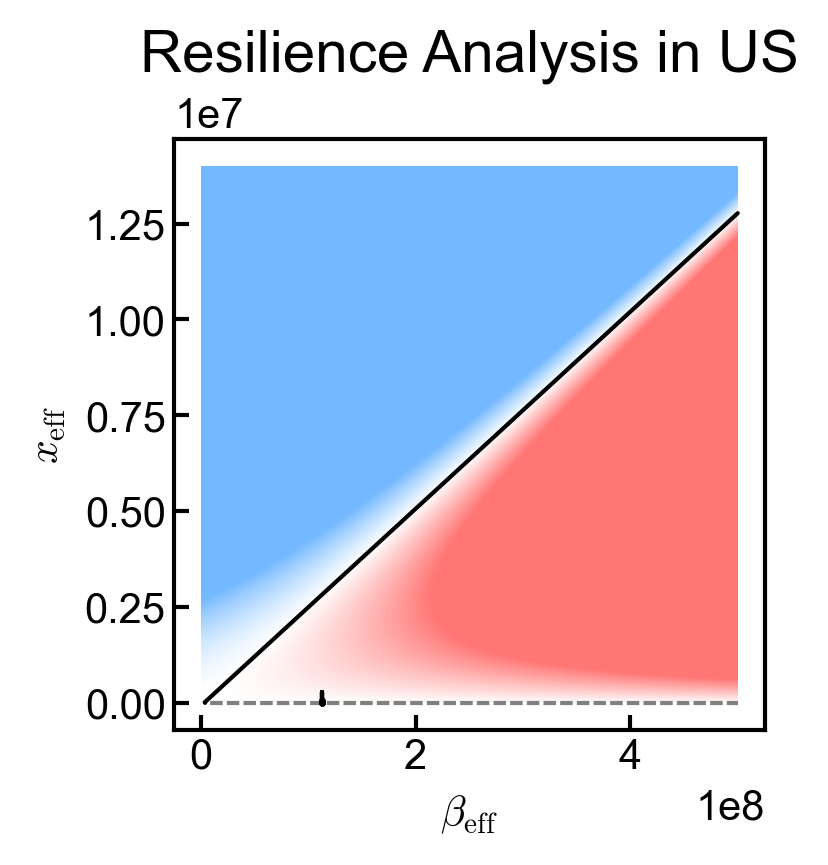

In [58]:
from ND2.utils import get_fig, plot_resilience
import matplotlib.colors as mcolors

def foo(beta_eff, x_eff):
    beta_eff = beta_eff / X['f_max']
    x_eff = x_eff / X['x7_max']
    x7 = Number(x_eff)
    x14 = Number(2 * x_eff * X['x7_max'] / X['x14_max'])
    beta = Number(beta_eff)
    dxdt = -(x7**2 + 0.09*x7) + beta * (x7 * 1 / 0.80041403)
    dxdt = dxdt.eval()
    # dxdt[1, :] = -100
    dxdt[0, :] = 0
    return dxdt

fi, fig, axes = get_fig(1, 1, AW=5, AH=5, lw=1, fontsize=10)
plot_resilience(foo, extent=(0, 5e8, 0, 14000000), ax=axes[0], reset_xylim=True, norm=mcolors.SymLogNorm(linthresh=10, linscale=1e-3, vmin=-10, vmax=10))
axes[0].plot([0, 14.7], [0, 0], 'k-', lw=1)

axes[0].set_xlabel(rf'$\beta_\mathrm{{eff}}$')
axes[0].set_ylabel(rf'$x_\mathrm{{eff}}$')
axes[0].tick_params(axis='both', which='major', labelsize=fi.fontsize, direction='in', pad=2)

s_in = Aggr(f)
s_out = Rgga(f) / Readout(Rgga(f))
beta_eff = Readout(s_out*s_in).eval(**X).squeeze(-1) * X['f_max']
x_eff = Readout(s_out*x7).eval(**X).squeeze(-1) * X['x7_max']
axes[0].plot(beta_eff[:], x_eff[:], 'k-o', markevery=12, markersize=0.51, mfc=None, mec='k')
axes[0].plot(beta_eff + 0*x_eff + np.linspace(-0.05, 0.05, len(beta_eff)), x_eff, 'k-', ms=1)

axes[0].set_title('Resilience Analysis in US', fontsize=1.4*fi.fontsize)
fig.savefig(f'{PLOT_DIR}/resilience_{name}.pdf', transparent=True)
fig.savefig(f'{PLOT_DIR}/resilience_{name}.png', transparent=False)
fig.savefig(f'{PLOT_DIR}/resilience_{name}.svg', transparent=True)

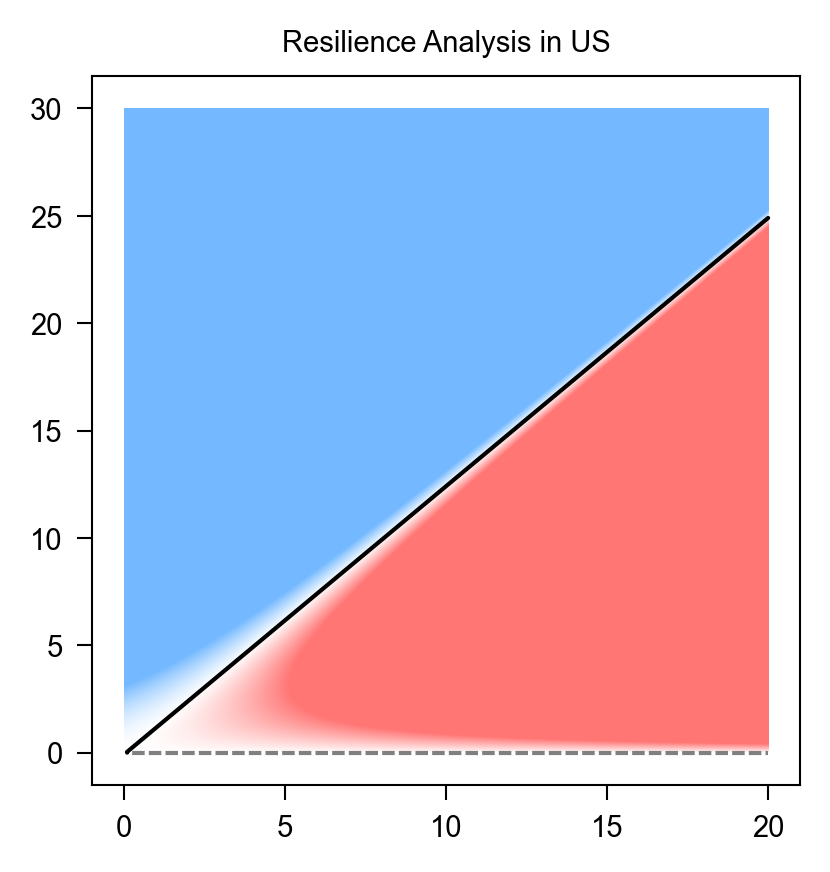

In [9]:
f:callable = foo
extent=(0, 20, 0, 30)
gridnum=(1000, 1000)
cmap=None
norm=mcolors.SymLogNorm(linthresh=10, linscale=1e-3, vmin=-10, vmax=10)
ax=axes[0]
reset_xylim=True
lw=1

ax.clear()

if cmap is None: cmap = mcolors.LinearSegmentedColormap.from_list('my_bwr', ['#74b9ff', 'white', '#ff7675'])
if norm is None: norm = mcolors.SymLogNorm(linthresh=0.01, linscale=0.01, vmin=-1, vmax=1)
if ax is None: ax = plt.gca()

def plot1(x, y):
    ax.plot(x, y, 'black', linewidth=lw, linestyle='-', solid_capstyle='round')

def plot2(x, y):
    ax.plot(x, y, 'gray', linewidth=lw, linestyle=(3, (3, 1)), solid_capstyle='round')

xmin, xmax, ymin, ymax = extent
xnum, ynum = gridnum
x = np.linspace(xmin, xmax, xnum)
y = np.linspace(ymin, ymax, ynum)
x, y = np.meshgrid(x, y)
z = f(x, y)

ax.imshow(z, origin='lower', aspect='auto', cmap=cmap, norm=norm, zorder=0, extent=(xmin, xmax, ymin, ymax))

contours = ax.contour(x, y, z, levels=[0], linewidths=0)
for coll in contours.collections: coll.remove()

dzdy = np.gradient(z)[0]
for coll in contours.collections:
    for path in coll.get_paths():
        saved = []
        sign = None
        for (x0, y0) in path.vertices:
            saved.append((x0, y0))
            x_idx = int(np.floor((x0-xmin) / (xmax-xmin) * (xnum - 1)))
            y_idx = int(np.floor((y0-ymin) / (ymax-ymin) * (ynum - 1)))
            if sign is None: sign = np.sign(dzdy[y_idx, x_idx])
            if np.sign(dzdy[y_idx, x_idx] * sign) < 0:
                if sign < 0: plot1(*np.array(saved).T)
                else: plot2(*np.array(saved).T)
                sign *= -1
                saved = []
            else:
                pass
        if saved:
            if sign < 0: plot1(*np.array(saved).T)
            else: plot2(*np.array(saved).T)

if reset_xylim:
    scale = lambda min, max, ratio=0.1: (min - (max - min) * ratio / 2, max + (max - min) * ratio / 2)
    ax.set_xlim(*scale(xmin, xmax))
    ax.set_ylim(*scale(ymin, ymax))


axes[0].set_title('Resilience Analysis in US')
fig.savefig(f'{PLOT_DIR}/resilience_{name}.pdf', transparent=True)
fig.savefig(f'{PLOT_DIR}/resilience_{name}.png', transparent=False)
fig.savefig(f'{PLOT_DIR}/resilience_{name}.svg', transparent=True)

display(fig)

# World

In [90]:
name = 'World'
X, Y, x7, x14, f, data, evaluate = prepare_data(name)

# 平凡 Baseline
evaluate(x7)
evaluate(x14)
evaluate(Number(0.0), 10000)
evaluate(1.0 * x7, 10000)
evaluate(1.0 * x7 + 0.0 * x14, 10000)
C = Number(np.ones_like(Y[0]), nettype='node')
evaluate(C)
C1 = Number(np.ones_like(Y[0]), nettype='node')  
C2 = Number(np.zeros_like(Y[0]), nettype='node')
evaluate(C1 * x7 + C2 * x14, 10000)

eq = -0.18 + 2.1*x7 + -1.0*x14 + 0.69*Sigmoid(0.012*Aggr(f)) / (1.9+0.93*x14)
evaluate(eq)

pred = eq.eval(**X)
baseline = x7.eval(**X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".2f"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(Y, pred):.4f} ({r2_score(Y, pred)/r2_score(Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(Y, pred):.4f} ({rmse_score(Y, pred)/rmse_score(Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(Y, pred):.4f} ({mae_score(Y, pred)/mae_score(Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(Y, pred):.2%} ({smape_score(Y, pred)/smape_score(Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(Y, pred):.1%} ({mape_score(Y, pred)/mape_score(Y, baseline)-1:+.1%})')

[World] R2=0.9040, RMSE=0.0065, MAE=0.0010, SMAPE=41.66%, MAPE=1120.8% 	 x7
[World] R2=0.8213, RMSE=0.0089, MAE=0.0013, SMAPE=47.48%, MAPE=1107.4% 	 x14
[World] R2=-0.0000, RMSE=0.0209, MAE=0.0061, SMAPE=161.19%, MAPE=89481.2% 	 0.00
[World] R2=0.9063, RMSE=0.0064, MAE=0.0010, SMAPE=41.63%, MAPE=1069.1% 	 0.95 * x7
[World] R2=0.9359, RMSE=0.0053, MAE=0.0008, SMAPE=48.77%, MAPE=1443.1% 	 2.09 * x7 + -1.12 * x14
[World] R2=0.2925, RMSE=0.0176, MAE=0.0038, SMAPE=120.15%, MAPE=16672.2% 	 <0.00 (+0.01)>
[World] R2=0.9061, RMSE=0.0064, MAE=0.0010, SMAPE=41.69%, MAPE=1118.7% 	 <1.00 (+0.00)> * x7 + <-0.00 (+0.00)> * x14
[World] R2=0.9363, RMSE=0.0053, MAE=0.0009, SMAPE=90.45%, MAPE=3427.5% 	 -0.18 + 2.07 * x7 + -1.04 * x14 + 0.69 * sigmoid(0.01 * Aggr(f)) / (1.90 + 0.93 * x14)


<IPython.core.display.Latex object>

Eq: -0.18 + 2.07 * x7 + -1.04 * x14 + 0.69 * sigmoid(0.01 * Aggr(f)) / (1.90 + 0.93 * x14)
Latex: -0.2 + 2.1x_{7} + -1.0x_{14} + \frac{0.7 \times sigmoid(0.0 \times \rho(f))}{1.9 + 0.9x_{14}}
R2: 0.9363 (+3.6%)
RMSE: 0.0053 (-18.5%)
MAE: 0.0009 (-4.2%)
SMAPE: 90.45% (+117.1%)
MAPE: 3427.5% (+205.8%)


### G_ij 分析

In [84]:
dxdt = (eq * Number(X['y_max'] / X['x7_max'], fitable=False) - x7).copy()

N = X['A'].shape[0]
x_stable = Number(np.random.rand(N), 'node')
x_stable = Number(np.array([0.303264860400516,0.3848279795894911,0.2593288440074617,0.4099927509824218,0.585070501449507,0.4397914357966131,0.10841948441767368,0.6904374711130532,0.5674606380890825,0.30890635971589325,0.23585198811563018,0.3297215093781559,0.14016018428289484,0.8881508615866949,0.3983403231825905,0.2517489262483851,0.4585850654539463,0.15356363710554344,0.37226586937944084,0.4746405197644299,0.5090913040279965,0.42540115895123287,0.5567240859599369,0.669481337052088,0.056205239076854235,0.2032265592472,0.23526404924659722,0.20372410529759144,0.24547972889269226,0.20765837336747223,0.6346737143262859,0.47045412595238756,0.01857013919447152,0.9387545230462779,0.23626171383873806,0.4719982426125712,0.17154305611945123,0.423462142271632,0.4484809037664019,0.2983321045799773,0.23986018633804762,0.4765170350919831,0.9185682591189468,0.3169041293079566,0.39788401992370215,0.4147618917492347,0.235713318553043,0.4105631527320216,0.39038177862039164,0.4362464210017202,0.9349053953633468,0.6333322424046928,0.11880955984756117,0.6462901780635691,0.11939768632369649,0.29268198986141913,0.4599915800806469,0.7108436494450483,0.4442098108089363,0.13641942476183438,0.5937131031429967,0.5105016157710006,0.29899807438905845,0.2429420449204115,0.2862597570490102,0.005901044142153398,0.42297731985464293,0.37251457918652997,0.2155200517717787,0.5289801982984288,0.3356609072364771,0.46104802534897527,0.2501576669121157,0.19847111328062478,0.08055380060107022,0.8790880266727916,0.045788413039801995,0.4481268739585283,0.45230380636553813,0.6752029617748887,0.46806604984677125,0.143767443941479,0.6321815249701239,0.31165183076078706,0.06496458962376232,0.2353249551578321,4.691908508105935,0.15810513109662594,0.2234927896875203,0.8124565054726094,0.6322668771364087,0.399349109241045,0.4367135897348111,0.8357176973771278,0.11185551092878251,0.4197516015947329,0.6238234240147761,0.2015121492122754,0.8877297366621291,0.5702583837119417,0.042191302744429275,0.4830645490867119,0.1578715045725447,0.3063833504523139,0.5921799759412563,0.4000139877368137,0.33481081281600955,0.3714088498523788,0.16087316413716765,0.4574752575980254,0.2554909122418272,0.8238548202939519,0.5417406715832251,0.8850862547353835,0.4320638968165782,0.8770149122777251,0.2505706488840644,0.9994297744413438,0.8271081249283454,0.07854410551861049,0.32801670960109996,0.4603668232302338,0.47874950416029327,0.8137687247470562,0.3230589782804584,0.3803069667624855,0.3928352250106403,0.34913661380337724,0.06395563323300407,0.39488083817839414,0.4252366305336872,0.4514251566741483,0.017891074034184756,0.3232212670962971,0.09405368440596754,0.41091552004579746,0.5606466910950433,0.4843916690354028,0.6351836750944742,0.4067882632429286,0.46622524377261076,0.25861931691939183,5.013144788434683,0.6006805335047356,0.4165977050076891,0.4496164343565492,3.6425162168231298,0.20843886403176304,0.21604752445012626,0.0048320241851664315,0.4315072985847268,0.4408452023830881,0.626858420283974,0.5438944402069804,0.027877120410163027,0.3951167747631782,0.8181143317270143,0.4255840207550613,0.47789347362579215,0.6444680319957854,0.48536513775558077,0.06813811392816427,0.09052958783831559,0.4233270099661657,0.1805984484367828,0.19649300041360807,0.3159958381671998,0.3323615454253337,0.5447421728218224,0.5010760661901983,0.21627888927201083,0.3391144808485538,0.18703835728706508,0.4203861636181541,0.8444380297874391,0.16466334577905542,0.16695198267521535,0.5203891138433632,0.17986428394197856,0.6201486372902623,0.7951547531735923,0.49150392510891017,0.10249423161664639,0.20223392333878543,0.8109079461759537,0.5254896294627265,0.03450741676466605,0.440313265302522,0.09533754061910306,0.24620306820021282]), 'node')
tmp = dxdt.copy()
for item in tmp.preorder():
    if isinstance(item, Number):
        item.fitable = False
    if isinstance(item, Variable):
        if item.name == 'x7':
            item.replace(x_stable)
        if item.name == 'x14':
            item.replace(x_stable)
print(tmp.to_str(number_format='.2f'))

X_tmp = deepcopy(X)
X_tmp['f'] = X_tmp['f'][-1]
def loss(params):
    x_stable.value = params
    return np.mean((tmp.eval(**X_tmp)) ** 2)
res = minimize(loss, x_stable.value, options={'maxiter': 10000}, method='Nelder-Mead')
res

(Constant(-0.18) + Constant(2.07) * <0.46 (+0.56)> + Constant(-1.04) * <0.46 (+0.56)> + Constant(0.69) * sigmoid(Constant(0.01) * Aggr(f)) / (Constant(1.90) + Constant(0.93) * <0.46 (+0.56)>)) * Constant(1.00) - <0.46 (+0.56)>


       message: Maximum number of iterations has been exceeded.
       success: False
        status: 2
           fun: 0.0002907404413832239
             x: [ 3.188e-01  4.056e-01 ...  9.596e-02  2.504e-01]
           nit: 10000
          nfev: 10465
 final_simplex: (array([[ 3.188e-01,  4.056e-01, ...,  9.596e-02,
                         2.504e-01],
                       [ 3.197e-01,  4.044e-01, ...,  9.596e-02,
                         2.507e-01],
                       ...,
                       [ 3.182e-01,  4.033e-01, ...,  9.594e-02,
                         2.507e-01],
                       [ 3.191e-01,  4.030e-01, ...,  9.595e-02,
                         2.508e-01]]), array([ 2.907e-04,  2.909e-04, ...,  2.914e-04,  2.914e-04]))

In [129]:
dxdt.eval(**{**X_tmp, 'x7': res.x, 'x14': res.x})

array([-0.01503829, -0.01798617, -0.01279642, -0.01836763, -0.02219563,
       -0.01855115, -0.00636346, -0.02469126, -0.02308553, -0.01521269,
       -0.01215648, -0.01590758, -0.00744994,  0.00403892, -0.01797528,
       -0.01219441, -0.01898788, -0.0079034 , -0.01763021, -0.01925757,
       -0.02046013, -0.01993011, -0.02053851, -0.02511046, -0.00292789,
       -0.01027595, -0.01221153, -0.01050875, -0.01173111, -0.01103198,
       -0.02296349, -0.01895608, -0.00110991, -0.02726804, -0.00921733,
       -0.01857806, -0.00818835, -0.01804873, -0.01859672, -0.01461911,
       -0.01209325, -0.01916909, -0.02690546, -0.01539601, -0.01743638,
       -0.01810763, -0.0115817 , -0.01814006, -0.01803645, -0.01832962,
       -0.02742519, -0.02375295, -0.00647009, -0.02430851, -0.00651509,
       -0.0140552 , -0.01878059, -0.02553373, -0.0190854 , -0.00703994,
       -0.01934798, -0.0199419 , -0.01475903, -0.01252144, -0.01029714,
       -0.00032407, -0.01828048, -0.01748332, -0.01102023, -0.01

In [130]:
print(','.join(map(str, x_stable.value.tolist())))

0.31984687260770084,0.40393806695407697,0.26396361536409185,0.41534000175167696,0.5556725529578177,0.4286268324520931,0.11768788940949013,0.6894485079791879,0.6089137431605729,0.325917280500729,0.24556983602615146,0.34624696133952404,0.14316899788591064,4.092660133078732,0.40369891717153306,0.2621497073991518,0.43519738096756866,0.14867830158988476,0.3917825074350061,0.44558114220344514,0.48650633048254344,0.46306199679706195,0.5081037021721344,0.6724971761803158,0.05665477052437544,0.20009735281623647,0.24581614525681927,0.20626878667454052,0.23754057783208699,0.217403973920834,0.6301041840151385,0.4387382057539472,0.0189613692727187,0.807474496820785,0.2370461217732323,0.44698782866556963,0.16141207531082563,0.40645041965550455,0.42291656001952194,0.3075968714690748,0.2469313481580056,0.442183981772045,0.7905021474435023,0.3345034771068539,0.3936269360436897,0.41410462113622126,0.24662192727809884,0.40723170296000943,0.40331178730799566,0.4249096384069764,0.8207570811987228,0.6408712

100%|██████████| 190/190 [00:15<00:00, 12.57it/s]


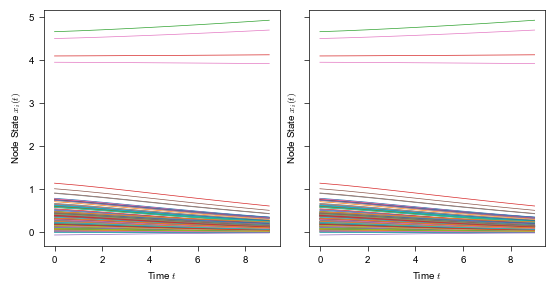

In [85]:
from copy import deepcopy

X0 = deepcopy(X)
X0['x7'] = deepcopy(x_stable.value)
X0['x14'] = deepcopy(x_stable.value)
X0['f'] = X0['f'][-1]

traj = []
X_cur = deepcopy(X0)
for _ in range(10):
    # y = eq.eval(**X_cur)
    # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
    # X_cur['x7'] = y * X['y_max'] / X['x7_max']
    dx = dxdt.eval(**X_cur)
    X_cur['x7'] = X_cur['x7'] + dx
    X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
    traj.append(X_cur['x7'])
X_baseline = traj[-1]

from ND2.utils import get_fig
fi, fig, axes = get_fig(1, 2, AW=6, AH=6, dpi=100, sharey=True)
axes[0].plot(traj)
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('Node State $x_i(t)$')

from tqdm import tqdm
G = []
p = 1e-4
for j in tqdm(range(N)):
    X00 = deepcopy(X0)
    X00['x7'][j] += p
    X00['x14'][j] += p / 2

    traj = []
    X_cur = X00.copy()
    for _ in range(10):
        # y = eq.eval(**X_cur)
        # X_cur['x14'] = (X_cur['x7'] + y * X['y_max'] / X['x7_max']) * X['x7_max'] / X['x14_max']
        # X_cur['x7'] = y * X['y_max'] / X['x7_max']
        dx = dxdt.eval(**X_cur)
        X_cur['x7'] = X_cur['x7'] + dx
        X_cur['x14'] = (X_cur['x7'] * 2 - dx) / 2
        # X_cur['x7'][j] = X00['x7'][j]
        # X_cur['x14'][j] = X00['x14'][j]
        traj.append(X_cur['x7'])
    dxi = (traj[-1] - X_baseline)
    dxj = p
    G.append(dxi / x_stable.value / dxj * x_stable.value[j])

    if j == 0:
        axes[1].plot(traj)
        axes[1].set_xlabel('Time $t$')
        axes[1].set_ylabel('Node State $x_i(t)$')

G_dict[name] = np.stack(G, axis=1)

[-1.58722948 -6.85662806]


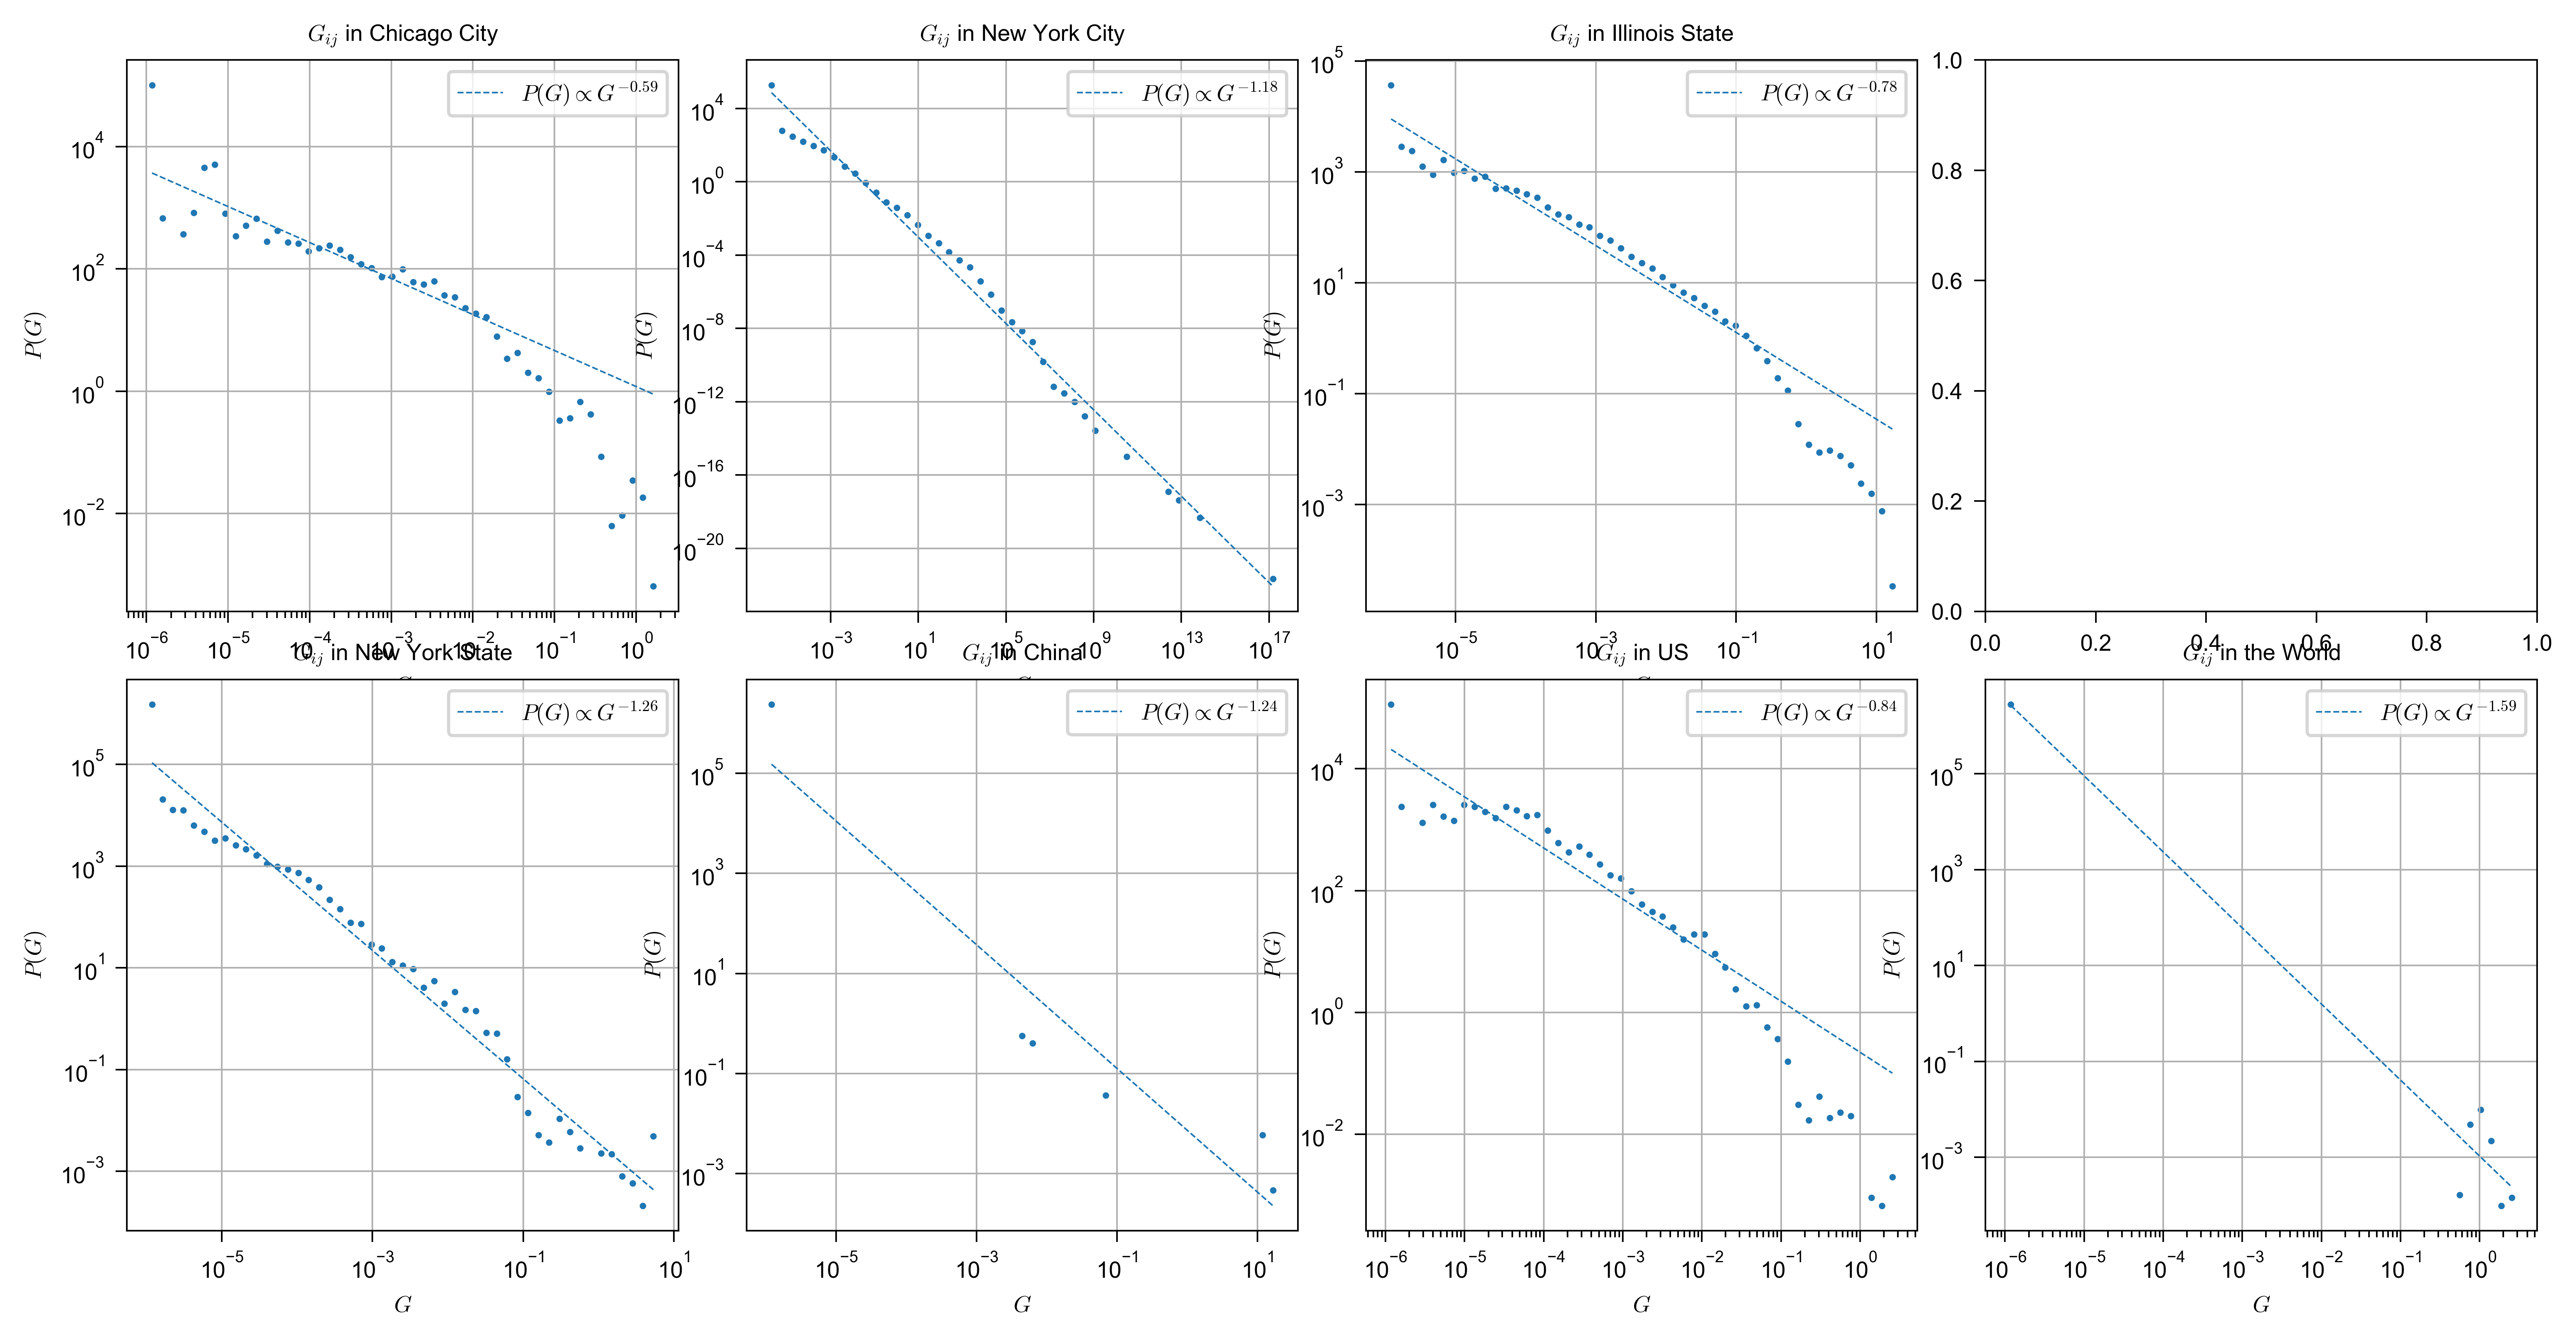

In [86]:
import numpy as np

# 示例数据，假设 x 是一个包含浮点数的 ndarray
# x = np.random.power(0.1, 10000)  # 示例数据，可以替换为你的数据
x = np.abs(G).clip(1e-6, None)
x = x[~np.isnan(x)]
# x = np.random.normal(0, 1, 10000)
# x = np.abs(x) + 1e-6

# 设置直方图的边界
M = 50
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), M)

# 计算直方图
hist, bin_edges = np.histogram(x, bins=bins)
freq = hist / np.diff(bin_edges) / len(x)

# 计算每个 bin 的中心
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# 过滤掉频率为零的 bin
nonzero = freq > 0
bin_centers = bin_centers[nonzero]
freq = freq[nonzero]

# 使用对数坐标绘图
ax = axes_G[7]
ax.clear()
ax.scatter(bin_centers, freq, s=1)

# polyfit
a = np.polyfit(np.log(bin_centers[:50]), np.log(freq[:50]), 1)
print(a)
plot_x = np.logspace(np.log10(np.min(bin_centers)), np.log10(np.max(bin_centers)), 100)
plot_y = np.exp(np.polyval(a, np.log(plot_x)))
ax.plot(plot_x, plot_y, '--', color='C0', label=f'$P(G) \propto G^{{{a[0]:.2f}}}$')


ax.set_title('$G_{ij}$ in the World')
ax.set_xlabel('$G$')
ax.set_ylabel('$P(G)$')
ax.legend()
ax.loglog()
ax.grid()

display(fig_G)

### Resilience 分析

In [11]:
from ND2.env import simplify
eq = simplify(eq * X['y_max'] / X['x7_max'] - x7)
pred = eq.eval(**X)
print('Eq:', eq.to_str(number_format=".3g"))

Failed to simplify (-0.18233775515544492 + 2.0654107974694598 * x7 + -1.0353472986376915 * x14 + 0.6922627296448642 * sigmoid(0.013926747198120506 * Aggr(f)) / (1.89834380267661 + 0.931704416417884 * x14)) * 5641428.0 / 5641428.0 - x7: 'sigmoid'


Eq: (-0.182 + 2.07 * x7 + -1.04 * x14 + 0.692 * sigmoid(0.0139 * Aggr(f)) / (1.9 + 0.932 * x14)) * 5.64e+06 / 5.64e+06 - x7


Text(0.5, 1.0, 'Linear Phi')

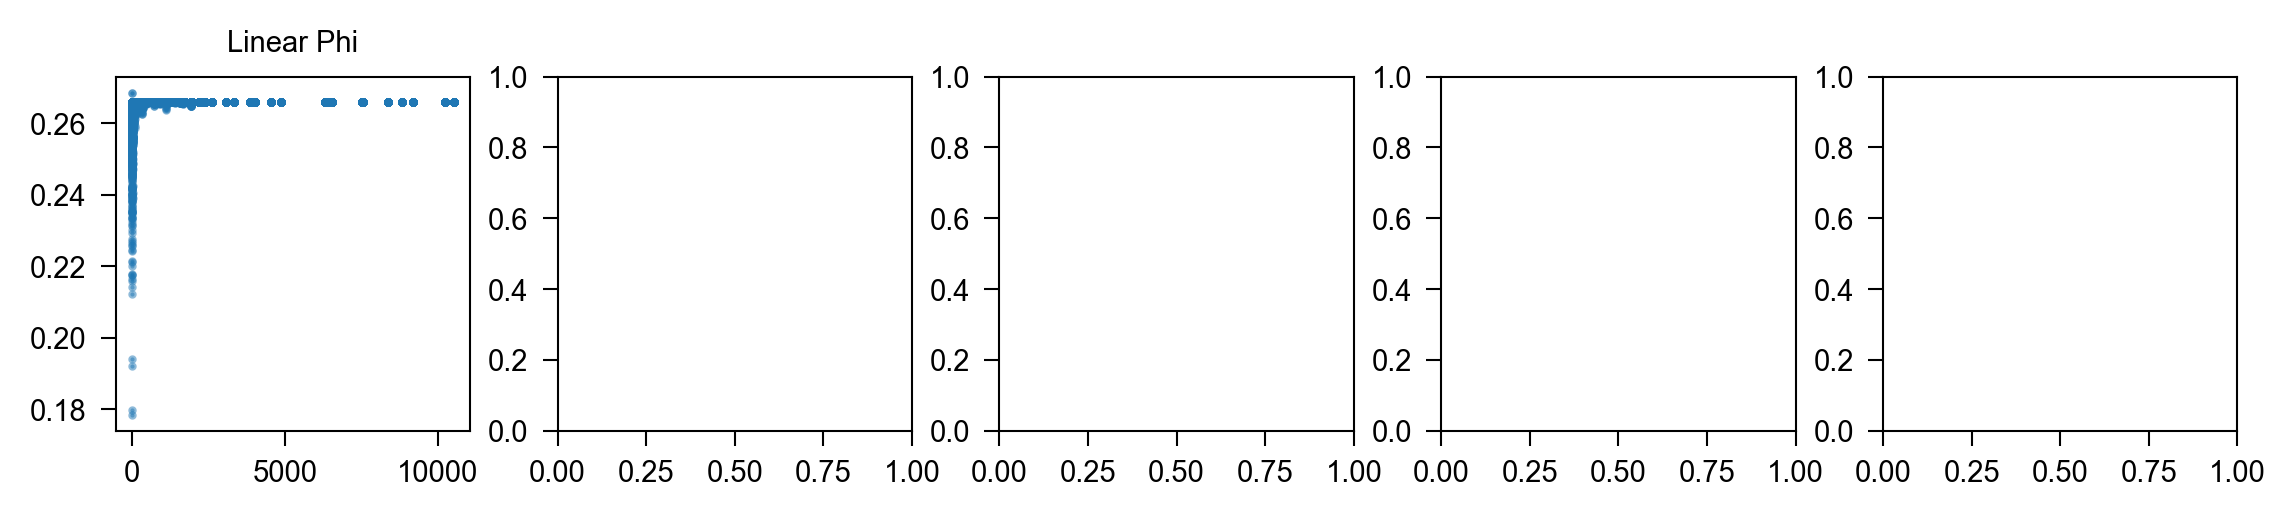

In [17]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

from ND2.utils import get_fig
fi, fig, axes = get_fig(1, 5, AW=3, AH=3)

X, Y, x7, x14, f, data, evaluate = prepare_data(name)

# 要检查的动力学方程
eq = -0.182 + 1.07 * x7 - 1.04 * x14 + 0.742 * Sigmoid(0.0139 * Aggr(f)) / (2.039 + x14)
F = -0.182 + 1.07 * x7 - 1.04 * x14
A = 0.0139 * f
G = 1
Phi = 0.742 * Sigmoid(Aggr(A * G)) / (2.039 + x14)
# eq = F + Phi(Aggr(A * G))

a = (0.742 * Sigmoid(Aggr(A * G)) / (2.039 + x14) / Aggr(A)).eval(**X)
b = (0.742 * Sigmoid(Aggr(A * G) / Aggr(A)) / (2.039 + x14)).eval(**X)
axes[0].scatter(a, b, s=1, alpha=0.5)
axes[0].set_title('Linear Phi')
# axes[0].set_ylim(*axes[0].get_xlim())

# A2 = np.ones_like(X['A'])
# G2 = np.stack(np.nonzero(A2), axis=-1)
# s_out = Number((Rgga(A) / Readout(Rgga(A))).eval(**X), nettype='node')
# a = (Aggr(A*G) / (eps+Aggr(A))).eval(**X) # a_i = sum_j A_ji G(xi, xj) / sum_j A_ji
# b = (Aggr(Sour(s_out) * G) / 0.80041403).eval(**{**X, 'A': A2, 'G': G2})+0*a # Readout(Aggr(A)) = Read(Rgga(A)), Readout(Aggr(A*Sour(x7))) ~ Readout(Rgga(A)*x7)
# axes[0].scatter(a, b, s=1, alpha=0.5)
# axes[0].set_title('Similiar Neighbourhood')
# axes[0].set_ylim(*axes[0].get_xlim())

# x7_eff = Readout(s_out * x7) # x7_eff = sum_j s_out_j xj
# x14_eff = 2 * x7_eff * X['x7_max'] / X['x14_max']
# b = b # b_i = sum_j s_out_j G(xi, xj)
# c = (x7_eff * 1 / 0.80041403).eval(**X) + 0*b # c_i = G(xj=x_eff, xi)  # 需要根据 G 修改！！！
# axes[1].scatter(b, c, s=1, alpha=0.5)
# axes[1].set_title('Linear $G_1$')

# d = -Readout(s_out * F).eval(**X)
# e = (x7_eff**2+0.09*x7_eff).eval(**{**X, 'x7': x7_eff.eval(**X), 'x14': x14_eff.eval(**X)})
# axes[2].scatter(d, e, s=1, alpha=0.5)
# axes[2].set_title('Linear F')
# axes[2].loglog()
# # axes[2].set_xlim(0.00, 0.02)
# # axes[2].set_ylim(0.00, 0.02)

# h = Readout(s_out * Aggr(A) * c).eval(**X)
# k = (Readout(s_out * Aggr(A)) * Readout(s_out * c)).eval(**X)
# axes[3].scatter(h, k, s=1, alpha=0.5)
# axes[3].set_title(r'$\sum w_ia_ib_i\approx\sum w_ia_i\sum w_ib_i$')
# axes[3].set_ylim(*axes[3].get_xlim())

# l = Readout(s_out * c).eval(**X)
# m = (x7_eff * 1 / 0.80041403).eval(**X)  # c_i = G(xj=x_eff, xi)  # 需要根据 G 修改！！！
# axes[4].scatter(l, m, s=1, alpha=0.5)
# axes[4].set_title('Linear $G_2$')

# for ax in axes:
#     ax.plot(ax.get_xlim(), ax.get_xlim(), 'k--')
# # g = 
# # a = Aggr(1) * G
# plt.show()

```python
eq = F + Phi(Aggr(A * G)), 
= F + Aggr(A) * Phi(Aggr(A * G)) / Aggr(A)  
= F + Aggr(A) * Phi(Aggr(A * G) / Aggr(A))
~ F + Aggr(A) * Aggr(Sour(s_out) * G; A2, G2)  (As a~b)
~ F + Aggr(A) * (x7_eff * 1 / 0.80041403)                 (As b~c)

let x7_eff = Readout(s_out * x7), beta_eff = Readout(s_out * Aggr(A)), x14_eff = 2*x7_max/x14_max*x7_eff

d(x7_eff)/dt = Readout(s_out * eq)
= Readout(s_out * F) + Readout(s_out * Aggr(A) * (x7_eff * 1 / 0.80041403))
~ -(x7_eff**2+0.09*x7_eff) + Readout(s_out * Aggr(A) * (x7_eff * 1 / 0.80041403))       (As d~e)
~ -(x7_eff**2+0.09*x7_eff) + beta_eff * Readout(s_out * (x7_eff * 1 / 0.80041403))      (As h~k)
~ -(x7_eff**2+0.09*x7_eff) + beta_eff * (x7_eff * 1 / 0.80041403)                       (As l~m)
```

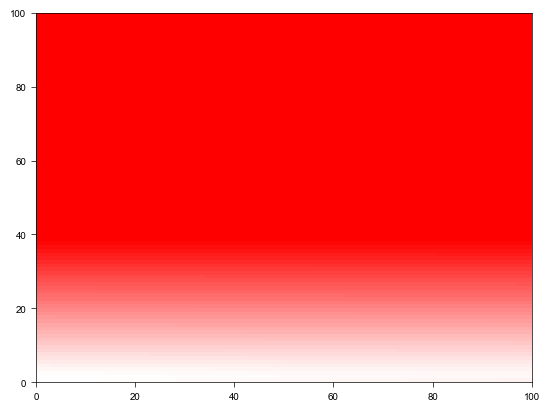

In [314]:
beta_eff = np.linspace(0, 100, 100)
x_eff = np.linspace(0.0, 100.0, 100)
beta_eff, x_eff = np.meshgrid(beta_eff, x_eff)

x7 = x_eff
x14 = 2 * x_eff * X['x7_max'] / X['x14_max']
# eq(x7, x14) -> ymax/xmax * eq(x7, 2*x7) - x7, Sour & Targ -> I, Aggr(x) -> beta_eff*x
dxdt = -0.18 + 2.1*x7 + -1.0*x14 + 0.69*sigmoid(0.012*beta_eff) / (1.9+0.93*x14)
dxdt = dxdt * X['y_max'] / X['x7_max'] - x7

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
cmap = plt.get_cmap('bwr')
plt.imshow(dxdt, origin='lower', aspect='auto', cmap=cmap, norm=Normalize(vmin=-2, vmax=2), extent=(beta_eff.min(), beta_eff.max() , x_eff.min(), x_eff.max()))

# X, Y, x7, x14, f, data, evaluate = prepare_data(name)
# s_in = Aggr(f).eval(**X)
# s_out = Aggr(f).eval(**X)
# beta_eff = (s_out*s_in).sum(axis=-1) / (s_out).sum(axis=-1)
# x_eff = (s_out*x7.eval(**X)).sum(axis=-1) / (s_out).sum(axis=-1)
# plt.scatter(beta_eff + 0*x_eff, x_eff)

# Visualize

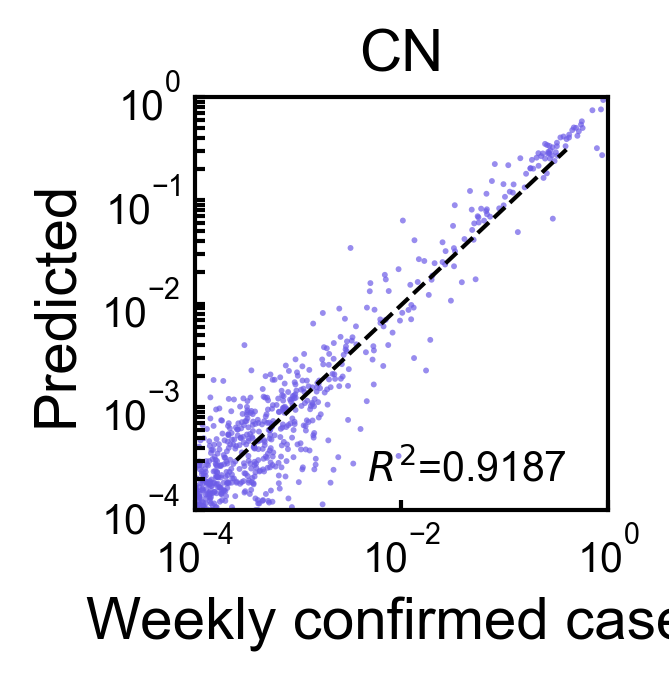

In [99]:
true = Y # * X['y_max'] / X['x7_max'] - X['x7']
pred = eq.eval(**X) # * X['y_max'] / X['x7_max'] - X['x7']
r2 = r2_score(true, pred)
baseline = (x7).eval(**X) # * X['y_max'] / X['x7_max'] - X['x7']
r2_baseline = r2_score(true, baseline)

from ND2.utils import get_fig
fi, fig, axes = get_fig(1, 1, AW=3.5, fontsize=14, lw=1)
axes[0].loglog()
axes[0].set_xlim(1e-4, 1e0)
axes[0].set_ylim(1e-4, 1e0)
mask = ( true > 1e-4 ) & ( pred > 1e-4 ) & ( true < 1e0 ) & ( pred < 1e0 )
axes[0].scatter(true[mask], pred[mask], s=2, alpha=0.7, color='#6c5ce7', edgecolor='none', rasterized=True)
axes[0].tick_params(axis='both', which='both', direction='in', length=2.5, width=fi.lw, labelsize=0.7*fi.fontsize)
axes[0].set_xlabel('Weekly confirmed cases')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{name}', fontsize=fi.fontsize)

# 绘制拟合线
x = np.logspace(-4, 0, 100)[10:-10]
# y = x
k, b = np.polyfit(np.log10(true[mask]), np.log10(pred[mask]), 1)
y = 10**(k*np.log10(x) + b)
axes[0].plot(x, y, color='k', lw=fi.lw, ls='--')
# axes[0].text(0.5, 0.1, rf'$R^2$={r2:.4f} ({r2/r2_baseline-1:.1%}$\!\!\uparrow\!\!$)', fontsize=0.7*fi.fontsize, transform=axes[0].transAxes, ha='center', va='center')
axes[0].text(0.9, 0.1, rf'$R^2$={r2:.4f}', fontsize=0.7*fi.fontsize, transform=axes[0].transAxes, ha='right', va='center')


from ND2.utils import clear_svg
fig.savefig(f'{PLOT_DIR}/test_COVID19in{name}-R2.pdf', transparent=True)
fig.savefig(f'{PLOT_DIR}/test_COVID19in{name}-R2.png', transparent=True, dpi=600)

# from io import BytesIO

# tmp = BytesIO()
# extent = axes[0].get_window_extent().transformed(fig.dpi_scale_trans.inverted())
# fig.savefig('test.png', format="png", bbox_inches=extent)
# tmp


# for coll in axes[0].collections:
#     coll.remove()


fig.savefig(f'{PLOT_DIR}/test_COVID19in{name}-R2.svg', transparent=True)
clear_svg(f'{PLOT_DIR}/test_COVID19in{name}-R2.svg')

/tmp/ipykernel_95048/2685868011.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20')


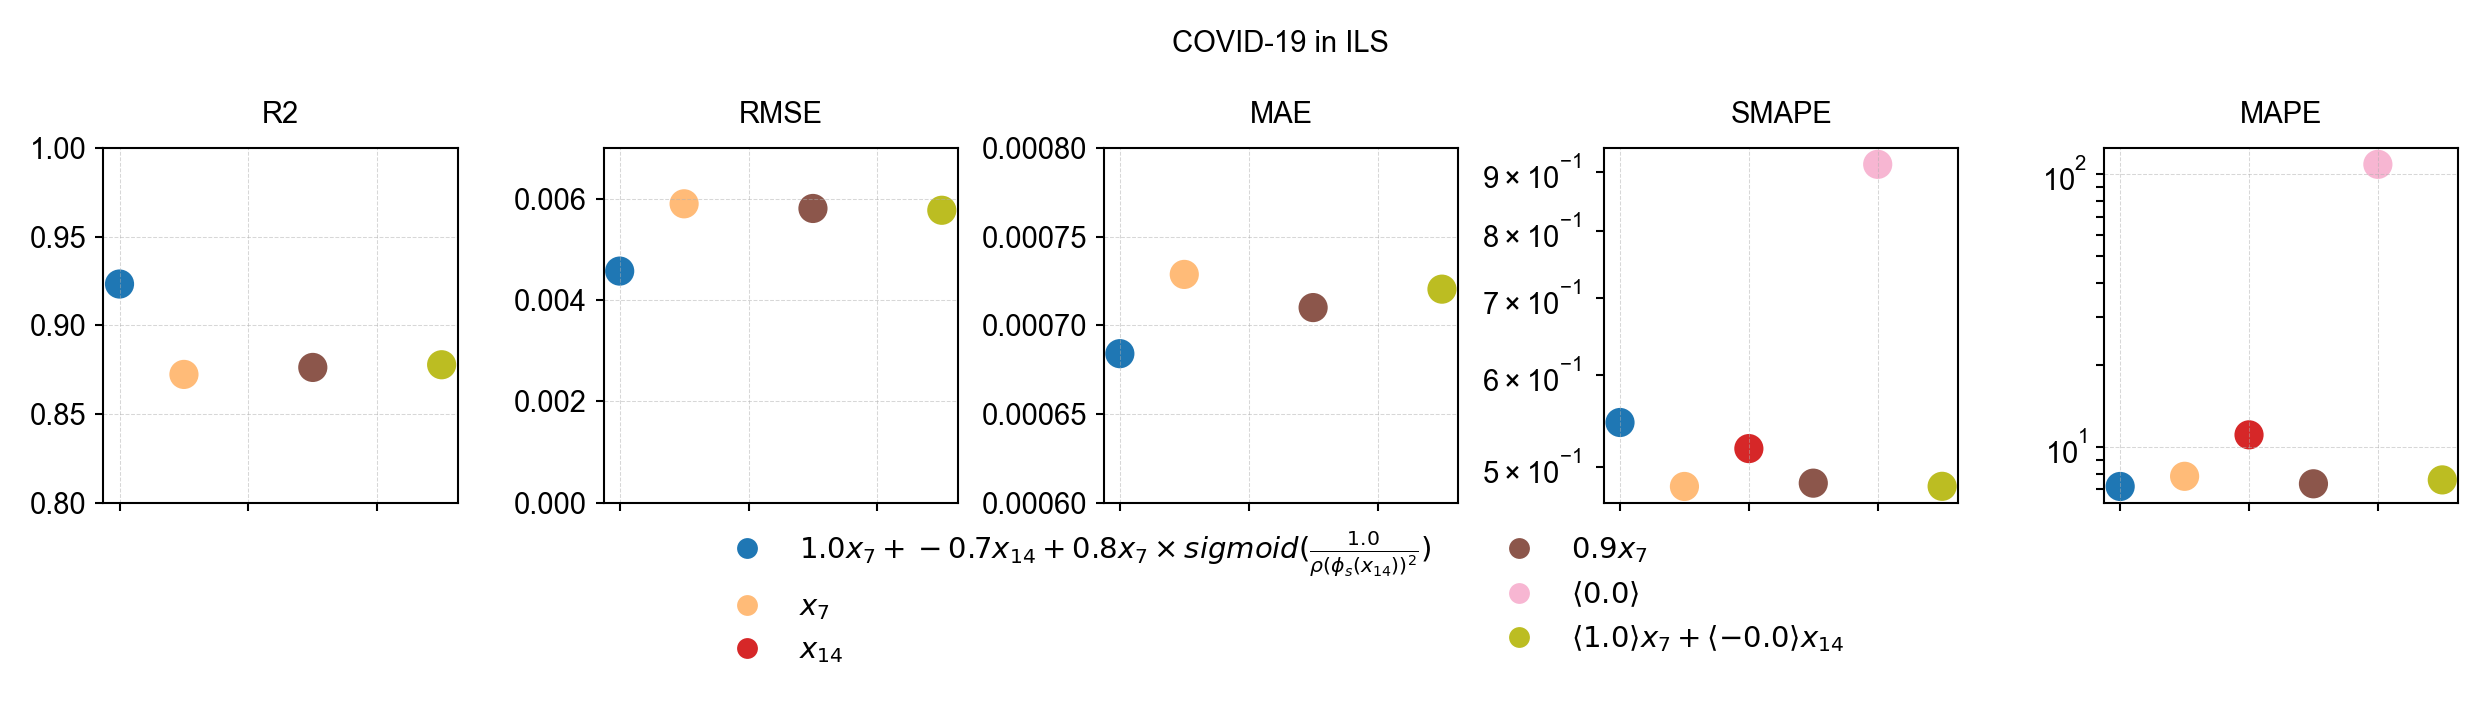

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from ND2.utils.utils import get_fig

cmap = plt.cm.get_cmap('tab20')

df = pd.DataFrame(data).drop_duplicates(subset=['id'], keep='last')

fi, fig, axes = get_fig(1, 5, AW=3.0, AH=3.0, BM=30.0, HS=5.0, TM=5.0)
axes = dict(
    r2=axes[0],
    rmse=axes[1],
    mae=axes[2],
    smape=axes[3],
    mape=axes[4],
)

for idx, (metric, ax) in enumerate(axes.items()):
    ax.clear()
    ax.scatter(np.arange(len(df)), df[metric], color=cmap(np.linspace(0, 1, len(df)+1)[:-1]))
    ax.set_title(metric.upper(), fontsize=fi.fontsize)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels('')

if name == 'CN':
    axes['r2'].set_ylim(0.8, 1.0)
    axes['rmse'].set_ylim(0, 0.03)
    axes['mae'].set_ylim(0, 0.002)
    axes['smape'].set_ylim(0.0, 10.0)
    axes['mape'].set_ylim(0, 100)
elif name == 'ILS':
    axes['r2'].set_ylim(0.8, 1.0)
    axes['rmse'].set_ylim(0.0, 0.007)
    axes['mae'].set_ylim(6e-4, 8e-4)
    axes['smape'].semilogy()
    axes['mape'].semilogy()
else:
    axes['r2'].set_ylim(0.0, 1.0)
    axes['mae'].semilogy()
    axes['smape'].semilogy()
    axes['mape'].semilogy()

fig.legend(
    handles=[plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=cmap(i/len(df))) for i, label in enumerate(df['eq'])],
    labels=('$' + df['eq'] + '$').tolist(),
    loc='upper center', fontsize=fi.fontsize,
    bbox_to_anchor=(fi.r_LM, 0.0, 1-(fi.r_LM+fi.r_RM), fi.r_BM),
    ncol=2, frameon=False
)

for ax in axes.values():
    ax.tick_params(axis='both', which='major', labelsize=fi.fontsize, direction='out', length=2, pad=2)
    ax.grid('on', linestyle='--', linewidth=0.25, alpha=0.5, zorder=0)

fig.suptitle(f'COVID-19 in {name}', fontsize=fi.fontsize)
fig.savefig(f'{PLOT_DIR}/test_COVID19in{name}.png', dpi=600)

In [106]:
bins=50
x = G_dict['CHI']
x = np.abs(x).clip(1e-6, None)
x = x[~np.isnan(x)]
bins_edges = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), bins+1)
hist, bin_edges = np.histogram(x, bins=bins_edges)
freq = hist / np.diff(bin_edges) / len(x)
freq

array([1.02962427e+05, 6.88721316e+02, 0.00000000e+00, 3.86553025e+02,
       8.68786586e+02, 3.25436220e+03, 6.33901838e+03, 7.30619788e+02,
       4.56134541e+02, 4.78413881e+02, 6.65628426e+02, 3.45234185e+02,
       4.88543209e+02, 2.36826077e+02, 1.93553424e+02, 2.17507828e+02,
       2.17268319e+02, 2.84850660e+02, 1.93078676e+02, 1.75102087e+02,
       1.39737300e+02, 1.19642938e+02, 6.88256425e+01, 7.67440243e+01,
       8.26485423e+01, 9.55693190e+01, 5.19338055e+01, 5.66613552e+01,
       5.20710455e+01, 3.51940574e+01, 2.89078248e+01, 2.14190058e+01,
       1.80078120e+01, 1.38249223e+01, 5.85411153e+00, 3.41113807e+00,
       3.65076631e+00, 1.78830827e+00, 1.68651424e+00, 7.20309006e-01,
       3.36167235e-01, 3.91026845e-01, 6.75268119e-01, 3.79420057e-01,
       6.40959702e-02, 4.17556897e-03, 9.38468482e-03, 3.63256096e-02,
       1.84354307e-02, 0.00000000e+00])

error: multiple repeat at position 23

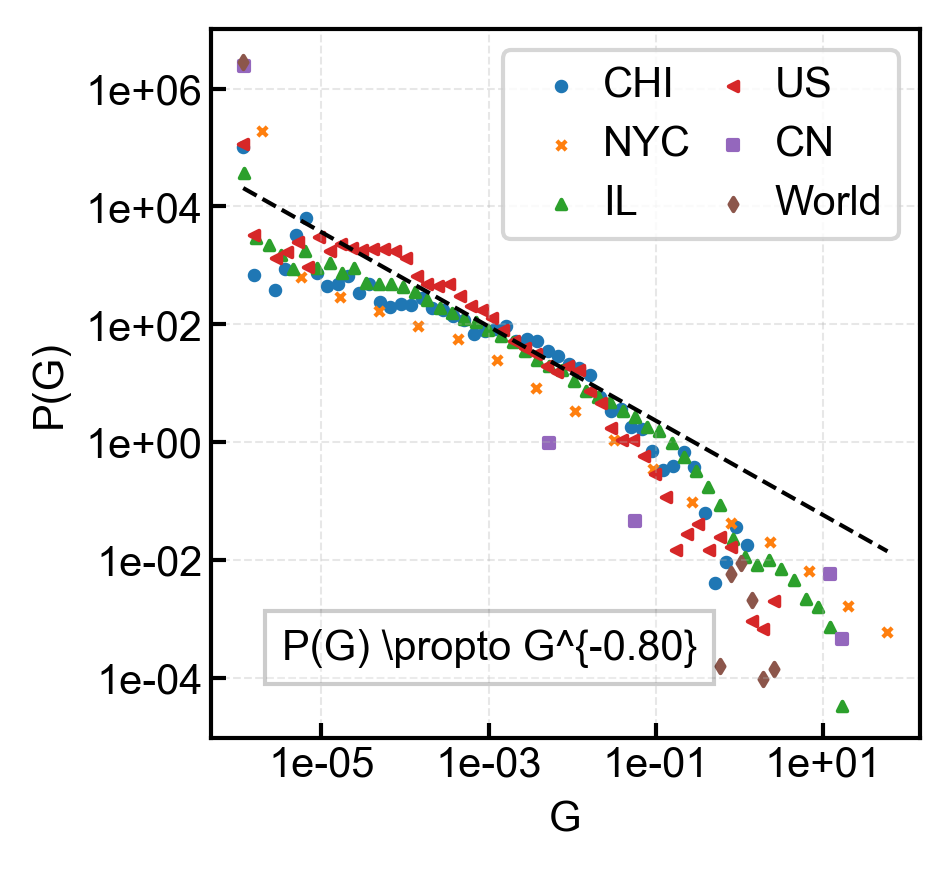

In [164]:
from ND2.utils import get_fig

plt.rcParams['mathtext.fontset'] = 'stix'


fi, fig, axes = get_fig(1, 1, AW=6, AH=6, lw=1, fontsize=10)

ax = axes[0]

def to_dist(x, bins=50):
    x = np.abs(x).clip(1e-6, None)
    x = x[~np.isnan(x)]
    bins_edges = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), bins+1)
    hist, bin_edges = np.histogram(x, bins=bins_edges)
    freq = hist / np.diff(bin_edges) / len(x)
    # 计算每个 bin 的中心
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    # 过滤掉频率为零的 bin
    nonzero = freq > 0
    bin_centers = bin_centers[nonzero]
    freq = freq[nonzero]
    return bin_centers, freq


total = {'x':[], 'y':[]}

bin_centers, freq = to_dist(G_dict['CHI'])
ax.scatter(bin_centers, freq, s=5, label='CHI', marker='o')
total['x'].extend(bin_centers)
total['y'].extend(freq)

bin_centers, freq = to_dist(G_dict['NYC'])
ax.scatter(bin_centers[:17], freq[:17], s=5, label='NYC', marker='x')
total['x'].extend(bin_centers[:17])
total['y'].extend(freq[:17])

bin_centers, freq = to_dist(G_dict['ILS'])
ax.scatter(bin_centers, freq, s=5, label='IL', marker='^')
total['x'].extend(bin_centers)
total['y'].extend(freq)

bin_centers, freq = to_dist(G_dict['US'])
ax.scatter(bin_centers, freq, s=5, label='US', marker='<')
total['x'].extend(bin_centers)
total['y'].extend(freq)

bin_centers, freq = to_dist(G_dict['CN'])
ax.scatter(bin_centers, freq, s=5, label='CN', marker='s')
total['x'].extend(bin_centers)
total['y'].extend(freq)

bin_centers, freq = to_dist(G_dict['World'])
ax.scatter(bin_centers, freq, s=5, label='World', marker='d')
total['x'].extend(bin_centers)
total['y'].extend(freq)

x, y = np.array(total['x']), np.array(total['y'])
a = np.polyfit(np.log10(x), np.log10(y), 1)
a[0] = -0.8
a[1] = -1
plot_x = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 100)
plot_y = np.exp(np.polyval(a, np.log(plot_x)))
ax.plot(plot_x, plot_y, '--', color='k')

ax.set_xlabel('G')
ax.set_ylabel('P(G)')

ax.loglog()
ax.grid('on', alpha=0.3, zorder=0, linestyle='--', lw=0.5*fi.lw)
ax.legend(handletextpad=0, ncols=2, fontsize=fi.fontsize, columnspacing=0)
# text 怎么加box color = white?
ax.text(0.1, 0.1, rf'P(G) \propto G^{{{a[0]:.2f}}}', fontsize=fi.fontsize, ha='left', va='bottom', transform=ax.transAxes, color='k', bbox=dict(facecolor='white', edgecolor='black', alpha=0.2))
ax.tick_params(axis='both', which='major', labelsize=fi.fontsize, direction='in', pad=2)

from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0e}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0e}'))

from ND2.utils import clear_svg
fig.savefig(f'{PLOT_DIR}/test_COVID19inWorld-G.png', dpi=600)
fig.savefig(f'{PLOT_DIR}/test_COVID19inWorld-G.pdf', transparent=True)
fig.savefig(f'{PLOT_DIR}/test_COVID19inWorld-G.svg', transparent=True)
clear_svg(f'{PLOT_DIR}/test_COVID19inWorld-G.svg')

In [160]:
print(style)
re.search(r'font:[^;]*\s+(\d+\.?\d*px)(?:\s|$)', style)

font: 10px 'Arial'; text-anchor: middle


<re.Match object; span=(0, 11), match='font: 10px '>

In [166]:
import re
debug = True

path = f'{PLOT_DIR}/test_COVID19inWorld-G.svg'
"""
matplotlib 生成的 svg 中会使用 <text style="font: 9.8px 'Arial'; text-anchor: middle" x="80.307802" y="193.900483">2020-02-02</text> 的语法，而 Powerpoint 无法识别 font: 9.8px 'Arial'; 的简写记法，只能识别 font-family: 'Arial'; font-size: 9.8px; 的记法。因此需要进行转换。考虑的属性包括：
- font-size
- font-family
- font-weight
- font-style
"""
from lxml import etree
tree = etree.parse(path)
root = tree.getroot()

for text in root.findall('.//{http://www.w3.org/2000/svg}tspan') + root.findall('.//{http://www.w3.org/2000/svg}text'):
    style = text.attrib.pop('style', '')

    font_size = re.search(r'font:[^;]*\s+(\d+\.?\d*px)(?:\s|$)', style)
    font_family = re.search(r'font:[^;]*\s+\'([^\']*)\'(?:\s|$)', style)
    font_style = re.search(r'font:[^;]*\s+(italic|oblique)(?:\s|$)', style)
    font_weight = re.search(r'font:[^;]*\s+(bold|normal|bolder|lighter)(?:\s|$)', style)
    line_height = re.search(r'line-height:\s+([\d\.]+(px|em|%)?)', style)
    font_variant = re.search(r'font-variant:\s+([\w-]+)', style)
    text_anchor = re.search(r'text-anchor:\s+([\w-]+)', style)

    if font_size: text.set('font-size', font_size.group(1))
    if font_family: text.set('font-family', font_family.group(1))
    if font_style: text.set('font-style', font_style.group(1))
    if font_weight: text.set('font-weight', font_weight.group(1))
    if line_height: text.set('line-height', line_height.group(1))
    if font_variant: text.set('font-variant', font_variant.group(1))
    if text_anchor: text.set('text-anchor', text_anchor.group(1))

    if debug: print(f'"{style}" -> "{text.attrib}"')
tree.write(path)

"" -> "{'x': '56.462653', 'y': '209.236553', 'transform': 'rotate(-0 56.462653 209.236553)', 'font-size': '10px', 'text-anchor': 'middle'}"
"" -> "{'x': '96.62605', 'y': '209.236553', 'transform': 'rotate(-0 96.62605 209.236553)', 'font-size': '10px', 'text-anchor': 'middle'}"
"" -> "{'x': '136.789446', 'y': '209.236553', 'transform': 'rotate(-0 136.789446 209.236553)', 'font-size': '10px', 'text-anchor': 'middle'}"
"" -> "{'x': '176.952843', 'y': '209.236553', 'transform': 'rotate(-0 176.952843 209.236553)', 'font-size': '10px', 'text-anchor': 'middle'}"
"" -> "{'x': '115.03937', 'y': '222.381865', 'transform': 'rotate(-0 115.03937 222.381865)', 'font-size': '10px', 'text-anchor': 'middle'}"
"" -> "{'x': '28', 'y': '189.309832', 'transform': 'rotate(-0 28 189.309832)', 'font-size': '10px', 'text-anchor': 'end'}"
"" -> "{'x': '28', 'y': '161.004204', 'transform': 'rotate(-0 28 161.004204)', 'font-size': '10px', 'text-anchor': 'end'}"
"" -> "{'x': '28', 'y': '132.698577', 'transform': '

[CN] R2=0.9187, RMSE=0.0124, MAE=0.0010, SMAPE=64.39%, MAPE=5194.0% 	 1.31 * x7 - 1.00 * x14 * x7 - 2.28 * x7 ** 3 + 3.07 * Aggr(f * Targ(x7 ** 3))
[US] R2=0.8595, RMSE=0.0132, MAE=0.0037, SMAPE=29.19%, MAPE=13945.6% 	 0.62 * x7 * (1.90 + x7) / (0.81 + 0.65 * x14) - 0.49 * x14 + 0.04 * Aggr(f * Sour(x7))


/tmp/ipykernel_116620/3112268314.py:121: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(['', 'CN', '', 'US'])
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


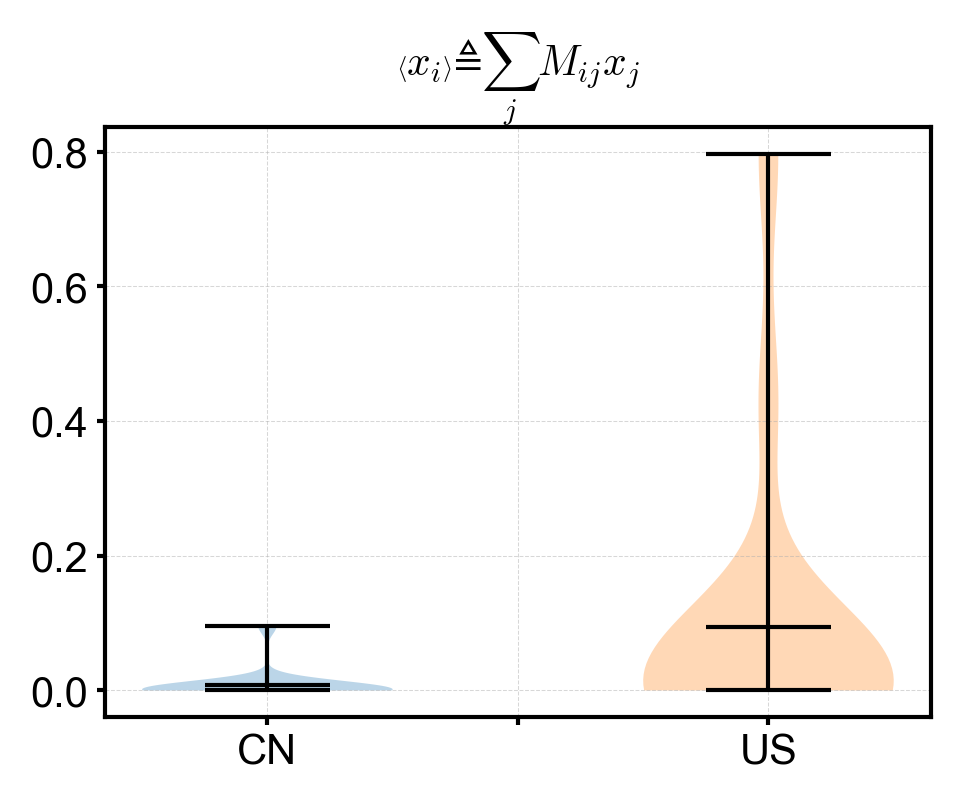

In [36]:
from ND2.utils import get_fig
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
# sns.set_theme(style="light")

# 修改公式字体为 cm
plt.rcParams['mathtext.fontset'] = 'cm'

def corr(x, y):
    # r, p = stats.pearsonr(x, y)
    # return dict(r=r, p=p)
    # r = np.corrcoef(x, y)[0, 1] ** 2
    r = np.corrcoef(x, y)[0, 1] ** 2
    if x.shape[0] == 1: r = 0.0
    if (y == 0.0).all(): r = 0.0
    assert not np.isnan(r), r
    return dict(r=r)

B = 15
# abc_dict = {}
# fi, fig, axes = get_fig(1, 3, AW=6, AH=6, lw=1, fontsize=10)


name = 'CN'
X, Y, x7, x14, f, data, evaluate = prepare_data(name)
eq = 1.31 * x7 - 1 * x14 * x7 - 2.28 * Pow3(x7) + 3.07 * Aggr(f * Targ(Pow3(x7)))
evaluate(eq, 10000)

dxdt = eq * Number(X['y_max'] / X['x7_max'], fitable=False) - x7
a = X['x7'].reshape(-1)
b1 = Aggr(Sour(x7)).eval(**X).reshape(-1)
b2 = Aggr(f * Sour(x7)).eval(**X).reshape(-1)
b3 = (Readout(x7) - x7).eval(**X).reshape(-1)
c = (Y - X['x7']).reshape(-1)

df = []
for idx in np.array_split(np.argsort(a), B):
    df.append(dict(a=a[idx].mean(), name='CN', type='b1', **corr(b1[idx], c[idx])))
    df.append(dict(a=a[idx].mean(), name='CN', type='b2', **corr(b2[idx], c[idx])))
    # df.append(dict(a=a[idx].mean(), name='CN', type='b3', **corr(b3[idx], c[idx])))

# ax = axes[0]
# x, y = np.log10(np.abs(b)+1e-6), np.log10(np.abs(c)+1e-6)
# # x = np.argsort(np.argsort(x))
# # y = np.argsort(np.argsort(y))
# # x, y = b, c
# sns.scatterplot(x=x, y=y, s=5, color=".15", ax=ax)
# sns.histplot(x=x, y=y, bins=50, pthresh=.1, cmap="mako", ax=ax)
# sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1, ax=ax)

# pearson_corr, pearson_p = stats.pearsonr(x, y)
# print(f'Pearson Correlation: {pearson_corr:.7f}, p-value: {pearson_p}')


name = 'US'
X, Y, x7, x14, f, data, evaluate = prepare_data(name)
eq = 0.62*x7*(1.9 + x7)/(0.81 + 0.65*x14) - 0.49*x14 + 0.035*Aggr(f*Sour(x7))
evaluate(eq, 10000)
# name = 'World'
# X, Y, x7, x14, f, data, evaluate = prepare_data(name)
# eq = -0.18 + 2.1*x7 + -1.0*x14 + 0.69*Sigmoid(0.012*Aggr(f)) / (1.9+0.93*x14)
# evaluate(eq, 10000)

dxdt = eq * Number(X['y_max'] / X['x7_max'], fitable=False) - x7
a = X['x7'].reshape(-1)
b1 = Aggr(Sour(x7)).eval(**X).reshape(-1)
b2 = Aggr(f * Sour(x7)).eval(**X).reshape(-1)
b3 = (Readout(x7) - x7).eval(**X).reshape(-1)
c = (Y - X['x7']).reshape(-1)

for idx in np.array_split(np.argsort(a), B):
    df.append(dict(a=a[idx].mean(), name='US', type='b1', **corr(b1[idx], c[idx])))
    df.append(dict(a=a[idx].mean(), name='US', type='b2', **corr(b2[idx], c[idx])))
    # df.append(dict(a=a[idx].mean(), name=name, type='b3', **corr(b3[idx], c[idx])))


# ax = axes[1]
# x, y = np.log10(np.abs(b)+1e-6), np.log10(np.abs(c)+1e-6)
# # x = np.argsort(np.argsort(x))
# # y = np.argsort(np.argsort(y))
# # x, y = b, c
# sns.scatterplot(x=x, y=y, s=5, color=".15", ax=ax)
# sns.histplot(x=x, y=y, bins=50, pthresh=.1, cmap="mako", ax=ax)
# sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1, ax=ax)

# pearson_corr, pearson_p = stats.pearsonr(x, y)
# print(f'Pearson Correlation: {pearson_corr:.7f}, p-value: {pearson_p}')

import pandas as pd
df = pd.DataFrame(df)
fi, fig, axes = get_fig(1, 1, AW=7, AH=5, sharey=True, HS=0.5, lw=1, fontsize=10)
# sns.boxplot(df, x='type', y='r', hue='name', ax=axes[0], showfliers=False, linecolor='black', linewidth=1)

# b1 = df[df['type'] == 'b1']
# # bplot = axes[0].boxplot([b1[b1['name'] == 'CN']['r'], b1[b1['name'] == 'US']['r']], showfliers=True, widths=0.5, patch_artist=True, medianprops=dict(color='black'), whis=1000)
# # bplot['boxes'][0].set_facecolor('C0')
# # bplot['boxes'][1].set_facecolor('C1')
# vplot = axes[0].violinplot([b1[b1['name'] == 'CN']['r'], b1[b1['name'] == 'US']['r']], showmeans=True, showmedians=False, showextrema=True, widths=0.5, bw_method=0.5)
# vplot['bodies'][0].set_facecolor('C0')
# vplot['bodies'][1].set_facecolor('C1')
# for partname in ('cbars', 'cmins', 'cmaxes', 'cmeans'):
#     vplot[partname].set_edgecolor("black")
#     vplot[partname].set_linewidth(1)
# axes[0].set_xticklabels(['', 'CN', '', 'US'])
# axes[0].grid('on', linestyle='--', linewidth=0.25, alpha=0.5, zorder=0)
# axes[0].tick_params(axis='both', which='major', labelsize=fi.fontsize, direction='out', length=2, pad=2)
# axes[0].set_title(r'$\left<x_i\right> \triangleq \sum_j A_{ij}x_j$')
# axes[0].set_ylabel(r'$R^2(\left<x_i\right>, \frac{\mathrm{d}}{\mathrm{d}t}x_i | x_i)$')

b2 = df[df['type'] == 'b2']
# bplot = axes[1].boxplot([b2[b2['name'] == 'CN']['r'], b2[b2['name'] == 'US']['r']], showfliers=True, widths=0.5, patch_artist=True, medianprops=dict(color='black'), whis=1000)
# bplot['boxes'][0].set_facecolor('C0')
# bplot['boxes'][1].set_facecolor('C1')
vplot = axes[0].violinplot([b2[b2['name'] == 'CN']['r'], b2[b2['name'] == 'US']['r']], showmeans=True, showmedians=False, showextrema=True, widths=0.5, bw_method=0.5)
vplot['bodies'][0].set_facecolor('C0')
vplot['bodies'][1].set_facecolor('C1')
for partname in ('cbars', 'cmins', 'cmaxes', 'cmeans'):
    vplot[partname].set_edgecolor("black")
    vplot[partname].set_linewidth(1)
axes[0].set_xticklabels(['', 'CN', '', 'US'])
axes[0].grid('on', linestyle='--', linewidth=0.25, alpha=0.5, zorder=0)
axes[0].tick_params(axis='both', which='major', labelsize=fi.fontsize, direction='out', length=2, pad=2)
axes[0].set_title(r'$\left<x_i\right> \triangleq \sum_j M_{ij}x_j$')
axes[0].set_ylabel('')

# fi, fig, axes = get_fig(1, 2, FW=8, FH=5)

# axes[0].boxplot(df[df['type']=='b1$'].groupby('name')['r'].apply(list), positions=[0, 1], widths=0.5, patch_artist=True, medianprops=dict(color='black', linewidth=1), boxprops=dict(facecolor='C0', edgecolor='black', linewidth=1), whiskerprops=dict(color='black', linewidth=1), capprops=dict(color='black', linewidth=1), whis=10)

# for ax in axes:
#     ax.loglog()

# fi, fig, axes = get_fig(1, 1, AW=6, AH=6, lw=1, fontsize=10)
# axes[0].boxplot([result_CN[:, 1], result_US[:, 1]], positions=[0, 1], widths=0.5, patch_artist=True, medianprops=dict(color='black', linewidth=1), boxprops=dict(facecolor='C0', edgecolor='black', linewidth=1), whiskerprops=dict(color='black', linewidth=1), capprops=dict(color='black', linewidth=1), whis=10)

from ND2.utils import clear_svg
fig.savefig(f'{PLOT_DIR}/Relationship_in_CN_and_US.png', dpi=600)
fig.savefig(f'{PLOT_DIR}/Relationship_in_CN_and_US.pdf')
fig.savefig(f'{PLOT_DIR}/Relationship_in_CN_and_US.svg')
# clear_svg(f'{PLOT_DIR}/Relationship_in_CN_and_US.svg')

In [57]:
pd.set_option('display.max_rows', None)
df.groupby(['name', 'type'])['p'].mean()

name  type
CN    b1      0.582933
      b2      0.604031
      b3      0.225372
US    b1      0.231251
      b2      0.181254
      b3      0.284409
Name: p, dtype: float64

<Axes: >

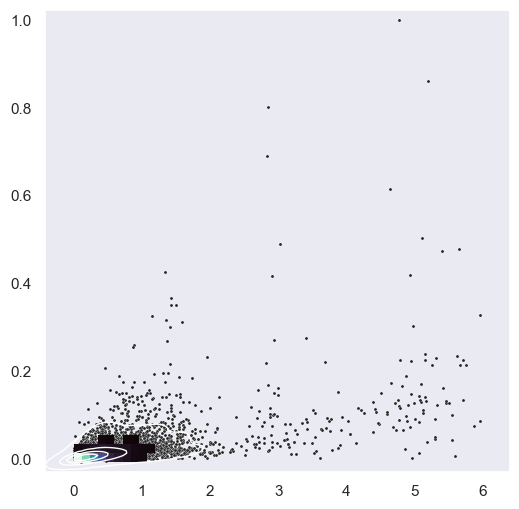

In [314]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

# Simulate data from a bivariate Gaussian
n = 10000
mean = [0, 0]
cov = [(2, .4), (.4, .2)]
rng = np.random.RandomState(0)
# x, y = rng.multivariate_normal(mean, cov, n).T
x, y = np.loglb, c

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=50, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)

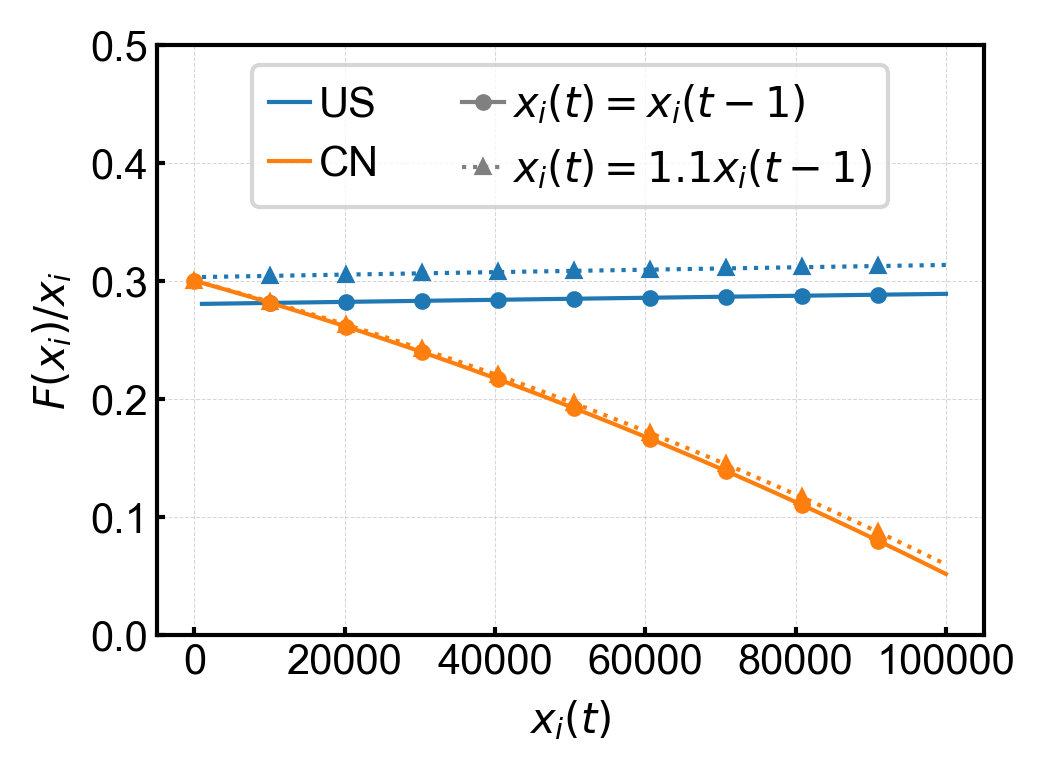

In [35]:
import matplotlib.pyplot as plt
from ND2.utils import get_fig, clear_svg

name = 'US'
X, Y, x7, x14, f, data, evaluate = prepare_data(name)

fi, fig, axes = get_fig(1, 1, AW=7, AH=5, lw=1, fontsize=10, HS=5)

tmp = (0.96 * x7 + 1.8 * X['x7_max']) / (0.5 * x14 + 1.24 * X['x14_max']) - 0.25 * x14 / x7
x = np.linspace(0, 100000, 100)

ax = axes[0]
alpha = 1.0
ax.plot(x, tmp.eval(**{**X, 'x7': x, 'x14': x*(1+1/alpha)}), '-o', label=rf'$x_i(t) = x_i(t-1)$', color='C0', markersize=3, markevery=10, zorder=10000)
alpha = 1.1
ax.plot(x, tmp.eval(**{**X, 'x7': x, 'x14': x*(1+1/alpha)}), ':^', label=rf'$x_i(t) = {alpha:.1f}x_i(t-1)$', color='C0', markersize=3, markevery=10)
# alpha = 1.2
# ax.plot(x, tmp.eval(**{**X, 'x7': x, 'x14': x*(1+1/alpha)}), label=rf'$x_i(t) = {alpha:.1f}x_i(t-1)$')
ax.set_xlabel('$x_i(t)$')
ax.set_ylabel('$R_i^{(US)}(t)$')
ax.tick_params(axis='both', which='major', labelsize=fi.fontsize, direction='in', length=2, pad=2)
ax.set_ylim(0.0, 0.5)


name = 'CN'
X, Y, x7, x14, f, data, evaluate = prepare_data(name)
tmp = 0.3 - 1.0 * x14 / X['x14_max'] - 2.3 * (x7 / X['x7_max']) ** 2
x = np.linspace(0, 100000, 100)

ax = axes[0]
alpha = 1.0
ax.plot(x, tmp.eval(**{**X, 'x7': x, 'x14': x*(1+1/alpha)}), '-o', label=rf'$x_i(t) = x_i(t-1)$', color='C1', markersize=3, markevery=10, zorder=10000)
alpha = 1.1
ax.plot(x, tmp.eval(**{**X, 'x7': x, 'x14': x*(1+1/alpha)}), ':^', label=rf'$x_i(t) = {alpha:.1f}x_i(t-1)$', color='C1', markersize=3, markevery=10)
# alpha = 1.2
# ax.plot(x, tmp.eval(**{**X, 'x7': x, 'x14': x*(1+1/alpha)}), label=rf'$x_i(t) = {alpha:.1f}x_i(t-1)$')
ax.tick_params(axis='both', which='major', labelsize=fi.fontsize, direction='in', length=2, pad=2)
ax.set_xlabel('$x_i(t)$')
ax.set_ylabel('$F(x_i)/x_i$')
# ax.set_ylim(0.0, 0.4)
ax.grid('on', linestyle='--', linewidth=0.25, alpha=0.5, zorder=0)

ax.legend(
    [
        plt.plot([], [], '-', color='C0', markersize=3)[0],
        plt.plot([], [], '-', color='C1', markersize=3)[0],
        plt.plot([], [], '-o', color='gray', markersize=3)[0],
        plt.plot([], [], ':^', color='gray', markersize=3)[0],
    ],
    [
        rf'US',
        rf'CN',
        rf'$x_i(t) = x_i(t-1)$',
        rf'$x_i(t) = 1.1x_i(t-1)$',
    ],
    handlelength=1, handletextpad=0.2, fontsize=fi.fontsize,
    loc='upper center', ncol=2
)

fig.savefig(f'{PLOT_DIR}/R_i_in_US_and_CN.png', dpi=600)
fig.savefig(f'{PLOT_DIR}/R_i_in_US_and_CN.pdf', transparent=True)
fig.savefig(f'{PLOT_DIR}/R_i_in_US_and_CN.svg', transparent=True)
clear_svg(f'{PLOT_DIR}/R_i_in_US_and_CN.svg')

Text(0, 0.5, '$R_i^{(CN)}(t)$')

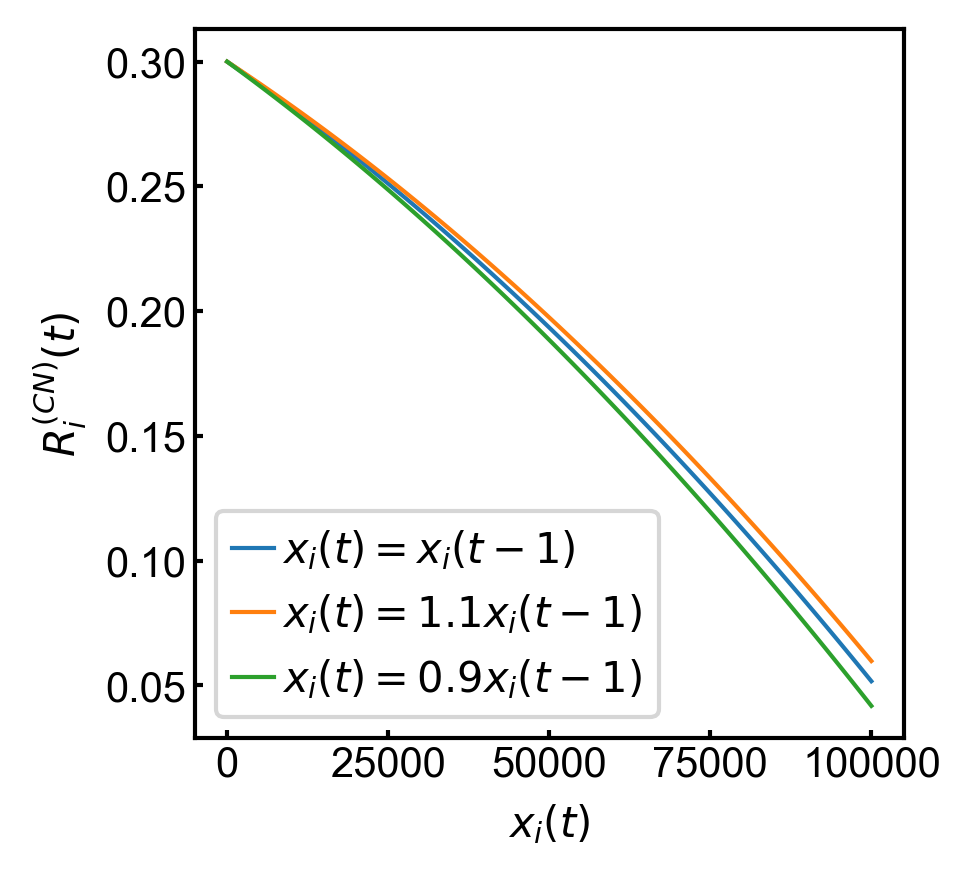

In [62]:
for name in ['NYC', 'CHI', 'NYS', 'ILS', 'US', 'CN', 'World']:
    X, Y, x7, x14, f, data, evaluate = prepare_data(name)
    print(name, X['A'].shape[0]) # , X['G'].shape[0] / X['A'].shape[0])


NYC 177
CHI 57
NYS 62
ILS 102
US 51
CN 34
World 190
